# Predicting ICU Stay Length for Acute Traumatic Cervical Spinal Cord Injuries

In [2]:
# =============================================================================
# Step 0: Import Libraries and Setup
# =============================================================================
import math
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import matplotlib.ticker as mticker
import seaborn as sns         
import dask.dataframe as dd
from datetime import timedelta
import os
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import Lasso, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 1000)

# Define the directory where your CSV files are located
data_dir = 'Data/'

# This step loads the required data tables from the MIMIC-IV dataset stored in CSV format. We differentiate between smaller tables (loaded directly with `pandas`) and very large tables (`labevents`, `chartevents`) which will be processed using `dask` later to manage memory usage.

In [4]:
# =============================================================================
# Step 1: Load Datasets
# =============================================================================
# These datasets are relatively small/medium, load with Pandas

patients = pd.read_csv(os.path.join(data_dir, 'patients.csv'))
print(f"Loaded patients.csv ({patients.shape})")
admissions = pd.read_csv(os.path.join(data_dir, 'admissions.csv'))
print(f"Loaded admissions.csv ({admissions.shape})")
diagnoses_icd = pd.read_csv(os.path.join(data_dir, 'diagnoses_icd.csv.gz'), compression='gzip')
print(f"Loaded diagnoses_icd.csv.gz ({diagnoses_icd.shape})")
icustays = pd.read_csv(os.path.join(data_dir, 'icustays.csv'))
print(f"Loaded icustays.csv ({icustays.shape})")
d_items = pd.read_csv(os.path.join(data_dir, 'd_items.csv'))
print(f"Loaded d_items.csv ({d_items.shape})")
inputevents = pd.read_csv(os.path.join(data_dir, 'inputevents.csv'))
print(f"Loaded inputevents.csv ({inputevents.shape})")
outputevents = pd.read_csv(os.path.join(data_dir, 'outputevents.csv'))
print(f"Loaded outputevents.csv ({outputevents.shape})")
procedureevents = pd.read_csv(os.path.join(data_dir, 'procedureevents.csv'))
print(f"Loaded procedureevents.csv ({procedureevents.shape})")
      

# Note: Large files (labevents.csv and chartevents.csv) will be handled with Dask later
labevents_file = os.path.join(data_dir, 'labevents.csv')
chartevents_file = os.path.join(data_dir, 'chartevents.csv')

Loaded patients.csv ((299712, 6))
Loaded admissions.csv ((431231, 16))
Loaded diagnoses_icd.csv.gz ((4756326, 5))
Loaded icustays.csv ((73181, 8))
Loaded d_items.csv ((4014, 9))
Loaded inputevents.csv ((8978893, 26))
Loaded outputevents.csv ((4234967, 9))
Loaded procedureevents.csv ((696092, 22))


# Before proceeding with cleaning and merging, we perform a basic exploration of the loaded DataFrames to understand their structure, content, and potential data quality issues.

In [6]:
# =============================================================================
# Step 2: Initial Exploration of Smaller Datasets
# =============================================================================

# Display the first few rows to understand the structure
print("Patients:\n", patients.head(2))
print("\nAdmissions:\n", admissions.head(2))
print("\nDiagnoses ICD:\n", diagnoses_icd.head(2))
print("\nICU Stays:\n", icustays.head(2))
print("\nD Items:\n", d_items.head(2))
print("\nInput Events:\n", inputevents.head(2))
print("\nOutput Events:\n", outputevents.head(2))
print("\nProcedure Events:\n", procedureevents.head(2))

# Summarize numerical columns
print("\nPatients Summary:\n", patients.describe())
print("\nAdmissions Summary:\n", admissions.describe())
print("\nDiagnoses ICD Summary:\n", diagnoses_icd.describe())
print("\nICU Stays Summary:\n", icustays.describe())
print("\nD Items Summary:\n", d_items.describe())
print("\nInput Events Summary:\n", inputevents.describe())
print("\nOutput Events Summary:\n", outputevents.describe())
print("\nProcedure Events Summary:\n", procedureevents.describe())

# Check for duplicates
print("Patients:", patients.duplicated().sum())
print("Admissions:", admissions.duplicated().sum())
print("Diagnoses ICD:", diagnoses_icd.duplicated().sum())
print("ICU Stays:", icustays.duplicated().sum())
print("D Items:", d_items.duplicated().sum())
print("Input Events:", inputevents.duplicated().sum())
print("Output Events:", outputevents.duplicated().sum())
print("Procedure Events:", procedureevents.duplicated().sum())

# Check for missing values
print("Patients:\n", patients.isnull().sum().sort_values(ascending=False).head())
print("\nAdmissions:\n", admissions.isnull().sum().sort_values(ascending=False).head())
print("\nDiagnoses ICD:\n", diagnoses_icd.isnull().sum().sort_values(ascending=False).head())
print("\nICU Stays:\n", icustays.isnull().sum().sort_values(ascending=False).head())
print("\nD Items:\n", d_items.isnull().sum().sort_values(ascending=False).head())
print("\nInput Events:\n", inputevents.isnull().sum().sort_values(ascending=False).head())
print("\nOutput Events:\n", outputevents.isnull().sum().sort_values(ascending=False).head())
print("\nProcedure Events:\n", procedureevents.isnull().sum().sort_values(ascending=False).head())

Patients:
    subject_id gender  anchor_age  anchor_year anchor_year_group         dod
0    10000032      F          52         2180       2014 - 2016  2180-09-09
1    10000048      F          23         2126       2008 - 2010         NaN

Admissions:
    subject_id   hadm_id            admittime            dischtime deathtime admission_type admit_provider_id      admission_location discharge_location insurance language marital_status   race            edregtime            edouttime  hospital_expire_flag
0    10000032  22595853  2180-05-06 22:23:00  2180-05-07 17:15:00       NaN         URGENT            P874LG  TRANSFER FROM HOSPITAL               HOME     Other  ENGLISH        WIDOWED  WHITE  2180-05-06 19:17:00  2180-05-06 23:30:00                     0
1    10000032  22841357  2180-06-26 18:27:00  2180-06-27 18:49:00       NaN       EW EMER.            P09Q6Y          EMERGENCY ROOM               HOME  Medicaid  ENGLISH        WIDOWED  WHITE  2180-06-26 15:54:00  2180-06-26 21:31:0

# Timestamp columns in MIMIC are often stored as strings. To perform time-based calculations (like Length of Stay) and filtering accurately, these columns need to be converted to proper datetime objects.

In [8]:
# =============================================================================
# Step 3: Convert Date/Time Columns to Datetime Format
# =============================================================================
# Use errors='coerce' to handle invalid date formats (turns them into NaT)

# Patients: Convert date of death
patients['dod'] = pd.to_datetime(patients['dod'], errors='coerce')

# Admissions: Convert key time columns
admissions['admittime'] = pd.to_datetime(admissions['admittime'], errors='coerce')
admissions['dischtime'] = pd.to_datetime(admissions['dischtime'], errors='coerce')
admissions['deathtime'] = pd.to_datetime(admissions['deathtime'], errors='coerce')
admissions['edregtime'] = pd.to_datetime(admissions['edregtime'], errors='coerce')
admissions['edouttime'] = pd.to_datetime(admissions['edouttime'], errors='coerce')

# ICU stays: Convert ICU entry and exit times
icustays['intime'] = pd.to_datetime(icustays['intime'], errors='coerce')
icustays['outtime'] = pd.to_datetime(icustays['outtime'], errors='coerce')

# Convert times in event tables
inputevents['starttime'] = pd.to_datetime(inputevents['starttime'], errors='coerce')
inputevents['endtime'] = pd.to_datetime(inputevents['endtime'], errors='coerce')
inputevents['storetime'] = pd.to_datetime(inputevents['storetime'], errors='coerce')
outputevents['charttime'] = pd.to_datetime(outputevents['charttime'], errors='coerce')
outputevents['storetime'] = pd.to_datetime(outputevents['storetime'], errors='coerce')
procedureevents['starttime'] = pd.to_datetime(procedureevents['starttime'], errors='coerce')
procedureevents['endtime'] = pd.to_datetime(procedureevents['endtime'], errors='coerce')
procedureevents['storetime'] = pd.to_datetime(procedureevents['storetime'], errors='coerce')

# This step focuses on cleaning each loaded DataFrame individually before merging them. Cleaning involves selecting relevant columns, handling missing values appropriately, ensuring correct data types, and validating key information like Length of Stay (LOS).

In [10]:
# =============================================================================
# Step 4: Clean Individual DataFrames
# =============================================================================

# ----- Patients -----
patients = patients[['subject_id', 'gender', 'anchor_age', 'dod']].copy()

# ----- Admissions -----
# Fill missing text/categorical data with 'Unknown' or appropriate placeholder
admissions['discharge_location'] = admissions['discharge_location'].fillna("Unknown")
admissions['marital_status'] = admissions['marital_status'].fillna("Unknown")
admissions['admit_provider_id'] = admissions['admit_provider_id'].fillna("Unknown_Provider_ID") # Specific placeholder
admissions['language'] = admissions['language'].fillna("Unknown")
admissions['race'] = admissions['race'].fillna("Unknown")
# dropping columns with very high missingness
admissions = admissions.drop(columns=['deathtime', 'edregtime', 'edouttime'], errors='ignore')

# ----- Diagnoses ICD -----
diagnoses_icd['icd_code'] = diagnoses_icd['icd_code'].astype(str)
diagnoses_icd['icd_version'] = diagnoses_icd['icd_version'].astype(int)

# ----- ICU Stays -----
# Calculate LOS
if 'los' not in icustays.columns or icustays['los'].isnull().any():
    icustays['los_calc'] = (icustays['outtime'] - icustays['intime']).dt.total_seconds() / (24 * 3600)
    # If 'los' exists, compare; otherwise use calculated.
    if 'los' in icustays.columns:
        # Use existing 'los', otherwise use calculated. Handle potential NaNs.
        icustays['los'] = np.where(icustays['los'].isnull() | (icustays['los'] <= 0), icustays['los_calc'], icustays['los'])
    else:
        icustays['los'] = icustays['los_calc']
    icustays = icustays.drop(columns=['los_calc'], errors='ignore')
    print("Calculated or verified 'los' column.")

# Drop stays with missing times or non-positive LOS
initial_stays = len(icustays)
icustays = icustays.dropna(subset=['intime', 'outtime', 'los'])
icustays = icustays[icustays['los'] > 0]
print(f"Removed {initial_stays - len(icustays)} ICU stays with missing times or non-positive LOS.")

# ----- D Items -----
d_items['unitname'] = d_items['unitname'].fillna("Unknown")
# Keep only essential columns
d_items = d_items[['itemid', 'label', 'category', 'unitname', 'linksto']]

# ----- Input Events -----
# Drop less useful or highly missing columns identified previously
cols_to_drop_input = ['secondaryordercategoryname', 'totalamountuom', 'continueinnextdept', 'ordercomponenttypedescription', 'originalamount', 'originalrate', 'isopenbag', 'ordercategorydescription', 'ordercategoryname', 'storetime', 'caregiver_id', 'patientweight', 'orderid', 'linkorderid']
inputevents = inputevents.drop(columns=[col for col in cols_to_drop_input if col in inputevents.columns], errors='ignore')
# Fill NaNs where 0 is a reasonable default
inputevents['rate'] = inputevents['rate'].fillna(0)
inputevents['rateuom'] = inputevents['rateuom'].fillna("Unknown")
inputevents['totalamount'] = inputevents['totalamount'].fillna(0)
# Ensure IDs are appropriate type (nullable integer)
inputevents['stay_id'] = inputevents['stay_id'].astype('Int64')
inputevents['hadm_id'] = inputevents['hadm_id'].astype('Int64')

# ----- Output Events -----
# Keep essential columns
outputevents = outputevents[['subject_id', 'hadm_id', 'stay_id', 'charttime', 'itemid', 'value', 'valueuom']].copy()
# Ensure IDs are appropriate type
outputevents['stay_id'] = outputevents['stay_id'].astype('Int64')
outputevents['hadm_id'] = outputevents['hadm_id'].astype('Int64')

# ----- Procedure Events -----
# Fill missing categorical/ID data
procedureevents['location'] = procedureevents['location'].fillna("Unknown")
procedureevents['locationcategory'] = procedureevents['locationcategory'].fillna("Unknown")
procedureevents['valueuom'] = procedureevents['valueuom'].fillna("Unknown")
procedureevents['caregiver_id'] = procedureevents['caregiver_id'].fillna(-1).astype(int) # Use -1 for missing ID
# Keep essential columns
proc_cols_to_keep = ['subject_id', 'hadm_id', 'stay_id', 'starttime', 'endtime', 'itemid', 'value', 'valueuom']
procedureevents = procedureevents[proc_cols_to_keep].copy()
# Ensure IDs are appropriate type
procedureevents['stay_id'] = procedureevents['stay_id'].astype('Int64')
procedureevents['hadm_id'] = procedureevents['hadm_id'].astype('Int64')

# Note: Cleaning for labevents and chartevents will be handled within Dask processing later

Removed 0 ICU stays with missing times or non-positive LOS.


# This step defines the specific patient cohort for our analysis and creates a primary DataFrame (`main_df`) containing their baseline demographic, admission, and ICU stay information.

In [12]:
# =============================================================================
# Step 5: Define Cohort & Merge Core DataFrames
# =============================================================================

# Filter diagnoses_icd for cervical spinal cord injuries (ICD-9, codes 806.0*)
# str.startswith('8060') covers 806.0, 806.00, ..., 806.09
target_icd9_pattern = '8060'
spinal_injury_diags = diagnoses_icd[
    (diagnoses_icd['icd_version'] == 9) &
    (diagnoses_icd['icd_code'].str.startswith(target_icd9_pattern))
].copy()
print(f"Found {len(spinal_injury_diags)} diagnosis entries matching ICD-9 pattern '{target_icd9_pattern}*'.")

# Get unique hospital admissions (hadm_id) associated with these diagnoses
spinal_injury_hadm_ids = spinal_injury_diags['hadm_id'].unique()
print(f"These diagnoses correspond to {len(spinal_injury_hadm_ids)} unique hospital admissions.")

# --- Create Base DataFrame ---
# Select potentially relevant columns from each table before merging
patients_cols = ['subject_id', 'gender', 'anchor_age']
admissions_cols = ['subject_id', 'hadm_id', 'admittime', 'dischtime', 'admission_type', 'admission_location', 'discharge_location', 'insurance', 'language', 'marital_status', 'race', 'hospital_expire_flag']
icustays_cols = ['subject_id', 'hadm_id', 'stay_id', 'intime', 'outtime', 'los', 'first_careunit', 'last_careunit']

# Merge patients with admissions
patients_adm = pd.merge(patients[patients_cols],
                        admissions[admissions_cols],
                        on='subject_id',
                        how='inner') # Inner join ensures patient exists in both

# Merge with icustays
patients_adm_icu = pd.merge(patients_adm,
                            icustays[icustays_cols],
                            on=['subject_id', 'hadm_id'],
                            how='inner') # Inner join ensures admission had an ICU stay

# Filter this merged table to include only stays from the target spinal injury admissions
main_df = patients_adm_icu[patients_adm_icu['hadm_id'].isin(spinal_injury_hadm_ids)].copy()
print(f"Filtered cohort: {main_df.shape[0]} ICU stays associated with spinal injury admissions.")

# Check for and handle potential duplicate stay_ids if necessary
if main_df['stay_id'].duplicated().any():
    print(f"Warning: Found {main_df['stay_id'].duplicated().sum()} duplicate stay_ids. Keeping first instance.")
    main_df = main_df.drop_duplicates(subset='stay_id', keep='first')
    print(f"Shape after removing duplicate stay_ids: {main_df.shape}")

# Extract IDs for filtering large event tables
relevant_stay_ids = main_df['stay_id'].dropna().unique().tolist()
relevant_hadm_ids = main_df['hadm_id'].dropna().unique().tolist()
relevant_subject_ids = main_df['subject_id'].dropna().unique().tolist()
print(f"Cohort defined: {len(relevant_subject_ids)} patients, {len(relevant_hadm_ids)} admissions, {len(relevant_stay_ids)} ICU stays.")

Found 158 diagnosis entries matching ICD-9 pattern '8060*'.
These diagnoses correspond to 143 unique hospital admissions.
Filtered cohort: 97 ICU stays associated with spinal injury admissions.
Cohort defined: 89 patients, 90 admissions, 97 ICU stays.


# This crucial step involves extracting potentially predictive features from the time-series event data recorded during the ICU stay, focusing on the critical initial period. We primarily extract summary statistics (min, max, mean) for key physiological variables within a defined time window around ICU admission.

In [14]:
# =============================================================================
# Step 6: Feature Engineering from Event Tables
# =============================================================================

# --- Define target itemids ---
target_chart_itemids = {
    # Vitals
    220045: 'HeartRate',
    220179: 'NonInvasiveBP_Systolic', 220180: 'NonInvasiveBP_Diastolic', 220181: 'NonInvasiveBP_Mean',
    220210: 'RespiratoryRate', 223761: 'Temperature_Celsius', # Or 223762 F
    220277: 'O2Flow', 223835: 'FiO2_set',
    220227: 'SpO2', # Added Pulse Oximetry

    # GCS Components
    220739: 'GCS_EyeOpening', 223900: 'GCS_VerbalResponse', 223901: 'GCS_MotorResponse',
    226732: 'GCS_Total'
}

target_lab_itemids = {
    # Key labs
    50912: 'Creatinine', 51006: 'UreaNitrogen_BUN', 50885: 'Bilirubin_Total',
    51301: 'WBC_Count', 51221: 'Hematocrit', 51265: 'Platelets', # Added Platelets
    50971: 'Potassium', 50983: 'Sodium', 50809: 'Glucose',
    50821: 'PaO2', 50818: 'pCO2', 50820: 'pH',
    50813: 'Lactate', # Added Lactate
    50882: 'Bicarbonate', # Added Bicarbonate
}

# Dictionary mapping itemid to readable name
itemid_to_name = {**target_chart_itemids, **target_lab_itemids}

# --- Define time window for feature extraction (relative to ICU intime) ---
feature_window_start_offset = timedelta(hours=-6) # Allow features from slightly before ICU admission (e.g., ED labs)
feature_window_end_offset = timedelta(hours=24)  # Up to 24 hours after ICU admission

# --- Helper function for Dask aggregation ---
def aggregate_features_dask(ddf, id_col, value_col, agg_funcs=['min', 'max', 'mean']):
    """Aggregates features (min, max, mean) per id_col and itemid using Dask."""
    ddf[value_col] = dd.to_numeric(ddf[value_col], errors='coerce')
    grouped = ddf.groupby([id_col, 'itemid'])[value_col].agg(agg_funcs)
    return grouped

# --- Feature Engineering: Chart Events (First 24 hours) ---
agg_chart_pivot = pd.DataFrame(columns=['stay_id']) # Initialize empty df

chartevents_dtypes = {'stay_id': 'float64', 'itemid': 'int64', 'charttime': 'object', 'valuenum': 'float64'}
chart_cols_to_use = ['stay_id', 'itemid', 'charttime', 'valuenum']
chart_dd = dd.read_csv(chartevents_file, usecols=chart_cols_to_use, dtype=chartevents_dtypes,
                       parse_dates=['charttime'], blocksize='64MB') # Keep parse_dates here

# Filter early
chart_dd = chart_dd[chart_dd['stay_id'].isin(relevant_stay_ids) &
                    chart_dd['itemid'].isin(target_chart_itemids.keys())].dropna(subset=['valuenum'])

# Merge intime
icustays_intime = main_df[['stay_id', 'intime']].copy()
# Ensure 'intime' is datetime in the pandas df before creating dask df
icustays_intime['intime'] = pd.to_datetime(icustays_intime['intime'], errors='coerce')
icustays_intime_dd = dd.from_pandas(icustays_intime, npartitions=1)

chart_merged_dd = dd.merge(chart_dd, icustays_intime_dd, on='stay_id', how='inner')

# Explicitly convert columns to datetime using dask.dataframe.to_datetime AFTER merge
# This helps Dask resolve type inconsistencies before the subtraction.
chart_merged_dd['charttime'] = dd.to_datetime(chart_merged_dd['charttime'])
chart_merged_dd['intime'] = dd.to_datetime(chart_merged_dd['intime'])
# -----------------------

# Now calculate time difference
chart_merged_dd['time_since_intime'] = chart_merged_dd['charttime'] - chart_merged_dd['intime']

# Filter by time window
chart_first24h_dd = chart_merged_dd[
    (chart_merged_dd['time_since_intime'] >= feature_window_start_offset) &
    (chart_merged_dd['time_since_intime'] <= feature_window_end_offset)
]

# Aggregate
agg_chart_dd = aggregate_features_dask(chart_first24h_dd, id_col='stay_id', value_col='valuenum')

# Compute
agg_chart = agg_chart_dd.compute()

# Pivot
agg_chart_pivot = agg_chart.unstack(level='itemid')
agg_chart_pivot.columns = ['_'.join([itemid_to_name.get(col[1], f'item_{col[1]}'), col[0]]) for col in agg_chart_pivot.columns]
agg_chart_pivot = agg_chart_pivot.reset_index()
print(f"Aggregated first {feature_window_end_offset} chart events: {agg_chart_pivot.shape[0]} stays with features.")


# --- Feature Engineering: Lab Events (First 24 hours) ---
agg_lab_pivot = pd.DataFrame(columns=['stay_id']) # Initialize empty df

labevents_dtypes = {'subject_id': 'int64', 'hadm_id': 'float64', 'itemid': 'int64', 'charttime': 'object', 'valuenum': 'float64'}
lab_cols_to_use = ['subject_id', 'hadm_id', 'itemid', 'charttime', 'valuenum']
lab_dd = dd.read_csv(labevents_file, usecols=lab_cols_to_use, dtype=labevents_dtypes,
                    parse_dates=['charttime'], blocksize='64MB') # Keep parse_dates

# Filter early
lab_dd = lab_dd[lab_dd['hadm_id'].isin(relevant_hadm_ids) &
                lab_dd['itemid'].isin(target_lab_itemids.keys())].dropna(subset=['valuenum'])

# Prepare stay_info for merge
stay_info = main_df[['subject_id', 'hadm_id', 'stay_id', 'intime']].drop_duplicates().copy()
# Ensure types match for merge keys and datetime columns
stay_info['hadm_id'] = stay_info['hadm_id'].astype('float64')
stay_info['intime'] = pd.to_datetime(stay_info['intime'], errors='coerce')
stay_info_dd = dd.from_pandas(stay_info, npartitions=max(1, len(stay_info)//100000))

# Merge
lab_merged_dd = dd.merge(lab_dd, stay_info_dd, on=['subject_id', 'hadm_id'], how='inner')

# Explicitly convert columns to datetime using dask.dataframe.to_datetime AFTER merge
lab_merged_dd['charttime'] = dd.to_datetime(lab_merged_dd['charttime'])
lab_merged_dd['intime'] = dd.to_datetime(lab_merged_dd['intime'])
# -----------------------

# Now calculate time difference
lab_merged_dd['time_since_intime'] = lab_merged_dd['charttime'] - lab_merged_dd['intime']

# Filter by time window
lab_first24h_dd = lab_merged_dd[
    (lab_merged_dd['time_since_intime'] >= feature_window_start_offset) &
    (lab_merged_dd['time_since_intime'] <= feature_window_end_offset)
]

# Aggregate
agg_lab_dd = aggregate_features_dask(lab_first24h_dd, id_col='stay_id', value_col='valuenum')

# Compute
agg_lab = agg_lab_dd.compute()

# Pivot
agg_lab_pivot = agg_lab.unstack(level='itemid')
agg_lab_pivot.columns = ['_'.join([itemid_to_name.get(col[1], f'item_{col[1]}'), col[0]]) for col in agg_lab_pivot.columns]
agg_lab_pivot = agg_lab_pivot.reset_index()
print(f"Aggregated first {feature_window_end_offset} lab events: {agg_lab_pivot.shape[0]} stays with features.")


# --- Feature Engineering: Other Events (Simple Counts per Stay) ---
# Use Pandas for these, filtering by relevant_stay_ids
agg_features_list = [] # To store the aggregated count dataframes

# Input Events Count
input_filtered = inputevents[inputevents['stay_id'].isin(relevant_stay_ids)]
agg_input_count = input_filtered.groupby('stay_id')['itemid'].count().reset_index(name='count_inputevents_total')
agg_features_list.append(agg_input_count)
print(f"Aggregated total input event counts: {len(agg_input_count)} stays.")

# Output Events Count
output_filtered = outputevents[outputevents['stay_id'].isin(relevant_stay_ids)]
agg_output_count = output_filtered.groupby('stay_id')['itemid'].count().reset_index(name='count_outputevents_total')
agg_features_list.append(agg_output_count)
print(f"Aggregated total output event counts: {len(agg_output_count)} stays.")

# Procedure Events Count
proc_filtered = procedureevents[procedureevents['stay_id'].isin(relevant_stay_ids)]
agg_proc_count = proc_filtered.groupby('stay_id')['itemid'].count().reset_index(name='count_procedures_total')
agg_features_list.append(agg_proc_count)
print(f"Aggregated total procedure event counts: {len(agg_proc_count)} stays.")

Aggregated first 1 day, 0:00:00 chart events: 97 stays with features.
Aggregated first 1 day, 0:00:00 lab events: 95 stays with features.
Aggregated total input event counts: 97 stays.
Aggregated total output event counts: 97 stays.
Aggregated total procedure event counts: 97 stays.


# The final step in preparing the analytical dataset involves merging the engineered features (from Step 6) back into the main cohort DataFrame (`main_df` created in Step 5).

In [16]:
# =============================================================================
# Step 7: Merge All Features with Main DataFrame
# =============================================================================
final_df = main_df.copy() # Start with the main cohort definition

# Merge the specific physiological features (min/max/mean from first 24h)
final_df = pd.merge(final_df, agg_chart_pivot, on='stay_id', how='left')
final_df = pd.merge(final_df, agg_lab_pivot, on='stay_id', how='left')

# Merge the general count features
for agg_df in agg_features_list:
    if 'stay_id' in agg_df.columns and len(agg_df.columns) > 1:
        feature_name = agg_df.columns[1]
        print(f"Merging {feature_name}...")
        final_df = pd.merge(final_df, agg_df, on='stay_id', how='left')


print(f"Shape after merging all features: {final_df.shape}")

Merging count_inputevents_total...
Merging count_outputevents_total...
Merging count_procedures_total...
Shape after merging all features: (97, 101)


# This step performs final cleaning touches on the merged DataFrame (`final_df`) and adds a simple derived feature before moving to detailed exploration.

In [19]:
# =============================================================================
# Step 8: Finalize the DataFrame
# =============================================================================

# --- Handle Missing Values Post-Merge ---
# Fill NaNs for count features with 0
count_cols = [col for col in final_df.columns if col.startswith('count_')]
print(f"Filling NaNs with 0 for count columns: {count_cols}")
for col in count_cols:
    final_df[col] = final_df[col].fillna(0).astype(int)

# For physiological features (min/max/mean), NaNs mean the measurement wasn't available
# in the window. These are best handled during modeling (e.g., imputation).
physio_cols = [col for col in final_df.columns if '_' in col and any(stat in col for stat in ['min', 'max', 'mean'])]
print(f"NaNs in physiological features (e.g., {physio_cols[:3]}...) will be addressed during modeling.")

# --- Rename Target Variable ---
final_df.rename(columns={'los': 'ICU_LOS_days'}, inplace=True)

# --- Add Simple Derived Features ---
# Time from hospital admission to ICU admission in hours
final_df['hosp_admit_to_icu_intime_hours'] = (final_df['intime'] - final_df['admittime']).dt.total_seconds() / 3600
# Correct potential negative values (e.g., ICU intime slightly before hospital admittime due to data entry)
final_df.loc[final_df['hosp_admit_to_icu_intime_hours'] < 0, 'hosp_admit_to_icu_intime_hours'] = 0

# --- Final Check and Display Info ---
print("\n--- Final DataFrame ---")
print("Shape:", final_df.shape)

print("\nColumns:", final_df.columns.tolist())

print("\nHead:")
print(final_df.head())

print("\nInfo (showing non-null counts):")
# Use verbose=True and show_counts=True for more detail, especially with many columns
final_df.info(verbose=True, show_counts=True)

print("\nDescribe (Target Variable and Selected Features):")
# Select target, demographics, and a sample of engineered features
desc_cols_sample = ['ICU_LOS_days', 'anchor_age', 'hosp_admit_to_icu_intime_hours'] + \
                   count_cols + physio_cols[:5] # Show counts + first 5 physio features
print(final_df[[col for col in desc_cols_sample if col in final_df.columns]].describe())

print("\nMissing Value Percentages (Top 15 highest):")
missing_pct = (final_df.isnull().sum() / len(final_df) * 100).sort_values(ascending=False)
print(missing_pct[missing_pct > 0].head(15))

Filling NaNs with 0 for count columns: ['count_inputevents_total', 'count_outputevents_total', 'count_procedures_total']
NaNs in physiological features (e.g., ['HeartRate_min', 'RespiratoryRate_min', 'O2Flow_min']...) will be addressed during modeling.

--- Final DataFrame ---
Shape: (97, 102)

Columns: ['subject_id', 'gender', 'anchor_age', 'hadm_id', 'admittime', 'dischtime', 'admission_type', 'admission_location', 'discharge_location', 'insurance', 'language', 'marital_status', 'race', 'hospital_expire_flag', 'stay_id', 'intime', 'outtime', 'ICU_LOS_days', 'first_careunit', 'last_careunit', 'HeartRate_min', 'RespiratoryRate_min', 'O2Flow_min', 'Temperature_Celsius_min', 'NonInvasiveBP_Systolic_min', 'NonInvasiveBP_Diastolic_min', 'NonInvasiveBP_Mean_min', 'GCS_EyeOpening_min', 'GCS_VerbalResponse_min', 'GCS_MotorResponse_min', 'FiO2_set_min', 'SpO2_min', 'HeartRate_max', 'RespiratoryRate_max', 'O2Flow_max', 'Temperature_Celsius_max', 'NonInvasiveBP_Systolic_max', 'NonInvasiveBP_Dias

# Before exploring relationships with predictors, we examine the distribution of our target variable, `ICU_LOS_days`, for the selected cohort (n=97).

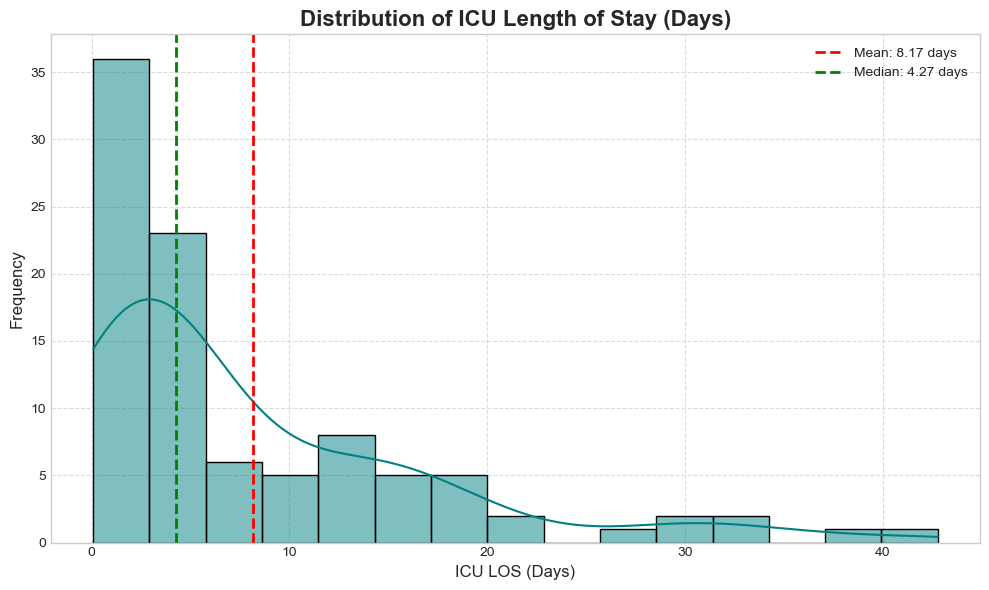


Target Variable Summary:
count    97.000000
mean      8.168637
std       9.060169
min       0.078368
25%       1.940949
50%       4.270961
75%      13.510162
max      42.776019
Name: ICU_LOS_days, dtype: float64


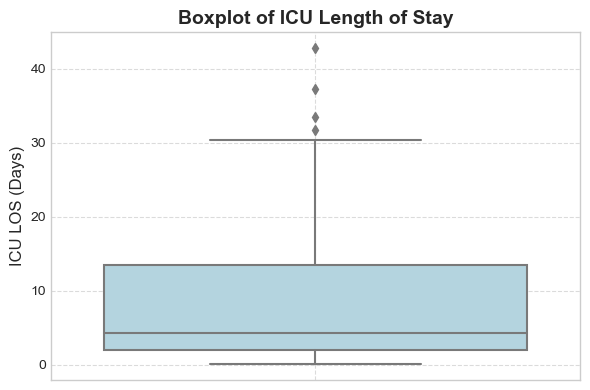

In [21]:
# =============================================================================
# Step 9: Basic Exploration of the Target Variable (ICU_LOS_days)
# =============================================================================

# Set a professional plot style for EDA
plt.style.use('seaborn-v0_8-whitegrid')

# --- Distribution of ICU_LOS_days ---
plt.figure(figsize=(10, 6))
sns.histplot(final_df['ICU_LOS_days'], kde=True, bins=15, color='teal', edgecolor='black') # Fewer bins for n=97
mean_los = final_df['ICU_LOS_days'].mean()
median_los = final_df['ICU_LOS_days'].median()
plt.axvline(mean_los, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_los:.2f} days')
plt.axvline(median_los, color='green', linestyle='dashed', linewidth=2, label=f'Median: {median_los:.2f} days')
plt.title('Distribution of ICU Length of Stay (Days)', fontsize=16, fontweight='bold')
plt.xlabel('ICU LOS (Days)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nTarget Variable Summary:")
print(final_df['ICU_LOS_days'].describe())
# Observation: The distribution is strongly right-skewed (mean > median), typical for LOS. Outliers exist.

# --- Boxplot for ICU_LOS_days ---
plt.figure(figsize=(6, 4))
sns.boxplot(y=final_df['ICU_LOS_days'], color='lightblue')
plt.title('Boxplot of ICU Length of Stay', fontsize=14, fontweight='bold')
plt.ylabel('ICU LOS (Days)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
# Observation: Confirms skewness and shows several high outliers.

*   **Histogram with KDE**: A histogram is plotted to visualize the frequency distribution of ICU LOS. A Kernel Density Estimate (KDE) curve is overlaid to show the smoothed shape. Vertical dashed lines indicate the mean and median LOS.
    *   **Observation**: The distribution is clearly **right-skewed**, with most stays being relatively short (concentrated below 10 days), but a long tail extending to longer stays (up to ~43 days). The mean LOS (8.17 days) is significantly higher than the median LOS (4.27 days), confirming the skewness caused by the longer stays. This skewness is very common for length of stay data.
*   **Box Plot**: A box plot provides a different view of the distribution, highlighting the median, interquartile range (IQR), and potential outliers.
    *   **Observation**: The box plot reinforces the right-skewness seen in the histogram. The median line is closer to the bottom of the box (Q1). Several data points are identified as outliers beyond the upper whisker, representing patients with exceptionally long ICU stays compared to the majority of the cohort.

**Implications**: The pronounced right-skewness of `ICU_LOS_days` is a key finding. Many standard regression models (like basic Linear Regression) assume a normally distributed error term, which might be violated here. This suggests potential strategies for modeling:
1.  Transforming the target variable (e.g., using a log transformation) might make its distribution more symmetric, potentially improving model performance and adherence to assumptions.
2.  Using models less sensitive to skewed data or outliers (e.g., tree-based models like Random Forest, or robust regression methods).
3.  Using evaluation metrics that are less sensitive to extreme values (e.g., Mean Absolute Error (MAE) in addition to Root Mean Squared Error (RMSE)).

# This step explores the basic characteristics of the patient cohort (n=97) focusing on age, gender, and admission type, and examines the relationship between gender and ICU LOS.

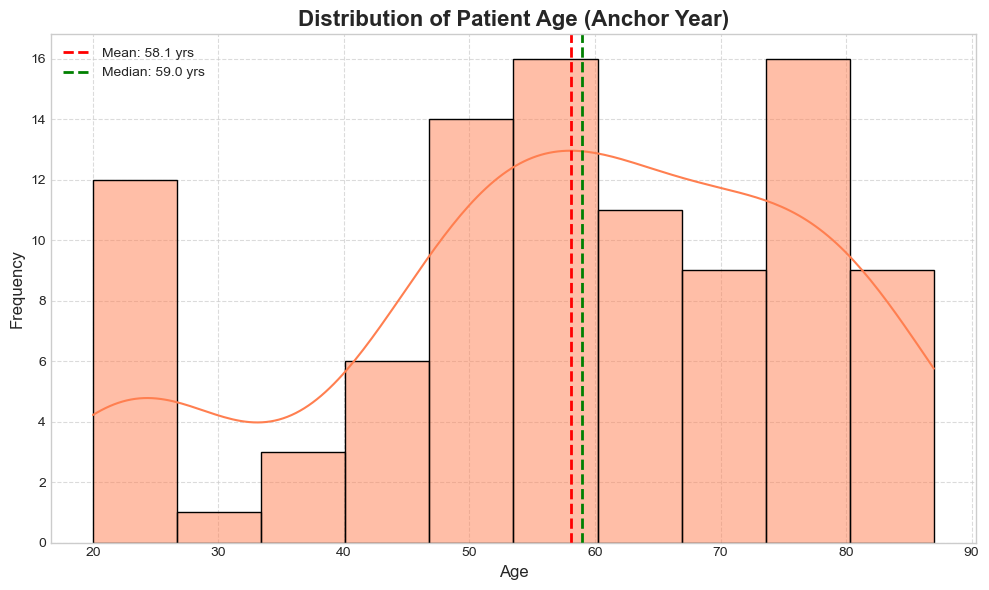

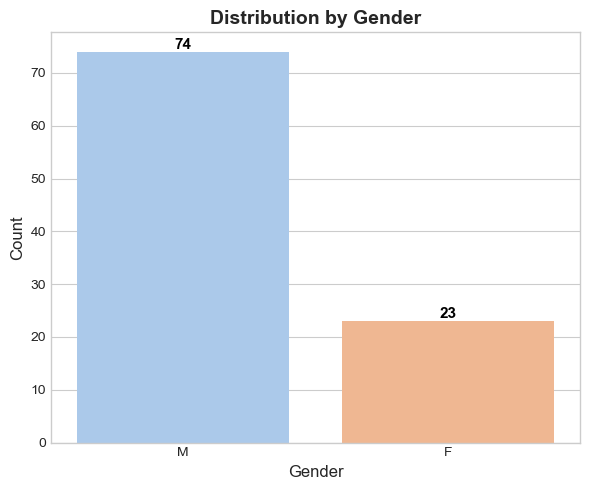

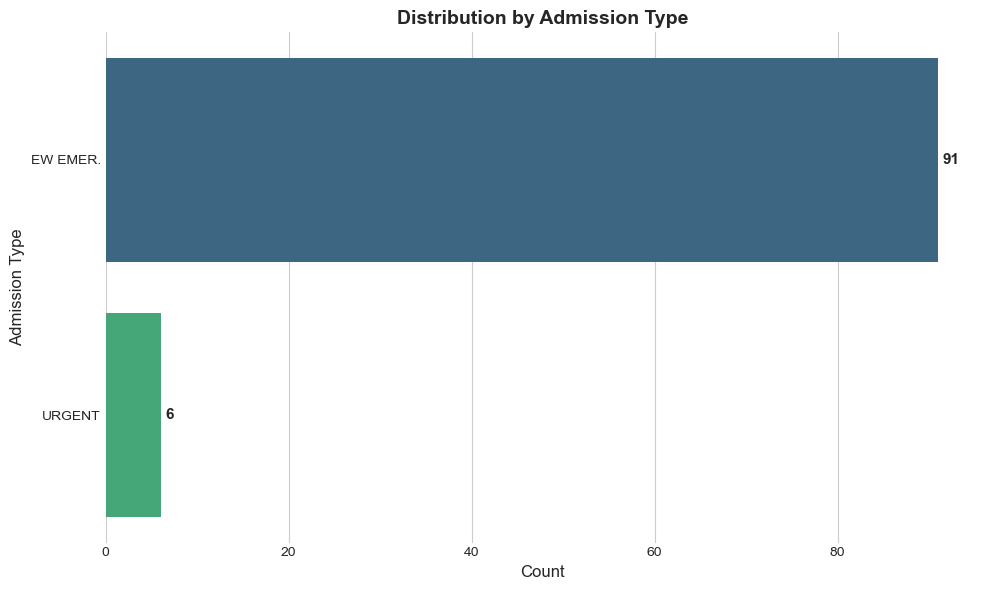

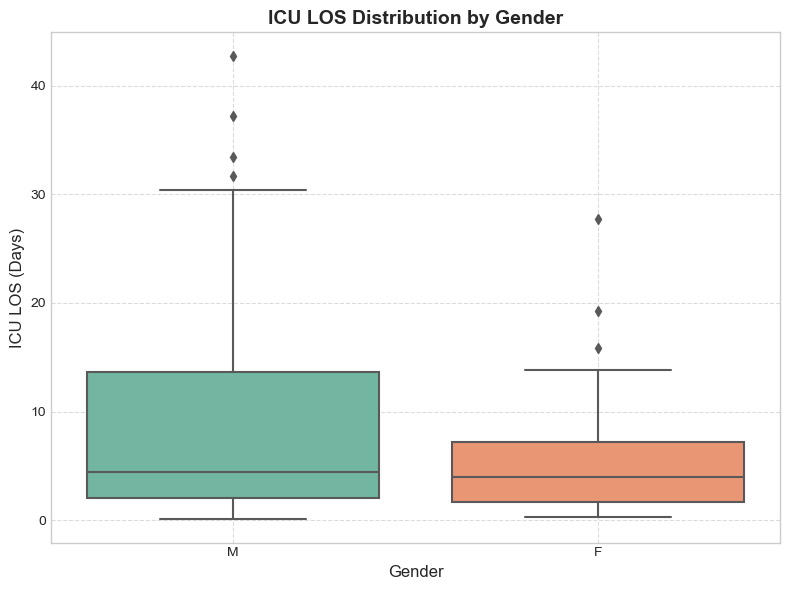

T-test (ICU LOS vs Gender): Statistic=-1.18, p-value=0.243


In [24]:
# =============================================================================
# Step 10: Explore Demographics and Basic Admission Details
# =============================================================================

from scipy import stats

# --- Age Distribution ---
plt.figure(figsize=(10, 6))
sns.histplot(final_df['anchor_age'], kde=True, bins=10, color='coral', edgecolor='black') # Bins adjusted
mean_age = final_df['anchor_age'].mean()
median_age = final_df['anchor_age'].median()
plt.axvline(mean_age, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_age:.1f} yrs')
plt.axvline(median_age, color='green', linestyle='dashed', linewidth=2, label=f'Median: {median_age:.1f} yrs')
plt.title('Distribution of Patient Age (Anchor Year)', fontsize=16, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
# Observation: Age distribution seems somewhat bimodal or spread out, centered around late 50s.

# --- Gender Distribution ---
plt.figure(figsize=(6, 5))
ax = sns.countplot(x='gender', data=final_df, palette='pastel', order=final_df['gender'].value_counts().index)
plt.title('Distribution by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Count', fontsize=12)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold', color='black')
plt.tight_layout()
plt.show()
# Observation: Predominantly Male cohort (74 vs 23).

# --- Admission Type Distribution ---
plt.figure(figsize=(10, 6))
ax = sns.countplot(y='admission_type', data=final_df, palette='viridis', order=final_df['admission_type'].value_counts().index)
plt.title('Distribution by Admission Type', fontsize=14, fontweight='bold')
plt.xlabel('Count', fontsize=12)
plt.ylabel('Admission Type', fontsize=12)
for p in ax.patches:
        width = p.get_width()
        plt.text(width + 0.5, p.get_y() + p.get_height()/2, f'{int(width)}', va='center', fontsize=11, fontweight='bold') # Adjusted text position
plt.box(False) # Remove frame for cleaner look
plt.tight_layout()
plt.show()
# Observation: Overwhelmingly 'EW EMER.' (Emergency Ward / Emergency), with a few 'URGENT'. Consistent with traumatic injury.

# --- ICU LOS vs Gender ---
plt.figure(figsize=(8, 6))
sns.boxplot(x='gender', y='ICU_LOS_days', data=final_df, palette='Set2')
plt.title('ICU LOS Distribution by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('ICU LOS (Days)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
# Observation: Median LOS appears slightly higher for Males, but distributions overlap considerably. Outliers present in both.

# T-test for Gender vs ICU LOS
gender_groups_los = [group['ICU_LOS_days'].dropna().values for name, group in final_df.groupby('gender')]
if len(gender_groups_los) == 2 and len(gender_groups_los[0]) > 1 and len(gender_groups_los[1]) > 1:
    t_stat_los, p_val_los = stats.ttest_ind(*gender_groups_los, equal_var=False) # Welch's t-test better for unequal variances/sizes
    print(f"T-test (ICU LOS vs Gender): Statistic={t_stat_los:.2f}, p-value={p_val_los:.3f}")
    # Observation: p-value (0.243) is > 0.05, suggesting no statistically significant difference in mean ICU LOS between genders in this small sample.
else:
    print("Could not perform t-test for ICU LOS vs Gender (insufficient data or groups).")

*   **Age Distribution**:
    *   A histogram shows the distribution of patient ages (`anchor_age`).
    *   **Observation**: The cohort includes patients across a wide age range (20 to 87 years), with a concentration of patients in their 50s, 70s, and 80s. The distribution isn't strongly peaked, with a mean age of 58.1 years and a median age of 59.0 years, suggesting a relatively older cohort overall, which is common for significant trauma.
*   **Gender Distribution**:
    *   A count plot visualizes the number of male ('M') and female ('F') patients.
    *   **Observation**: The cohort is predominantly male (74 males vs. 23 females, approximately 3.2:1 ratio). This is consistent with epidemiological data showing higher rates of traumatic injuries, including SCI, in males.
*   **Admission Type Distribution**:
    *   A horizontal count plot shows the types of hospital admissions leading to the ICU stay.
    *   **Observation**: The vast majority of admissions (91 out of 97) are classified as 'EW EMER.' (Emergency Ward / Emergency). A small number (6) are 'URGENT'. This strongly confirms that the cohort consists almost entirely of patients admitted through emergency routes, as expected for acute traumatic injuries.
*   **ICU LOS vs. Gender**:
    *   Box plots compare the distribution of `ICU_LOS_days` between male and female patients.
    *   A Welch's t-test is performed to formally compare the mean ICU LOS between the two genders.
    *   **Observation**: Visually, the median LOS appears slightly higher for males, and the distribution for males has a wider IQR and more high-end outliers. However, the distributions overlap considerably. The Welch's t-test yields a **p-value of 0.243**, which is greater than the conventional significance level of 0.05.
    *   **Conclusion**: Based on this initial analysis of our relatively small cohort, there is **no statistically significant evidence** to suggest a difference in the *mean* ICU Length of Stay between male and female patients with cervical spinal cord injury. Gender, by itself, may not be a strong predictor of LOS in this specific group, although interactions with other factors could still exist.

# This step involves exploring the distributions of the engineered features and examining their relationship with the target variable, `ICU_LOS_days`. We focus on the event counts and key physiological variables summarized over the first 24 hours (+/- 6h buffer).


Distributions of Count Features:


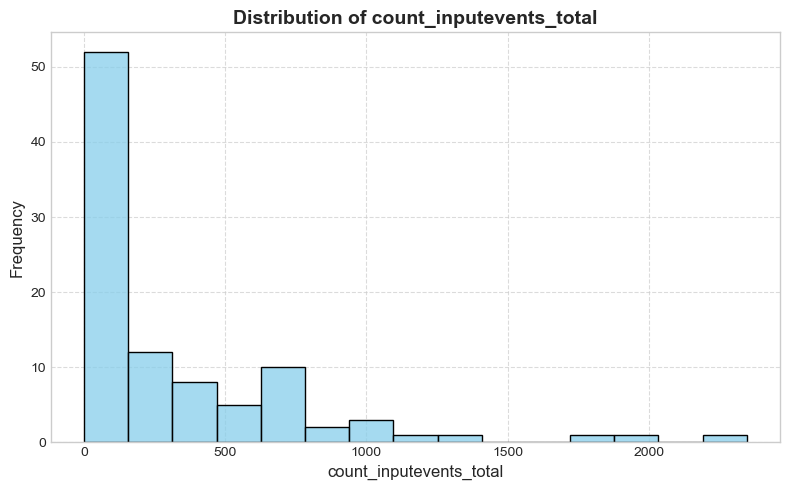

count_inputevents_total Summary:
count      97.000000
mean      337.556701
std       435.659868
min         1.000000
25%        56.000000
50%       141.000000
75%       489.000000
max      2347.000000
Name: count_inputevents_total, dtype: float64



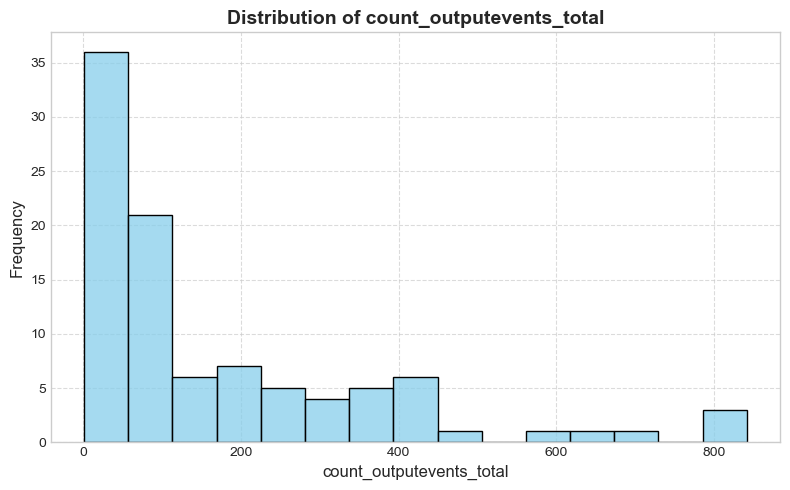

count_outputevents_total Summary:
count     97.000000
mean     171.422680
std      196.373148
min        1.000000
25%       36.000000
50%       78.000000
75%      271.000000
max      842.000000
Name: count_outputevents_total, dtype: float64



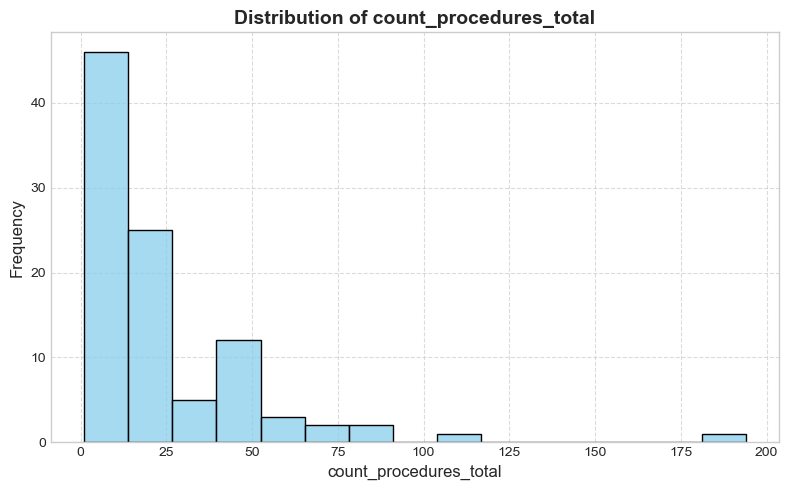

count_procedures_total Summary:
count     97.000000
mean      24.195876
std       27.477506
min        1.000000
25%        8.000000
50%       15.000000
75%       34.000000
max      194.000000
Name: count_procedures_total, dtype: float64



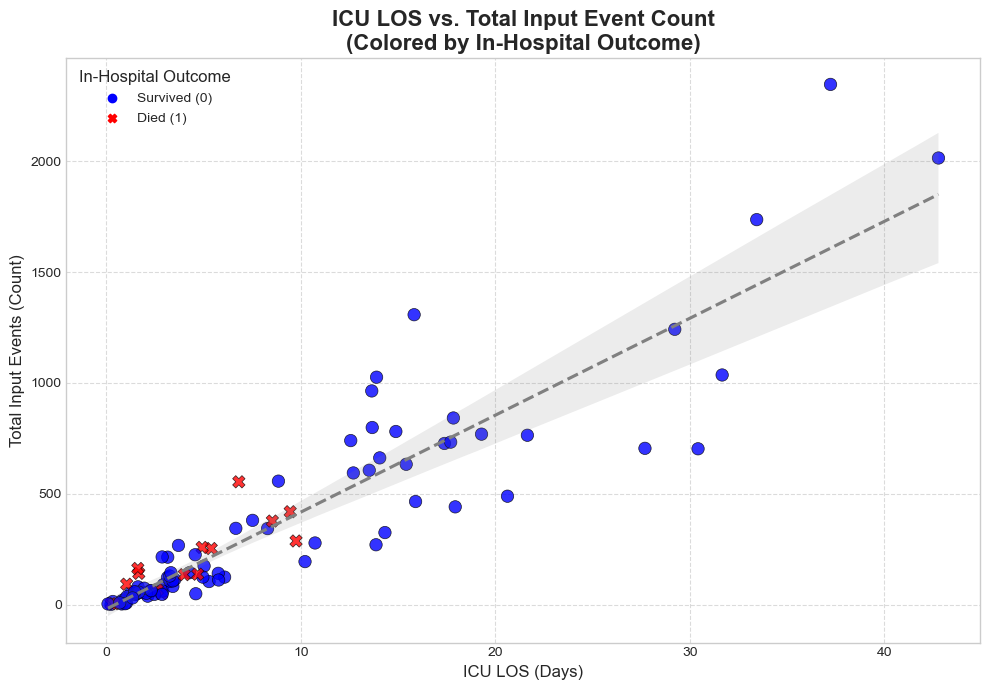

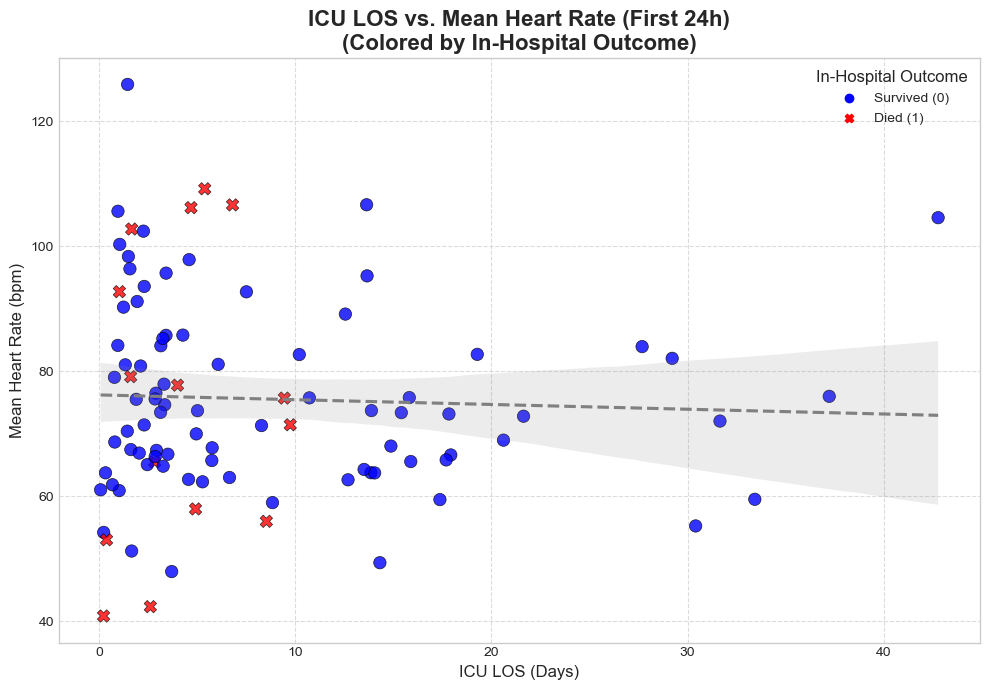

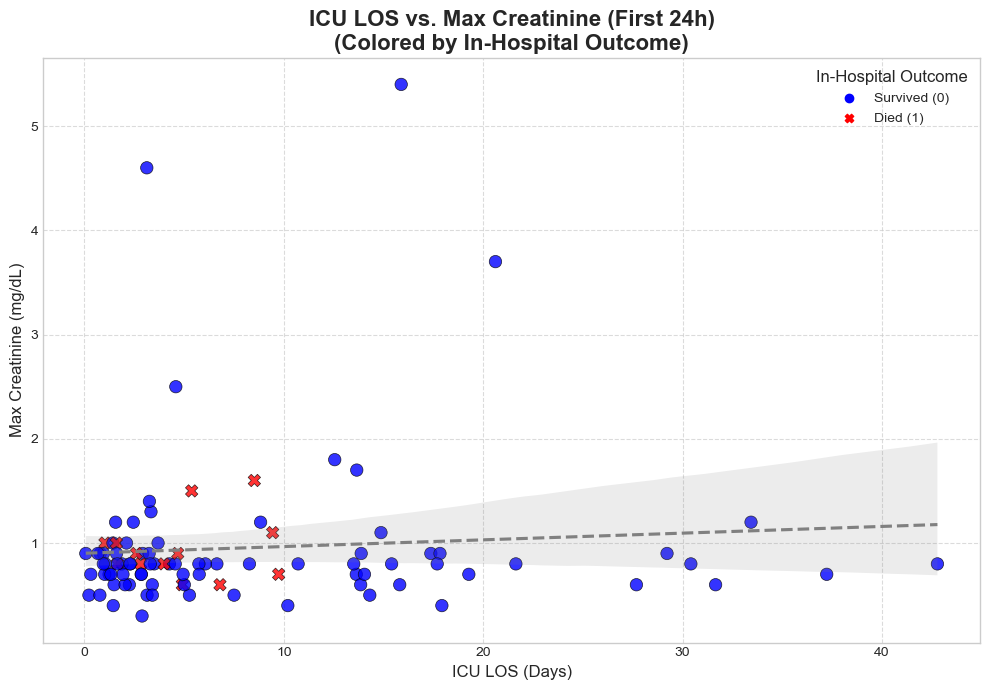

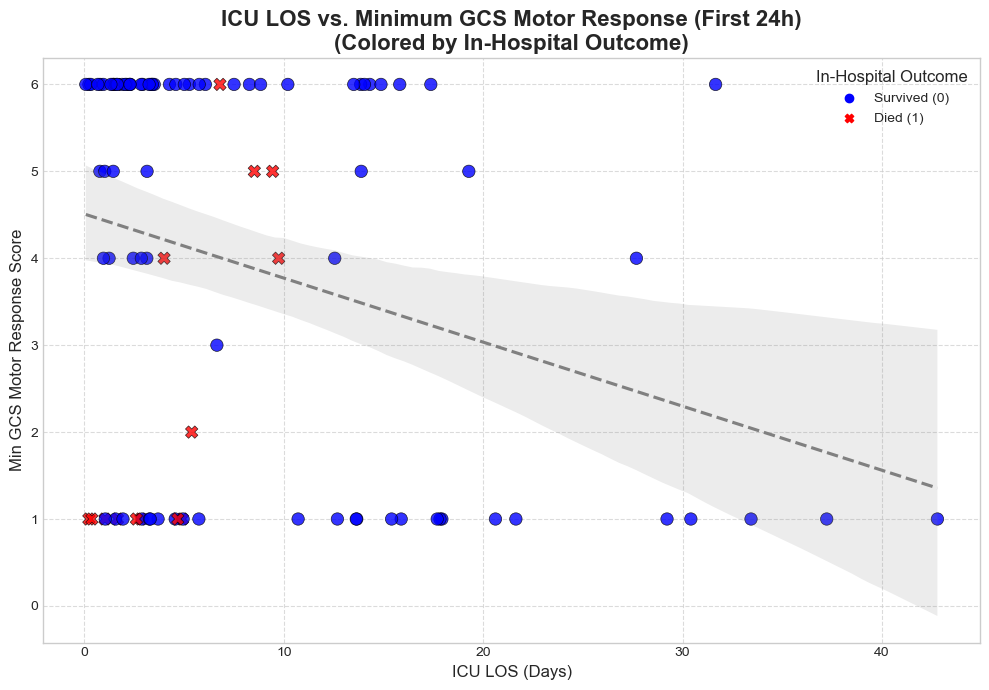

In [27]:
# =============================================================================
# Step 11: Explore Engineered Features (Counts & First 24h Physio)
# =============================================================================

# --- Distributions of Count Features ---
print("\nDistributions of Count Features:")
for col in count_cols:
    if col in final_df.columns:
        plt.figure(figsize=(8, 5))
        # Handle potential NaN if fillna didn't run correctly
        data_to_plot = final_df[col].dropna()
        if not data_to_plot.empty:
            sns.histplot(data_to_plot, bins=15, kde=False, color='skyblue', edgecolor='black') # Adjusted bins for n=97
            plt.title(f'Distribution of {col}', fontsize=14, fontweight='bold')
            plt.xlabel(col, fontsize=12)
            plt.ylabel('Frequency', fontsize=12)
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout()
            plt.show()
            print(f"{col} Summary:\n{data_to_plot.describe()}\n")
        else:
            print(f"Skipping histogram for {col} as it contains only NaNs or is empty.")
    else:
        print(f"Column {col} not found for histogram.")
# Observation: Counts are highly right-skewed, indicating many stays have few events, while some have many.

# --- Scatter plots: ICU LOS vs. Selected Features ---
# Use a function for consistency
def plot_los_vs_feature(df, feature_col, title, xlabel, ylabel):
    if feature_col not in df.columns:
        print(f"Skipping plot: Column '{feature_col}' not found.")
        return
    plt.figure(figsize=(10, 7))
    # Make sure target and hue column are present
    required_plot_cols = [feature_col, 'ICU_LOS_days', 'hospital_expire_flag']
    if not all(c in df.columns for c in required_plot_cols):
        print(f"Skipping plot for {feature_col}: Required columns missing ({required_plot_cols}).")
        return

    df_plot = df.dropna(subset=required_plot_cols) # Drop NaNs for specific plot
    if df_plot.empty:
        print(f"Skipping plot for {feature_col}: No non-NaN data available after dropping NaNs.")
        return

    # Define colors for the hue
    palette_colors = {0: 'blue', 1: 'red'} # 0: Survived (Blue), 1: Died (Red)

    scatter = sns.scatterplot(
        x='ICU_LOS_days',
        y=feature_col,
        hue='hospital_expire_flag',
        style='hospital_expire_flag',
        data=df_plot,
        palette=palette_colors,
        alpha=0.8, s=80, edgecolor='black', linewidth=0.5
    )
    # Add regression line (use with caution due to skewness/outliers/small N)
    sns.regplot(x='ICU_LOS_days', y=feature_col, data=df_plot, scatter=False, color='grey', line_kws={'linestyle':'--'})

    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)

    handles, labels = scatter.get_legend_handles_labels()
    # Create mapping from numerical label (0, 1) to descriptive label
    label_map = { '0': 'Survived (0)', '1': 'Died (1)'}
    # Filter out the legend title 'hospital_expire_flag' automatically added by seaborn if present
    valid_handles = []
    valid_labels = []
    processed_labels = set() # Avoid duplicate legend entries if hue/style map to same description
    for handle, label in zip(handles, labels):
        if label in label_map and label not in processed_labels: # Check if the label corresponds to 0 or 1 and not already added
             valid_handles.append(handle)
             valid_labels.append(label_map[label]) # Use the descriptive label
             processed_labels.add(label)

    if valid_handles: # Only show legend if there are valid handles/labels
        plt.legend(handles=valid_handles, labels=valid_labels, title='In-Hospital Outcome', loc='best', title_fontsize='12', fontsize='10')

    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Plotting selected features vs LOS
plot_los_vs_feature(final_df, 'count_inputevents_total',
                    'ICU LOS vs. Total Input Event Count\n(Colored by In-Hospital Outcome)',
                    'ICU LOS (Days)', 'Total Input Events (Count)')
# Observation: Positive trend visible - longer stays tend to have more input events. Deaths seem spread across LOS/counts.

plot_los_vs_feature(final_df, 'HeartRate_mean',
                    'ICU LOS vs. Mean Heart Rate (First 24h)\n(Colored by In-Hospital Outcome)',
                    'ICU LOS (Days)', 'Mean Heart Rate (bpm)')
# Observation: No clear linear trend between mean heart rate and LOS. Deaths don't show a distinct pattern here.

plot_los_vs_feature(final_df, 'Creatinine_max',
                    'ICU LOS vs. Max Creatinine (First 24h)\n(Colored by In-Hospital Outcome)',
                    'ICU LOS (Days)', 'Max Creatinine (mg/dL)')
# Observation: Higher creatinine values might be associated with longer stays or death, but data is sparse and relationship isn't strong.

plot_los_vs_feature(final_df, 'GCS_MotorResponse_min',
                    'ICU LOS vs. Minimum GCS Motor Response (First 24h)\n(Colored by In-Hospital Outcome)',
                    'ICU LOS (Days)', 'Min GCS Motor Response Score')
# Observation: Patients with very low minimum GCS motor scores (e.g., 1) might have longer LOS, potentially indicating more severe injury/coma. Deaths appear more frequent at lower scores.

1.  **Distribution of Count Features**:
    *   Histograms are generated for the count of input events, output events, and procedures occurring within the first 24-hour window. Summary statistics are displayed below each plot.
    *   **Observation**: All count features (`count_inputevents_first24h`, `count_outputevents_first24h`, `count_procedures_first24h`) exhibit strong **right-skewness**. Most ICU stays have relatively few recorded events in the initial period, while a smaller number of stays involve a very high number of events. This suggests high variability in initial clinical activity or documentation intensity.

2.  **Bivariate Analysis: ICU LOS vs. Selected Features**:
    *   Scatter plots are created to visualize the relationship between `ICU_LOS_days` and selected engineered features. Points are colored and shaped based on the patient's in-hospital outcome (`hospital_expire_flag`: 0=Survived, 1=Died). A regression line is overlaid to suggest potential trends (interpreted cautiously).
    *   **ICU LOS vs. Total Input Events**:
        *   **Observation**: A clear **positive trend** is visible. Longer ICU stays are strongly associated with a higher total number of input events recorded in the first 24 hours. This likely reflects that patients requiring more interventions (fluids, medications) early on tend to have longer and more complex stays. Deaths (red 'X's) are somewhat clustered at lower LOS but also appear at longer stays, often with higher input counts.
    *   **ICU LOS vs. Mean Heart Rate (First 24h)**:
        *   **Observation**: There is **no apparent linear relationship** between the average heart rate in the first 24 hours and the total ICU LOS. Patients who died do not show a distinct pattern concerning mean heart rate in this plot. Heart rate alone might not be a strong predictor of overall LOS duration in this cohort.
    *   **ICU LOS vs. Max Creatinine (First 24h)**:
        *   **Observation**: The relationship appears **weak**. While some patients with very high maximum creatinine levels (>2 mg/dL) have longer stays or died, most patients have creatinine levels within the normal range (<1.5 mg/dL) regardless of their LOS. The data is sparse at higher creatinine levels.
    *   **ICU LOS vs. Minimum GCS Motor Response (First 24h)**:
        *   **Observation**: A potential **negative trend** is suggested. Patients with the lowest minimum GCS motor scores (1, indicating no motor response) tend to be spread across various LOS, including very long stays. Patients scoring higher (e.g., 6, obeying commands) tend to have shorter stays, although overlap exists. Deaths appear more frequently among patients with lower minimum GCS motor scores (scores 1-5). This aligns with the clinical expectation that lower GCS scores indicate more severe neurological impairment, potentially leading to longer recovery times or higher mortality.

**Summary**: This initial exploration reveals that simple event counts within the first 24 hours show a strong positive association with LOS. Some physiological indicators like minimum GCS motor score show potential negative associations, while others like mean heart rate show little relationship. These insights can help guide feature selection and model building.

# This step investigates the linear relationships between the numeric features and the target variable (`ICU_LOS_days`), and also assesses multicollinearity among the predictor features.

Excluding features due to high missingness/unreliable correlations: ['SpO2_min', 'SpO2_max', 'SpO2_mean', 'Bilirubin_Total_min', 'Bilirubin_Total_max', 'Bilirubin_Total_mean']

Calculating correlation matrix for 78 potentially reliable numeric features.
Recalculating for 78 non-all-NaN numeric features.


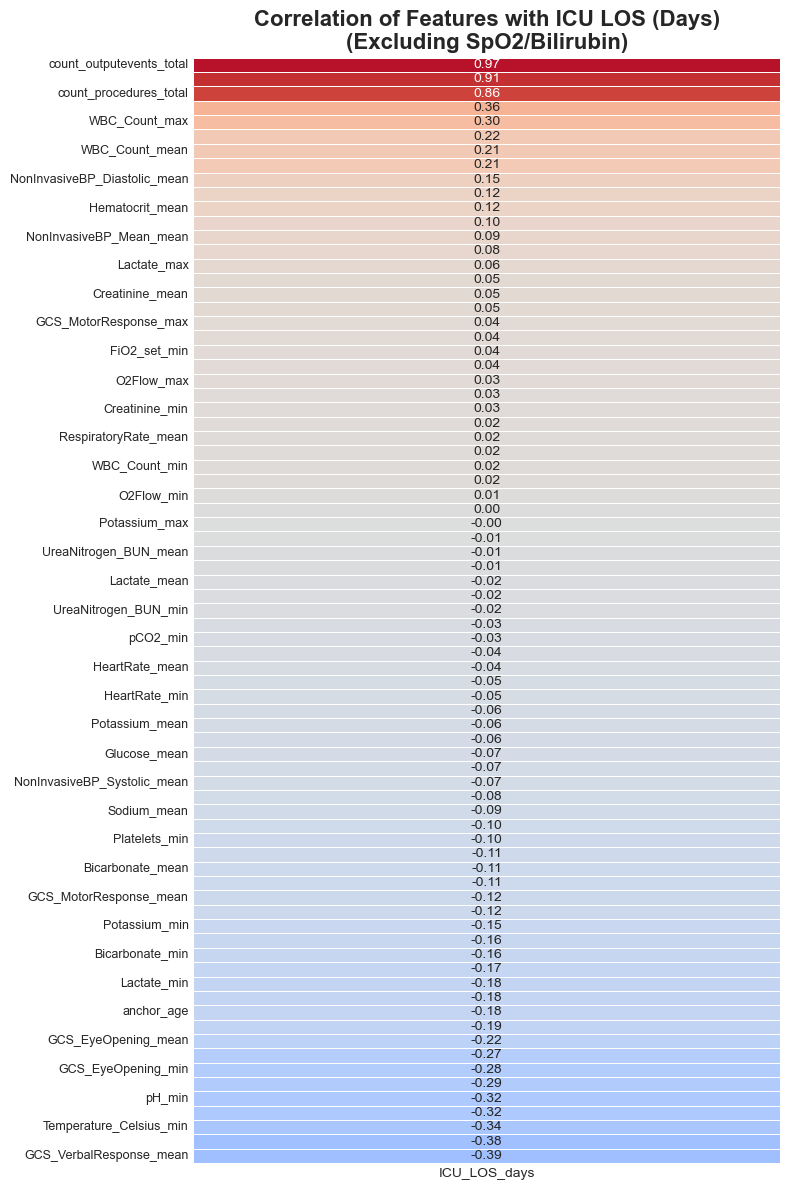


Correlation with ICU_LOS_days (Top/Bottom 15 - Excluding SpO2/Bilirubin):
Top 15 Positive Correlations:
count_outputevents_total        0.974584
count_inputevents_total         0.909379
count_procedures_total          0.858391
pCO2_max                        0.362550
WBC_Count_max                   0.303225
pCO2_mean                       0.215890
WBC_Count_mean                  0.212997
Hematocrit_max                  0.207546
NonInvasiveBP_Diastolic_mean    0.148525
NonInvasiveBP_Diastolic_min     0.123308
Hematocrit_mean                 0.120930
FiO2_set_max                    0.101422
NonInvasiveBP_Mean_mean         0.088383
Creatinine_max                  0.079023
Lactate_max                     0.064600
Name: ICU_LOS_days, dtype: float64

Top 15 Negative Correlations:
Bicarbonate_min            -0.162344
RespiratoryRate_min        -0.168652
Lactate_min                -0.175439
PaO2_min                   -0.178295
anchor_age                 -0.179382
pH_mean                    -0

In [30]:
# =============================================================================
# Step 12: Correlation Analysis
# =============================================================================

# --- Exclude highly missing/unreliable features BEFORE correlation ---
highly_missing_unreliable = [col for col in final_df.columns if 'SpO2_' in col or 'Bilirubin_Total_' in col]
print(f"Excluding features due to high missingness/unreliable correlations: {highly_missing_unreliable}")

# Select numeric columns for correlation (excluding IDs, flags, and unreliable)
numeric_cols_for_corr = final_df.select_dtypes(include=np.number).columns.tolist()
ids_and_flags_to_exclude = ['subject_id', 'hadm_id', 'stay_id', 'hospital_expire_flag']
time_cols_to_exclude = ['admission_year', 'icu_year'] # Add any other year/time columns if created

cols_to_exclude_corr = ids_and_flags_to_exclude + time_cols_to_exclude + highly_missing_unreliable
numeric_cols_for_corr = [col for col in numeric_cols_for_corr if col not in cols_to_exclude_corr]

print(f"\nCalculating correlation matrix for {len(numeric_cols_for_corr)} potentially reliable numeric features.")
# Handle potential remaining full-NaN columns before calculating correlation
final_df_numeric_corr = final_df[numeric_cols_for_corr].dropna(axis=1, how='all')
numeric_cols_for_corr = final_df_numeric_corr.columns.tolist() # Update list after dropping NaN cols
print(f"Recalculating for {len(numeric_cols_for_corr)} non-all-NaN numeric features.")

# Check if the DataFrame is empty after dropping NaN columns
if final_df_numeric_corr.empty or 'ICU_LOS_days' not in final_df_numeric_corr.columns:
    print("Correlation matrix cannot be calculated meaningfully: DataFrame is empty or target variable missing after exclusions.")
    corr_matrix = pd.DataFrame() # Assign empty DataFrame
else:
    corr_matrix = final_df_numeric_corr.corr()

    # --- Heatmap (Target correlations only for clarity) ---
    plt.figure(figsize=(8, 12)) # Adjusted height
    corr_target_heatmap = corr_matrix[['ICU_LOS_days']].sort_values(by='ICU_LOS_days', ascending=False)
    sns.heatmap(corr_target_heatmap.drop('ICU_LOS_days', errors='ignore'), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, cbar=False, vmin=-1, vmax=1) # Drop self-correlation for heatmap
    plt.title('Correlation of Features with ICU LOS (Days)\n(Excluding SpO2/Bilirubin)', fontsize=16, fontweight='bold')
    plt.yticks(fontsize=9) # Adjust font size as needed
    plt.tight_layout()
    plt.show()

    # --- Correlation with Target Variable (ICU_LOS_days) ---
    print("\nCorrelation with ICU_LOS_days (Top/Bottom 15 - Excluding SpO2/Bilirubin):")
    corr_with_target = corr_matrix['ICU_LOS_days'].drop('ICU_LOS_days', errors='ignore').sort_values(ascending=False) # Drop self-correlation safely
    print("Top 15 Positive Correlations:")
    print(corr_with_target.head(15))
    print("\nTop 15 Negative Correlations:")
    print(corr_with_target.tail(15))
    # Observation: Event counts remain highly correlated. Correlations for other features are generally weak to moderate. Exclusion of unreliable features gives a cleaner view.

# --- Identify Highly Correlated Predictor Pairs ---
threshold = 0.85
high_corr_pairs = []
if not corr_matrix.empty:
    cols = corr_matrix.columns
    processed_pairs = set() # To avoid duplicate reporting

    print(f"\nIdentifying highly correlated predictor pairs (|correlation| >= {threshold} - Excluding SpO2/Bilirubin):")

    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            col1 = cols[i]
            col2 = cols[j]

            # Skip correlations involving the target variable itself
            if col1 == 'ICU_LOS_days' or col2 == 'ICU_LOS_days':
                continue

            # Skip expected high correlations within same measure (min/max/mean)
            base1 = '_'.join(col1.split('_')[:-1])
            base2 = '_'.join(col2.split('_')[:-1])
            stat1 = col1.split('_')[-1]
            stat2 = col2.split('_')[-1]
            is_self_measure = (base1 == base2 and base1 != '' and stat1 in ['min','max','mean'] and stat2 in ['min','max','mean'])

            # Check correlation value
            corr_value = corr_matrix.loc[col1, col2]

            if abs(corr_value) >= threshold:
                pair_key = tuple(sorted((col1, col2))) # Use sorted tuple as key
                if pair_key not in processed_pairs:
                    high_corr_pairs.append({'Feature 1': col1, 'Feature 2': col2, 'Correlation': round(corr_value, 3), 'Is Self Measure': is_self_measure})
                    processed_pairs.add(pair_key)

    # Separate and Print
    self_measure_corr = [p for p in high_corr_pairs if p['Is Self Measure']]
    other_high_corr = [p for p in high_corr_pairs if not p['Is Self Measure']]

    print(f"\nHighly Correlated Within Same Measure (Min/Max/Mean, |r| >= {threshold}): {len(self_measure_corr)} pairs")
    if self_measure_corr:
        for pair in sorted(self_measure_corr, key=lambda x: abs(x['Correlation']), reverse=True)[:10]: # Show top 10 examples by magnitude
            print(f"- {pair['Feature 1']} vs {pair['Feature 2']}: {pair['Correlation']}")
        print("  (Expected due to feature engineering)")

    print(f"\nHighly Correlated Between Different Measures (|r| >= {threshold}): {len(other_high_corr)} pairs")
    if other_high_corr:
        for pair in sorted(other_high_corr, key=lambda x: abs(x['Correlation']), reverse=True):
            print(f"- {pair['Feature 1']} vs {pair['Feature 2']}: {pair['Correlation']}")
        # Observation: Counts remain highly correlated. NIBP measures are highly correlated. GCS components correlated. pH/pCO2/Bicarb show correlation. Removal of SpO2/Bilirubin cleans up the spurious correlations.
    else:
        print("  No highly correlated pairs found between different base measures.")

    print("\nDecision Point: Multicollinearity exists. Consider removing one feature from highly correlated pairs (e.g., keep only one NIBP measure, only 'count_inputevents_total') or use models robust to it (Lasso, Ridge, RF).")
else:
    print("\nSkipping highly correlated pairs analysis as correlation matrix is empty or target missing.")

1.  **Feature Exclusion**: Features identified in Step 8 as having extremely high missingness (>80%, specifically `SpO2_` and `Bilirubin_Total_` features in this case) are excluded *before* calculating correlations. This ensures the analysis is based on more reliable data points and avoids potentially spurious correlations driven by very small overlapping samples.
2.  **Correlation Matrix Calculation**: A Pearson correlation matrix is computed for the remaining reliable numeric features, including the target variable.
3.  **Correlation with Target (ICU LOS)**:
    *   **Heatmap**: A heatmap visualizes the correlation coefficients between each feature and `ICU_LOS_days`, sorted by correlation strength. This provides a quick visual overview of potential linear predictors.
    *   **Top/Bottom List**: The features with the highest positive and most negative (strongest negative) correlations with `ICU_LOS_days` are listed numerically.
    *   **Observations**:
        *   The event count features (`count_outputevents_first24h`, `count_inputevents_first24h`, `count_procedures_first24h`) show the **strongest positive correlations** (r > 0.85) with ICU LOS, confirming the trend seen in the scatter plots.
        *   Other moderate positive correlations include `pCO2_max` and `WBC_Count_max`.
        *   The strongest **negative correlations** are observed with GCS components (especially `GCS_VerbalResponse_mean`, `GCS_VerbalResponse_min`), minimum temperature, and minimum pH, suggesting that lower initial neurological function, lower temperature, and lower pH might be associated with longer stays.
        *   Many physiological features show relatively weak linear correlations (|r| < 0.2) with ICU LOS, suggesting non-linear relationships might be more important or their predictive power is limited individually.

4.  **Multicollinearity Check**:
    *   The correlation matrix is analyzed to identify pairs of *predictor* features that are highly correlated with each other (absolute correlation coefficient >= 0.85).
    *   High correlations are categorized into:
        *   **Within Same Base Measure**: Correlations between min, max, and mean of the *same* variable (e.g., `Creatinine_min` vs. `Creatinine_mean`). These are expected due to how the features were engineered. ~27 such pairs were found.
        *   **Between Different Base Measures**: Correlations between *different* types of variables (e.g., `count_inputevents` vs. `count_outputevents`, or `NIBP_Diastolic_mean` vs. `NIBP_Mean_mean`). These indicate potential multicollinearity issues for certain models. 5 such pairs were found in this analysis (primarily between the count features and between related NIBP components).
    *   **Implications**: The presence of high correlations between different predictor measures (multicollinearity) needs to be addressed before fitting models like standard Linear Regression, which are sensitive to it. Strategies include:
        *   Removing one feature from highly correlated pairs (e.g., keeping only one count feature, one NIBP measure).
        *   Using models that handle multicollinearity internally, such as Lasso/Ridge regression or tree-based models like Random Forests.

This correlation analysis helps identify key linear relationships and potential challenges like multicollinearity, informing subsequent feature selection and modeling choices.

# This step explores potential trends over the de-identified time period by grouping data into 10-year blocks for admissions counts, death counts, and ICU LOS distribution. Average LOS (ICU and Hospital) remains plotted yearly to highlight year-to-year instability. Helper columns for hospital LOS, admission year, ICU admission year, and a 10-year `year_group` based on admission year are calculated first.


--- Step 13: Time-Based Analysis (Grouped Admissions/Deaths/LOS Dist - 10 Year Blocks) ---
Created 'year_group' column with 10-year bins.

Visualizing trends over time (Admissions/Deaths/LOS Dist grouped by 10 years):


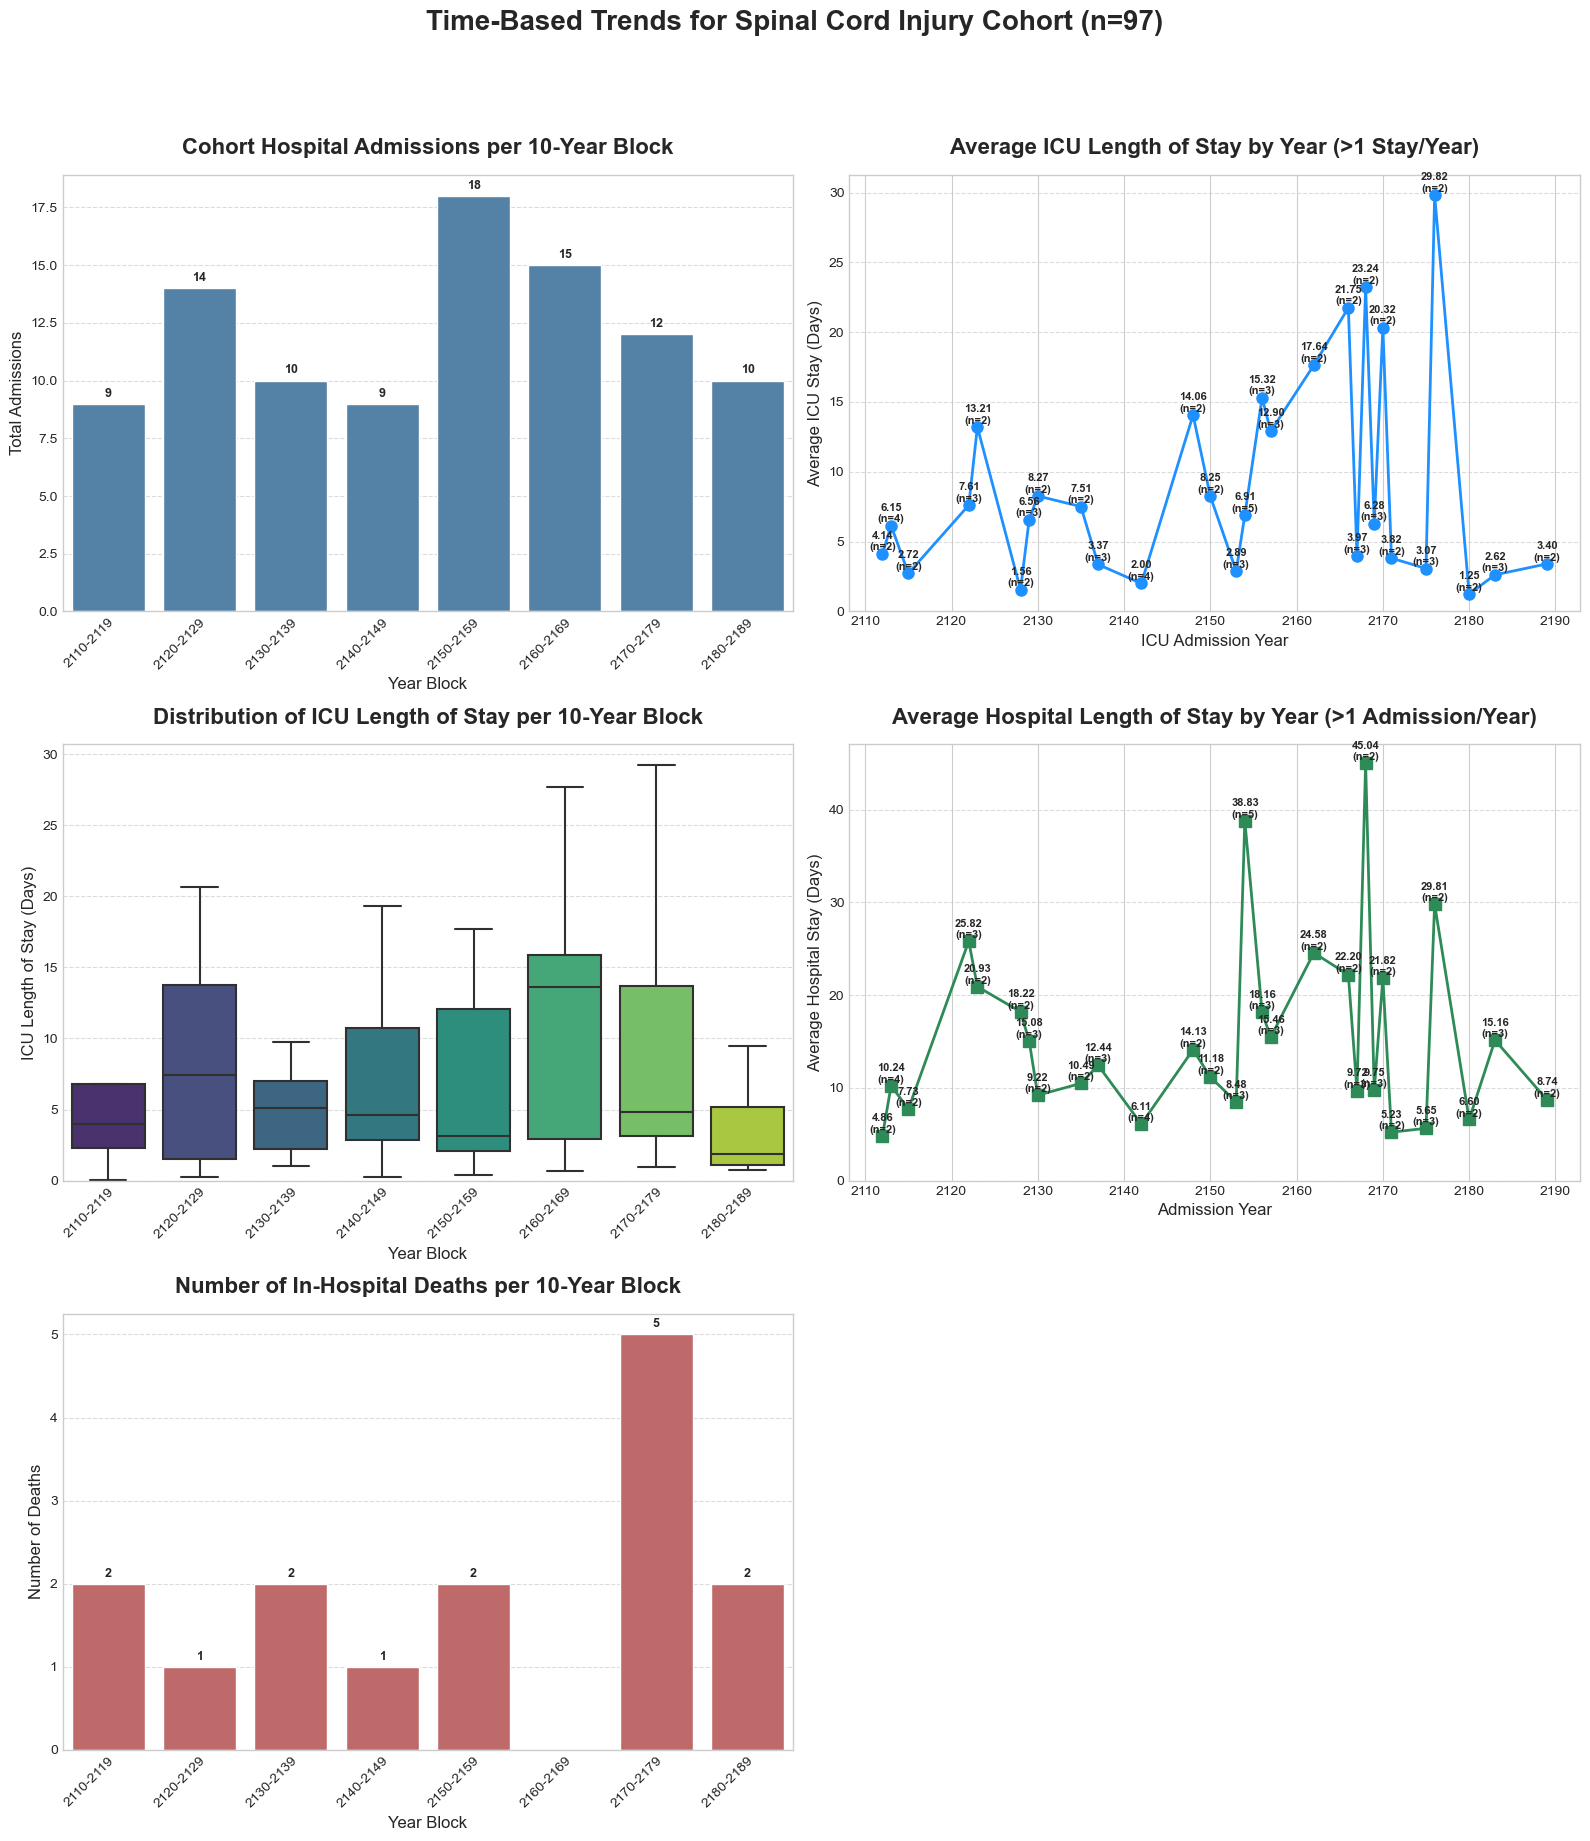

In [33]:
# =============================================================================
# Step 13: Time-Based Analysis 
# =============================================================================

# --- DEFINE PLOTTING FUNCTIONS ---

# Helper function remains the same
def format_plot(ax, title, xlabel, ylabel, rotate_labels=True, x_integer=False):
    """Helper function to format axes."""
    ax.set_title(title, fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.tick_params(axis='x', labelsize=10, rotation=45 if rotate_labels else 0)
    if rotate_labels:
         plt.setp(ax.get_xticklabels(), ha="right", rotation_mode="anchor")
    ax.tick_params(axis='y', labelsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    if x_integer: # Ensure integer ticks on x-axis if requested
        ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# 1. Admissions by Year Group (Uses dynamic bin_size in title)
def plot_admissions_by_year_group(df, bin_size, ax):
    if 'year_group' not in df.columns or df['year_group'].isnull().all():
        ax.text(0.5, 0.5, "No Year Group Data", ha='center', va='center', fontsize=12, color='red'); format_plot(ax, f'Admissions per {bin_size}-Year Block', 'Year Block', 'Count', rotate_labels=False); ax.set_xticks([]); ax.set_yticks([]); return

    try: # Ensure year_group is categorical for proper ordering
        # --- FIXED DTYPE CHECK ---
        if not isinstance(df['year_group'].dtype, pd.CategoricalDtype):
            df['year_group'] = df['year_group'].astype('category')
        # --- END FIX ---
        ordered_labels = sorted(df['year_group'].cat.categories, key=lambda x: int(x.split('-')[0]))
    except Exception as e:
        print(f"Warning: Could not sort year group labels, using default order. Error: {e}"); ordered_labels = None

    sns.countplot(x='year_group', data=df.dropna(subset=['year_group']), color='steelblue', order=ordered_labels, ax=ax)
    format_plot(ax, f'Cohort Hospital Admissions per {bin_size}-Year Block', 'Year Block', 'Total Admissions', rotate_labels=True)
    for p in ax.patches:
        height = p.get_height()
        if height > 0: ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2., height), ha='center', va='bottom', fontsize=9, fontweight='bold', xytext=(0, 3), textcoords='offset points')
    ax.set_ylim(bottom=0)

# 2. Average ICU Length of Stay by Year (Keep as Line Plot by Year - shows instability better)
def plot_avg_icu_los(df, ax):
    if 'icu_year' not in df.columns or 'ICU_LOS_days' not in df.columns or df['icu_year'].isnull().all():
        ax.text(0.5, 0.5, "No ICU Year/LOS Data", ha='center', va='center', fontsize=12, color='red'); format_plot(ax, 'Avg ICU LOS by Year', 'Year', 'Avg LOS (Days)', rotate_labels=False); ax.set_xticks([]); ax.set_yticks([]); return
    avg_icu_los = df.dropna(subset=['icu_year', 'ICU_LOS_days']).groupby('icu_year')['ICU_LOS_days'].agg(['mean', 'count']).reset_index()
    avg_icu_los = avg_icu_los[avg_icu_los['count'] > 1]

    if avg_icu_los.empty:
        ax.text(0.5, 0.5, "Insufficient Data Per Year (>1)", ha='center', va='center', fontsize=12, color='orange'); format_plot(ax, 'Avg ICU LOS by Year', 'Year', 'Avg LOS (Days)', rotate_labels=False); ax.set_xticks([]); ax.set_yticks([]); return

    avg_icu_los['icu_year'] = avg_icu_los['icu_year'].astype(int)
    ax.plot(avg_icu_los['icu_year'], avg_icu_los['mean'], marker='o', linestyle='-', linewidth=2, color='#1E90FF', markersize=8)
    format_plot(ax, 'Average ICU Length of Stay by Year (>1 Stay/Year)', 'ICU Admission Year', 'Average ICU Stay (Days)', rotate_labels=False, x_integer=True)
    for x, y, count in zip(avg_icu_los['icu_year'], avg_icu_los['mean'], avg_icu_los['count']):
        ax.text(x, y + 0.1, f'{y:.2f}\n(n={count})', horizontalalignment='center', verticalalignment='bottom', fontweight='bold', fontsize=8)
    ax.set_ylim(bottom=0)

# 3. ICU Length of Stay Distribution by Year Group (MODIFIED TO USE YEAR_GROUP)
def plot_icu_los_distribution_by_year_group(df, bin_size, ax):
    if 'year_group' not in df.columns or 'ICU_LOS_days' not in df.columns or df['year_group'].isnull().all():
        ax.text(0.5, 0.5, "No Year Group/LOS Data", ha='center', va='center', fontsize=12, color='red'); format_plot(ax, f'ICU LOS Distribution per {bin_size}-Year Block', 'Year Block', 'LOS (Days)', rotate_labels=False); ax.set_xticks([]); ax.set_yticks([]); return

    df_plot = df.dropna(subset=['year_group', 'ICU_LOS_days']).copy()
    try: # Ensure year_group is categorical for proper ordering
        # --- FIXED DTYPE CHECK ---
        if not isinstance(df_plot['year_group'].dtype, pd.CategoricalDtype):
             df_plot['year_group'] = df_plot['year_group'].astype('category')
        # --- END FIX ---
        ordered_labels = sorted(df_plot['year_group'].cat.categories, key=lambda x: int(x.split('-')[0]))
    except Exception as e:
        print(f"Warning: Could not sort year group labels for LOS boxplot, using default order. Error: {e}"); ordered_labels = None

    if df_plot.empty or not ordered_labels:
        ax.text(0.5, 0.5, "No Data", ha='center', va='center', fontsize=12, color='orange'); format_plot(ax, f'ICU LOS Distribution per {bin_size}-Year Block', 'Year Block', 'LOS (Days)', rotate_labels=False); ax.set_xticks([]); ax.set_yticks([]); return

    sns.boxplot(x='year_group', y='ICU_LOS_days', data=df_plot, palette='viridis', order=ordered_labels, ax=ax, showfliers=False)
    format_plot(ax, f'Distribution of ICU Length of Stay per {bin_size}-Year Block', 'Year Block', 'ICU Length of Stay (Days)', rotate_labels=True)
    ax.set_ylim(bottom=0)

# 4. Average Hospital Length of Stay by Year (Keep as Line Plot by Year - shows instability better)
def plot_avg_hospital_los(df, ax):
    if 'admission_year' not in df.columns or 'hospital_LOS_days' not in df.columns or df['admission_year'].isnull().all() or df['hospital_LOS_days'].isnull().all():
        ax.text(0.5, 0.5, "No Hospital LOS or Year Data", ha='center', va='center', fontsize=12, color='red'); format_plot(ax, 'Avg Hospital LOS by Year', 'Year', 'Avg LOS (Days)', rotate_labels=False); ax.set_xticks([]); ax.set_yticks([]); return
    avg_hosp_los = df.dropna(subset=['admission_year', 'hospital_LOS_days']).groupby('admission_year')['hospital_LOS_days'].agg(['mean', 'count']).reset_index()
    avg_hosp_los = avg_hosp_los[avg_hosp_los['count'] > 1]

    if avg_hosp_los.empty:
        ax.text(0.5, 0.5, "Insufficient Data Per Year (>1)", ha='center', va='center', fontsize=12, color='orange'); format_plot(ax, 'Avg Hospital LOS by Year', 'Year', 'Avg LOS (Days)', rotate_labels=False); ax.set_xticks([]); ax.set_yticks([]); return

    avg_hosp_los['admission_year'] = avg_hosp_los['admission_year'].astype(int)
    ax.plot(avg_hosp_los['admission_year'], avg_hosp_los['mean'], marker='s', linestyle='-', linewidth=2, color='#2E8B57', markersize=8)
    format_plot(ax, 'Average Hospital Length of Stay by Year (>1 Admission/Year)', 'Admission Year', 'Average Hospital Stay (Days)', rotate_labels=False, x_integer=True)
    for x, y, count in zip(avg_hosp_los['admission_year'], avg_hosp_los['mean'], avg_hosp_los['count']):
        ax.text(x, y + 0.1, f'{y:.2f}\n(n={count})', horizontalalignment='center', verticalalignment='bottom', fontweight='bold', fontsize=8)
    ax.set_ylim(bottom=0)

# 5. In-Hospital Deaths by Year Group (Uses dynamic bin_size in title)
def plot_in_hospital_deaths_by_year_group(df, bin_size, ax):
    if 'year_group' not in df.columns or 'hospital_expire_flag' not in df.columns or df['year_group'].isnull().all():
        ax.text(0.5, 0.5, "No Year Group or Death Data", ha='center', va='center', fontsize=12, color='red'); format_plot(ax, f'In-Hospital Deaths per {bin_size}-Year Block', 'Year Block', 'Count', rotate_labels=False); ax.set_xticks([]); ax.set_yticks([]); return

    death_counts = df.dropna(subset=['year_group']).groupby('year_group')['hospital_expire_flag'].agg(death_count='sum').reset_index()

    try: # Ensure year_group is categorical for proper ordering
        # --- FIXED DTYPE CHECK ---
        if not isinstance(df['year_group'].dtype, pd.CategoricalDtype):
             df['year_group'] = df['year_group'].astype('category')
        # --- END FIX ---
        ordered_labels = sorted(df['year_group'].cat.categories, key=lambda x: int(x.split('-')[0]))
    except Exception as e:
        print(f"Warning: Could not sort year group labels for death plot, using default order. Error: {e}"); ordered_labels = None

    sns.barplot(x='year_group', y='death_count', data=death_counts, color='indianred', order=ordered_labels, ax=ax)
    format_plot(ax, f'Number of In-Hospital Deaths per {bin_size}-Year Block', 'Year Block', 'Number of Deaths', rotate_labels=True)

    for p in ax.patches:
        height = p.get_height()
        if height > 0: ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2., height), ha='center', va='bottom', fontsize=9, fontweight='bold', xytext=(0, 3), textcoords='offset points')

    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.set_ylim(bottom=0)


# --- Calculations ---
print("\n--- Step 13: Time-Based Analysis (Grouped Admissions/Deaths/LOS Dist - 10 Year Blocks) ---")

# (Calculations for hospital_LOS_days, admission_year, icu_year remain the same)
# Ensure necessary datetime columns are correct type before calculations
for col in ['admittime', 'dischtime', 'intime']:
     if col in final_df.columns:
         final_df[col] = pd.to_datetime(final_df[col], errors='coerce')

# Calculate Hospital LOS
if 'dischtime' in final_df.columns and 'admittime' in final_df.columns:
    if pd.api.types.is_datetime64_any_dtype(final_df['dischtime']) and pd.api.types.is_datetime64_any_dtype(final_df['admittime']):
        final_df['hospital_LOS_days'] = (final_df['dischtime'] - final_df['admittime']).dt.total_seconds() / (3600 * 24)
        neg_hosp_los = final_df[final_df['hospital_LOS_days'] < 0].shape[0]
        if neg_hosp_los > 0: print(f"Warning: Found {neg_hosp_los} rows with negative hospital_LOS_days. Setting them to 0."); final_df.loc[final_df['hospital_LOS_days'] < 0, 'hospital_LOS_days'] = 0
    else: print("Warning: Could not calculate hospital_LOS_days due to invalid datetime conversion."); final_df['hospital_LOS_days'] = np.nan
else: print("Skipping hospital_LOS_days calculation: dischtime or admittime missing."); final_df['hospital_LOS_days'] = np.nan

# Extract individual years
if 'admittime' in final_df.columns and pd.api.types.is_datetime64_any_dtype(final_df['admittime']): final_df['admission_year'] = final_df['admittime'].dt.year
else: final_df['admission_year'] = np.nan
if 'intime' in final_df.columns and pd.api.types.is_datetime64_any_dtype(final_df['intime']): final_df['icu_year'] = final_df['intime'].dt.year
else: final_df['icu_year'] = np.nan

# --- Create Year Groups (Using bin_size=10) ---
bin_size = 10 # Set bin size to 10
year_col = 'admission_year'

if year_col in final_df.columns and not final_df[year_col].isnull().all():
    min_year = final_df[year_col].min()
    max_year = final_df[year_col].max()

    if pd.notna(min_year) and pd.notna(max_year):
        min_year = int(min_year)
        max_year = int(max_year)
        start_bin = math.floor(min_year / bin_size) * bin_size
        bins = list(range(start_bin, max_year + bin_size, bin_size))
        if bins[-1] <= max_year: bins.append(bins[-1] + bin_size)

        labels = [f"{bins[i]}-{bins[i+1]-1}" for i in range(len(bins)-1)]

        if labels:
             final_df['year_group'] = pd.cut(final_df[year_col], bins=bins, labels=labels, right=False, include_lowest=True)
             # --- FIXED DTYPE CHECK ---
             if not isinstance(final_df['year_group'].dtype, pd.CategoricalDtype):
                  # Convert to ordered categorical
                  final_df['year_group'] = pd.Categorical(final_df['year_group'], categories=labels, ordered=True)
             # --- END FIX ---
             print(f"Created 'year_group' column with {bin_size}-year bins.")
        else: print("Warning: Could not create year group labels."); final_df['year_group'] = np.nan
    else: print("Warning: Could not determine min/max year for grouping."); final_df['year_group'] = np.nan
else: print(f"Skipping year group creation: '{year_col}' missing or all NaN."); final_df['year_group'] = np.nan

# Add age group feature (same as before)
if 'anchor_age' in final_df.columns:
    age_bins = [18, 30, 45, 60, 75, 91]
    age_labels = ['18-30', '31-45', '46-60', '61-75', '76+']
    final_df['age_group'] = pd.cut(final_df['anchor_age'], bins=age_bins, labels=age_labels, right=False)
else: final_df['age_group'] = np.nan


# --- Create Subplots and Call Visualization Functions ---
print("\nVisualizing trends over time (Admissions/Deaths/LOS Dist grouped by 10 years):")
required_cols = ['admittime', 'intime', 'ICU_LOS_days', 'hospital_LOS_days',
                 'hospital_expire_flag', 'admission_year', 'icu_year', 'year_group']
missing_req_cols = [col for col in required_cols if col not in final_df.columns or final_df[col].isnull().all()]

if not missing_req_cols:
    sns.set_style("whitegrid")
    fig, axes = plt.subplots(3, 2, figsize=(16, 18))
    fig.suptitle("Time-Based Trends for Spinal Cord Injury Cohort (n={})".format(len(final_df)), fontsize=20, fontweight='bold', y=1.02)

    # Call plotting functions
    plot_admissions_by_year_group(final_df, bin_size, axes[0, 0])
    plot_avg_icu_los(final_df, axes[0, 1]) # Keep yearly avg LOS
    plot_icu_los_distribution_by_year_group(final_df, bin_size, axes[1, 0]) # Use grouped version
    plot_avg_hospital_los(final_df, axes[1, 1]) # Keep yearly avg Hosp LOS
    plot_in_hospital_deaths_by_year_group(final_df, bin_size, axes[2, 0])
    axes[2, 1].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

else:
    print(f"Skipping time-based visualizations due to missing or all-NaN required columns: {missing_req_cols}.")

1.  **Cohort Hospital Admissions per 10-Year Block**:
    *   **Chart**: Bar plot showing the total number of hospital admissions included in the cohort for each 10-year block (e.g., 2110-2119, 2120-2129, etc.).
    *   **Observation**: Grouping into decades provides slightly more substantial counts per bar compared to the yearly plot, ranging from 9 to 18 admissions per block. There isn't a clear monotonic increase or decrease, although some blocks (e.g., 2150s) appear busier than others within this specific cohort.

2.  **Average ICU Length of Stay by Year (>1 Stay/Year)**:
    *   **Chart**: Line plot connecting the average ICU LOS for each individual *year* (only including years with >1 stay). Points are annotated with the average LOS and the number of stays (n) contributing to that average.
    *   **Observation**: This plot is retained on a yearly basis to explicitly demonstrate the high volatility. The average ICU LOS swings dramatically from year to year, driven by the very small number of patients (often n=2 or n=3) each year. This reinforces the unreliability of using yearly averages for trend analysis.

3.  **Distribution of ICU Length of Stay per 10-Year Block**:
    *   **Chart**: Box plots showing the distribution (median, IQR) of ICU LOS for each 10-year block. Outliers are hidden (`showfliers=False`) to focus on the central tendency and spread.
    *   **Observation**: Visualizing the distribution per decade suggests potential shifts. For example, the median LOS and IQR appear higher in some later blocks (e.g., 2160s, 2170s) compared to earlier ones, although variability exists across all blocks. The number of patients per block is still small, making definitive conclusions difficult.

4.  **Average Hospital Length of Stay by Year (>1 Admission/Year)**:
    *   **Chart**: Line plot connecting the average *hospital* LOS for each individual *year* (only including years with >1 admission). Points are annotated with the average LOS and the number of admissions (n).
    *   **Observation**: Similar to the average ICU LOS plot, this yearly view highlights extreme volatility in average hospital LOS, again driven by very small sample sizes per year.

5.  **Number of In-Hospital Deaths per 10-Year Block**:
    *   **Chart**: Bar plot showing the total number of in-hospital deaths recorded for cohort members within each 10-year block.
    *   **Observation**: Grouping deaths by decade yields slightly larger counts per bar (ranging from 1 to 5 deaths per 10-year block) compared to the yearly view. While still low, it makes the visualization slightly less sparse. There's no obvious trend; the block 2170-2179 shows the highest count (5 deaths), but this corresponds to a period with only 12 admissions in the cohort, resulting in a high but potentially unstable mortality *rate* for that specific block.

**Overall Conclusion for Time-Based Analysis**: Grouping admissions, deaths, and LOS distributions into 10-year blocks provides a slightly more aggregated view than yearly plots, reducing some noise. However, the fundamental limitation of a small overall cohort size persists. Even within 10-year blocks, the number of patients remains low, making it difficult to confidently identify significant temporal trends in admissions, outcomes, or LOS for this specific patient group in this dataset. The yearly average LOS plots clearly demonstrate the instability inherent in analyzing such sparse data over fine-grained time intervals. Therefore, time-based features (`admission_year`, `icu_year`, `year_group`) are unlikely to be strong, reliable predictors in a model for *individual* patient LOS due to this aggregate-level instability and the de-identified nature of the years.

# This step examines the distributions of selected key numerical and categorical features within our final cohort dataset (`final_df`, n=97) to understand their characteristics and potential implications for modeling. Features with very high missingness (SpO2, Bilirubin) were excluded from the numerical plots.


Visualizing distributions of key numerical features (excluding SpO2/Bilirubin)...


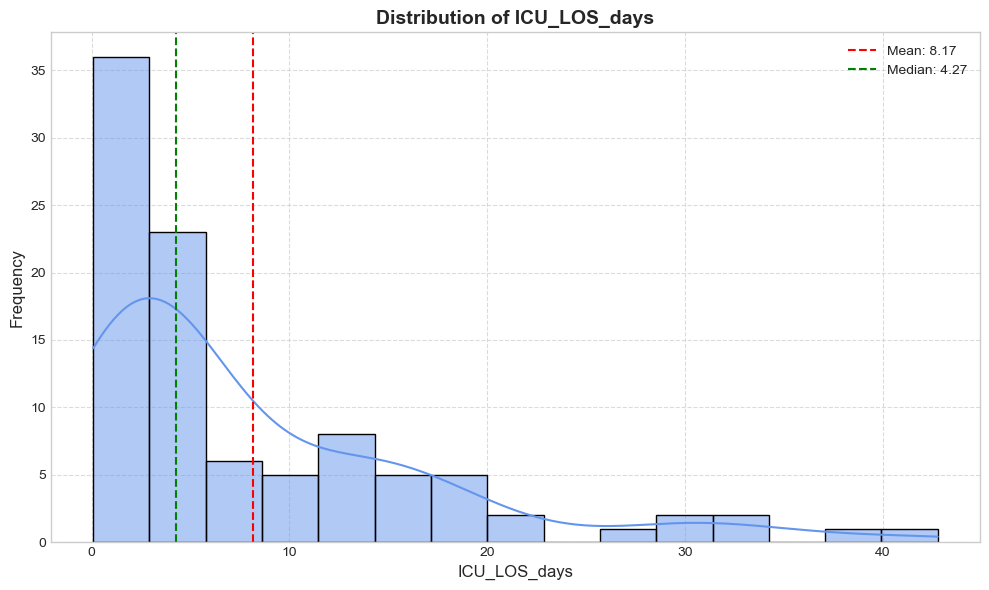

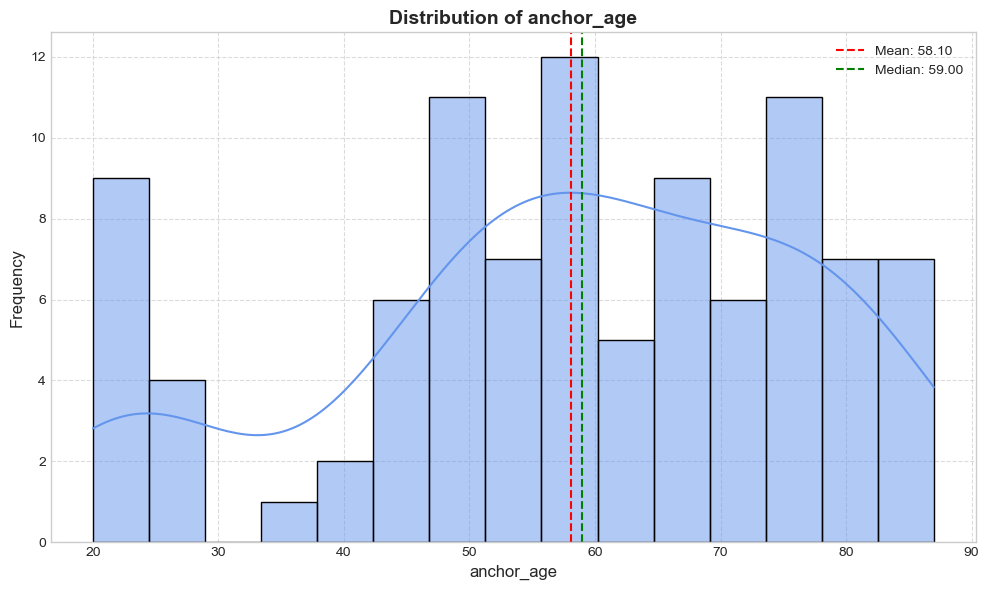

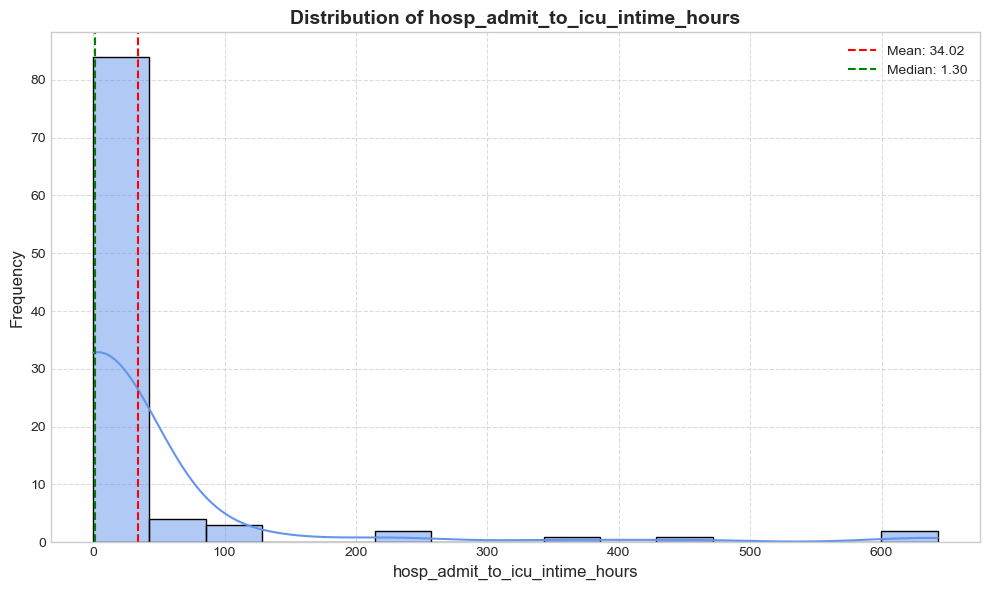

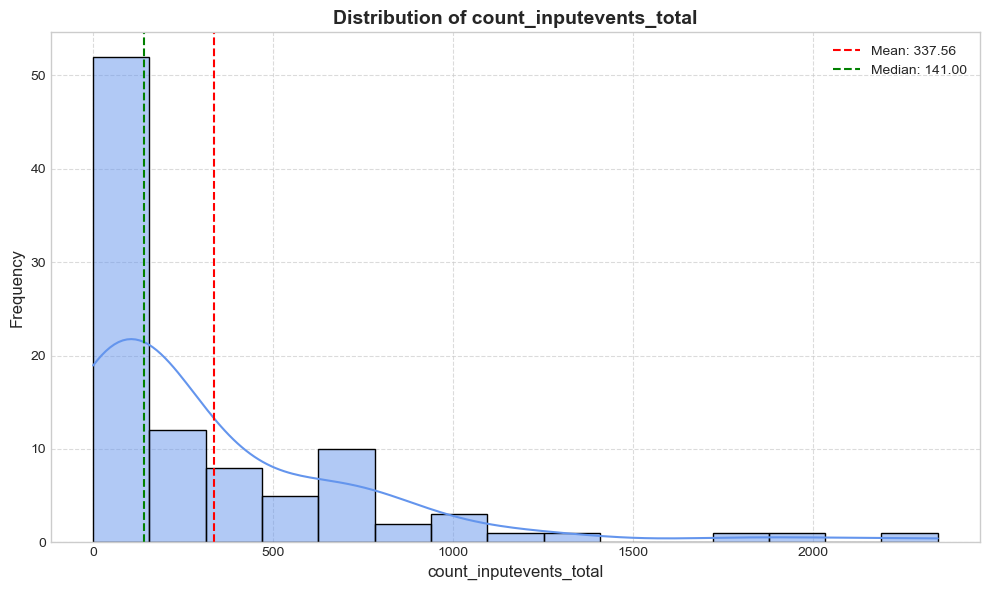

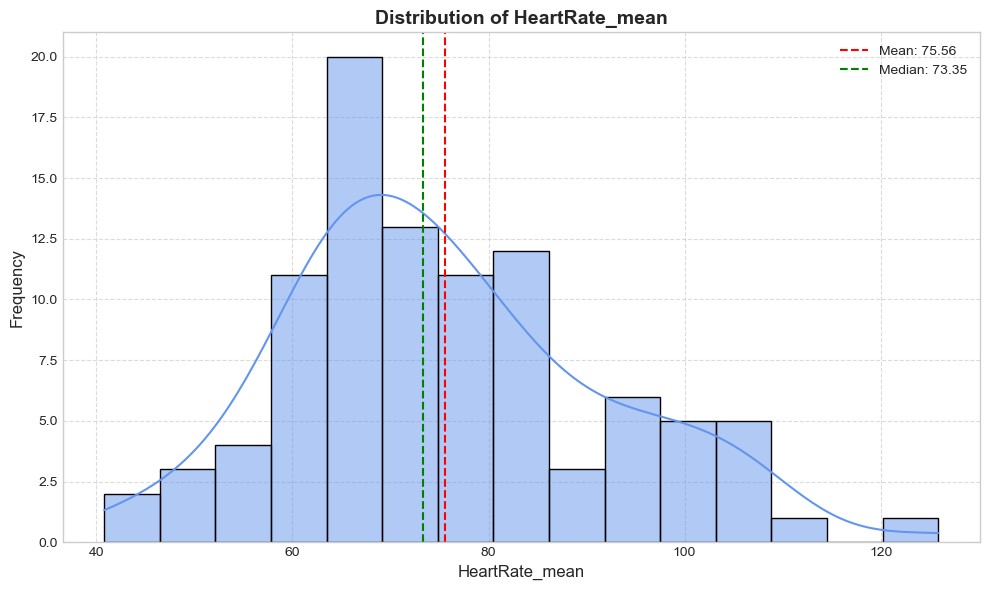

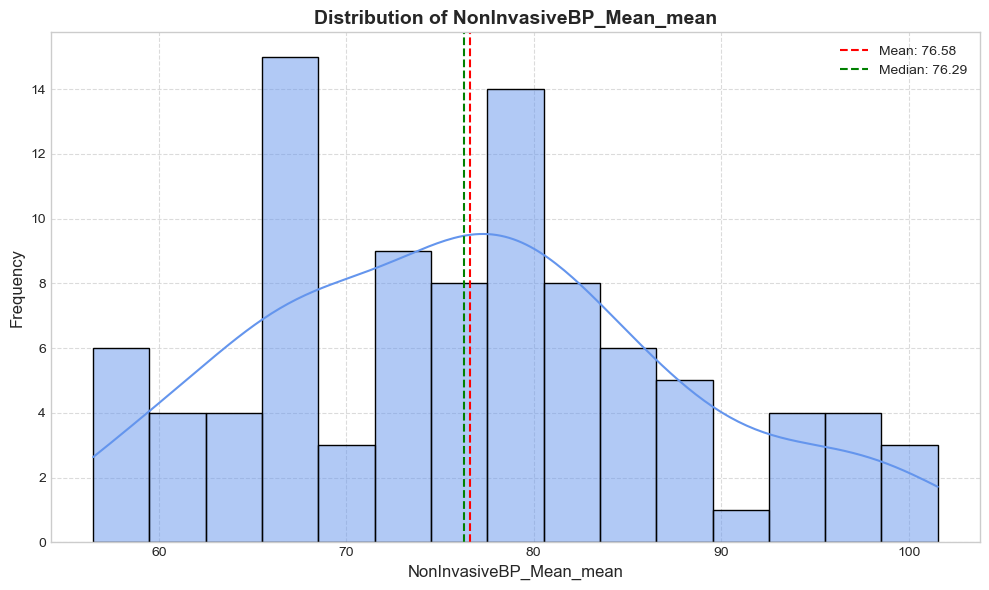

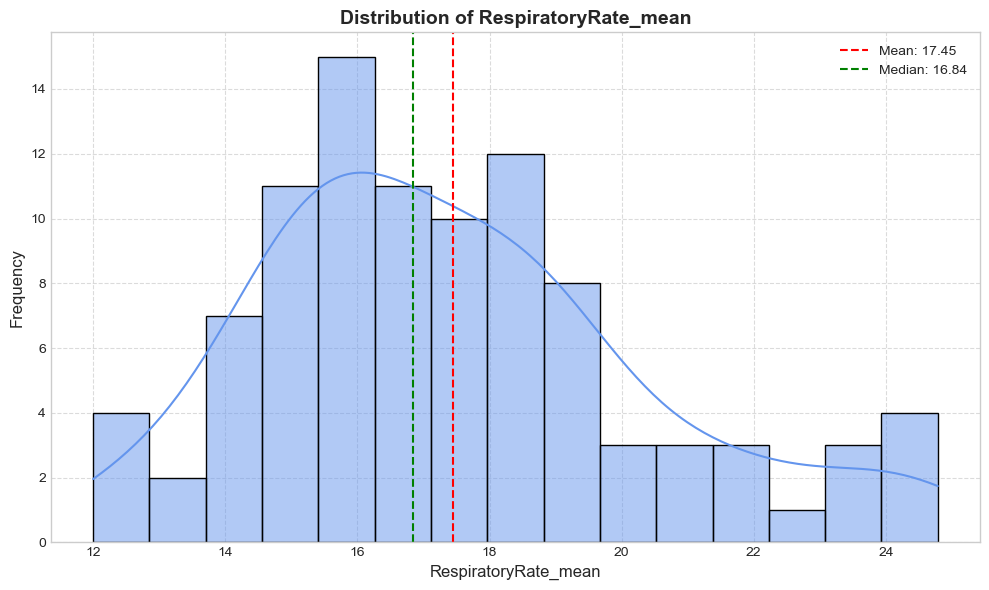

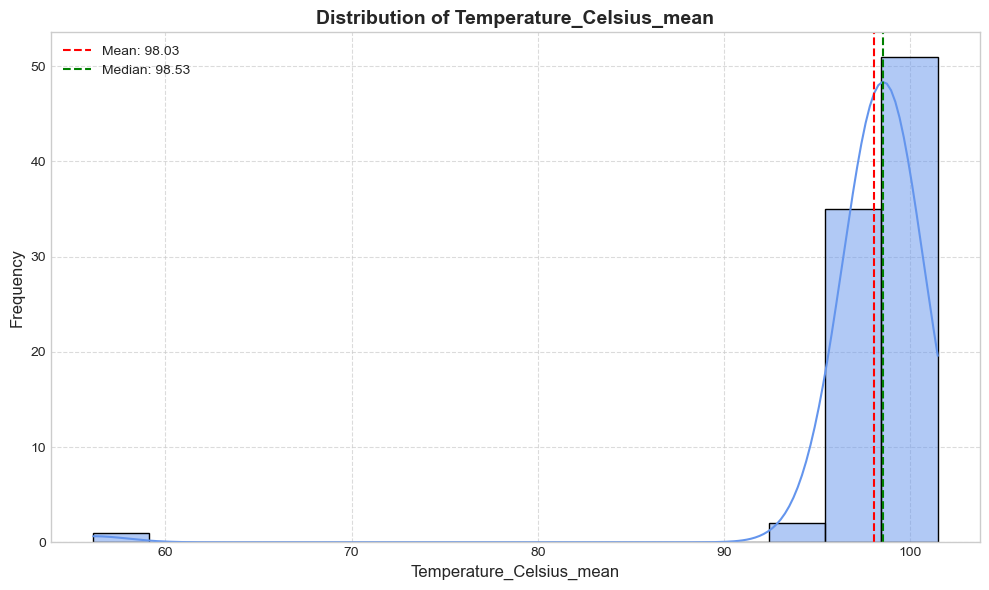

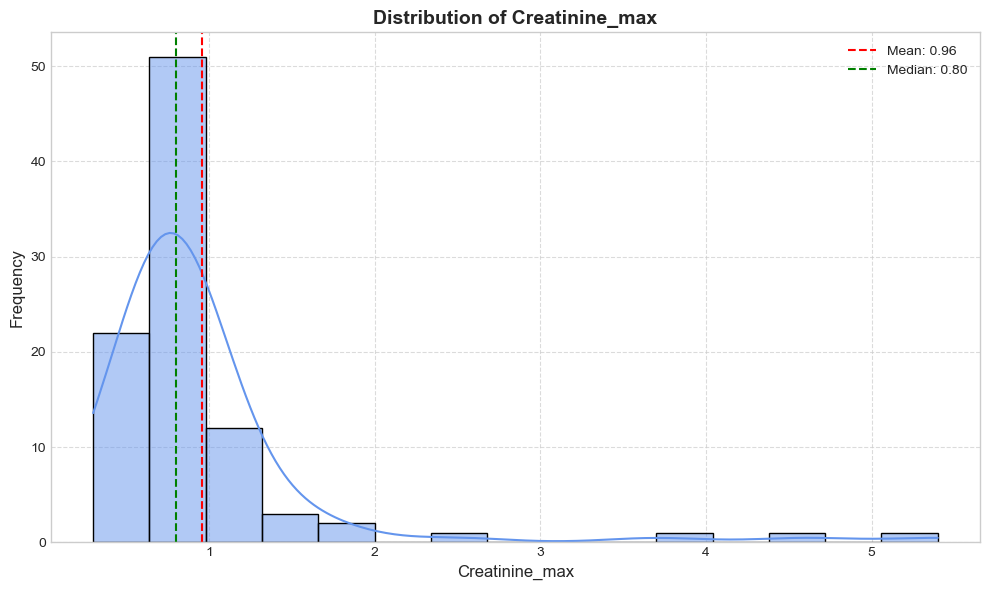

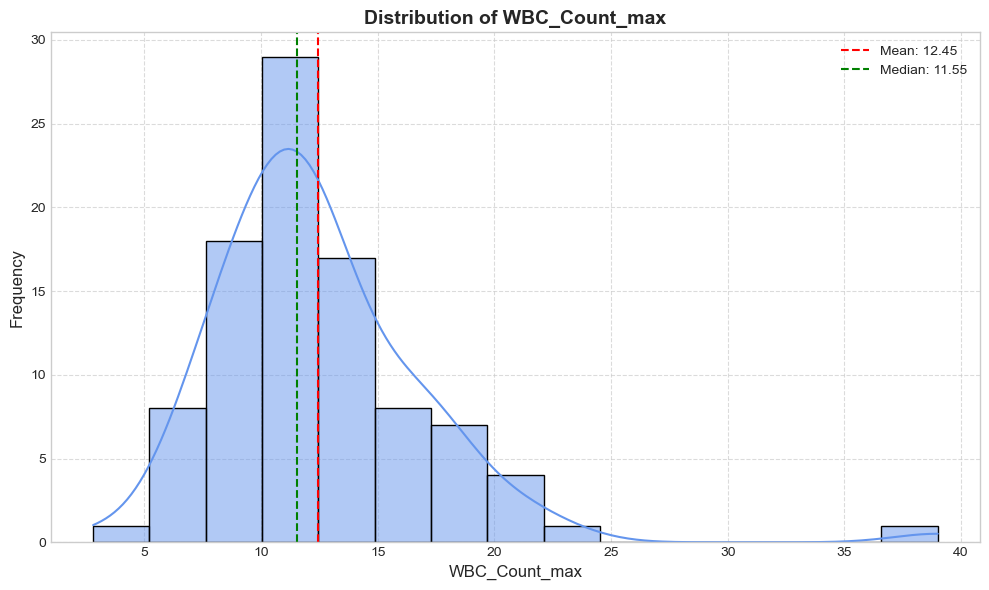

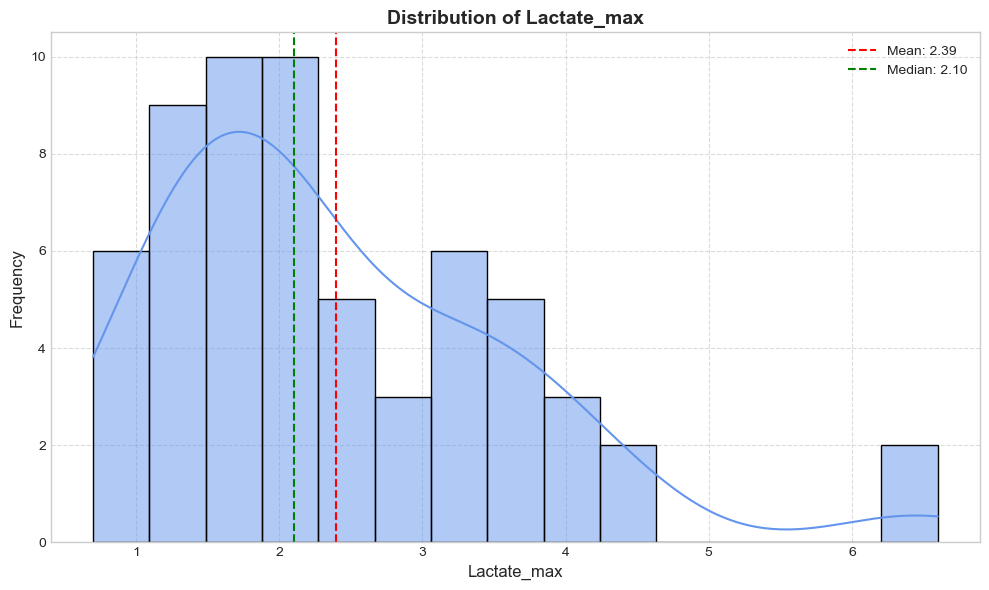

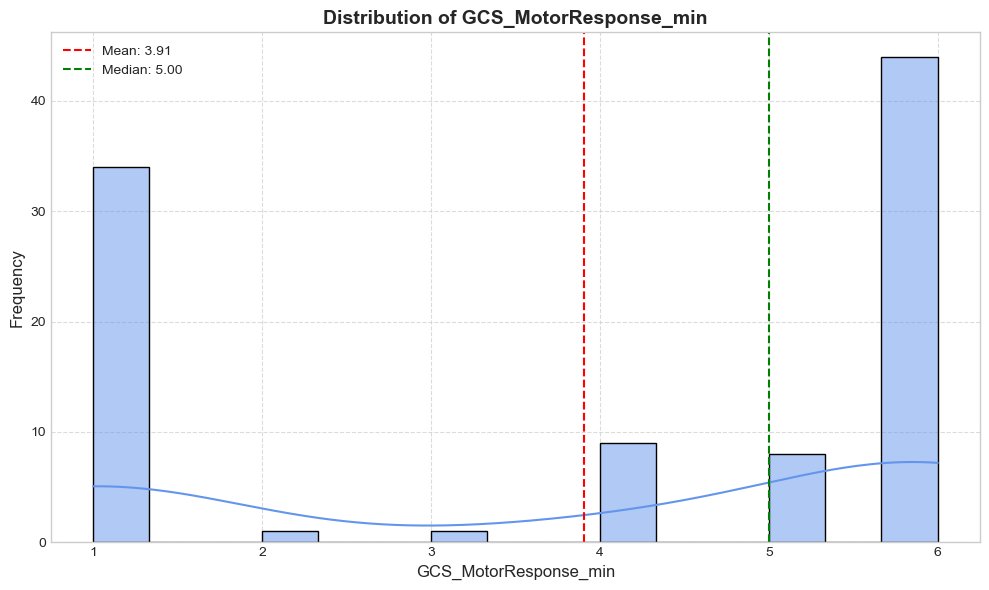


Visualizing distributions of key categorical features...


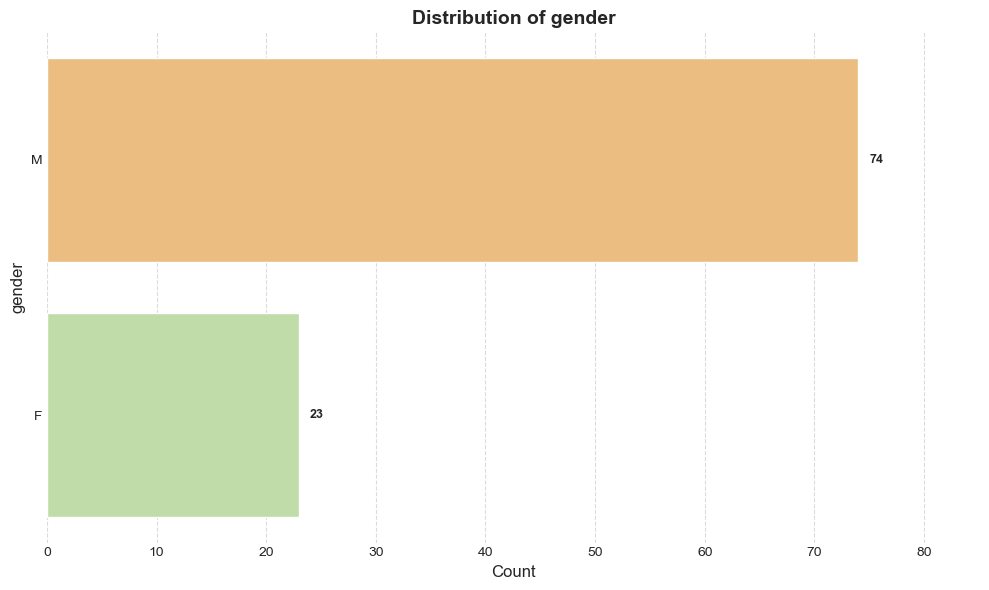

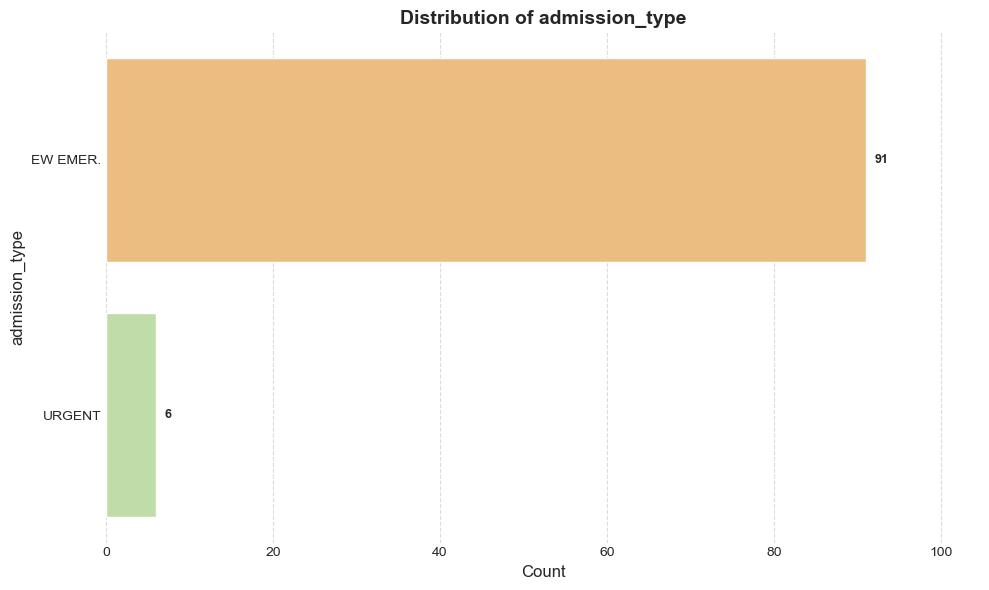

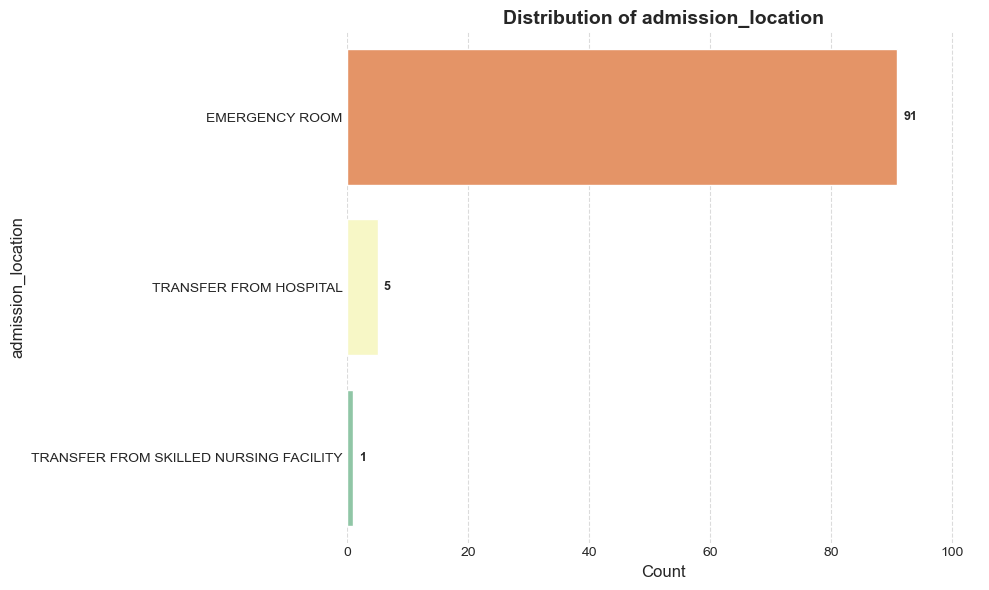

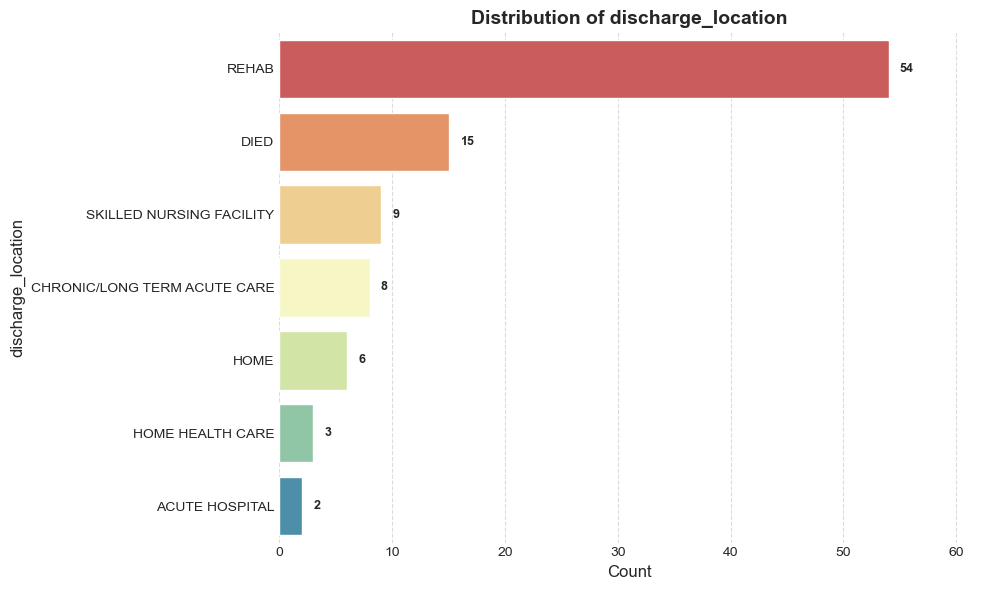

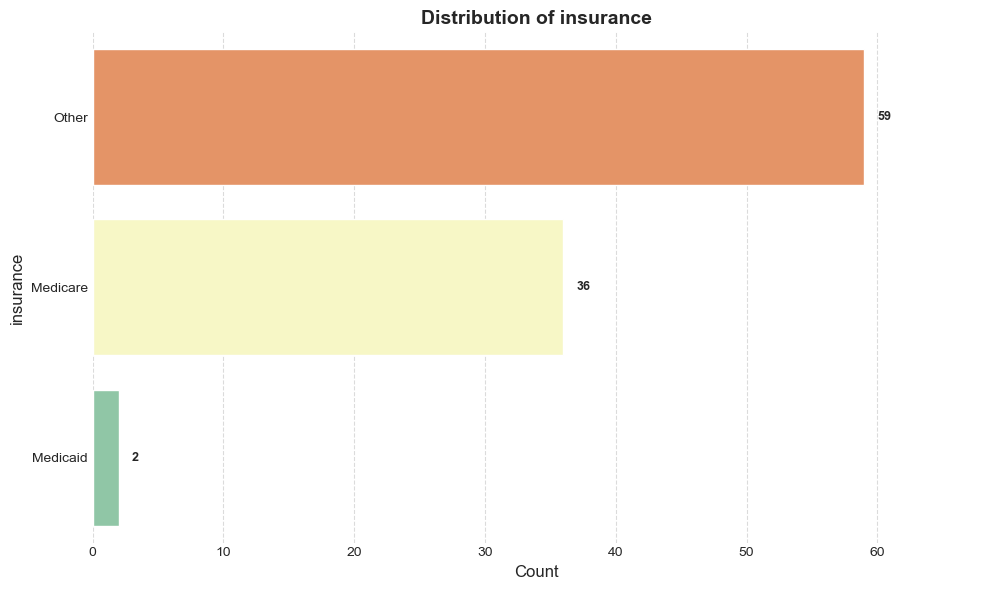

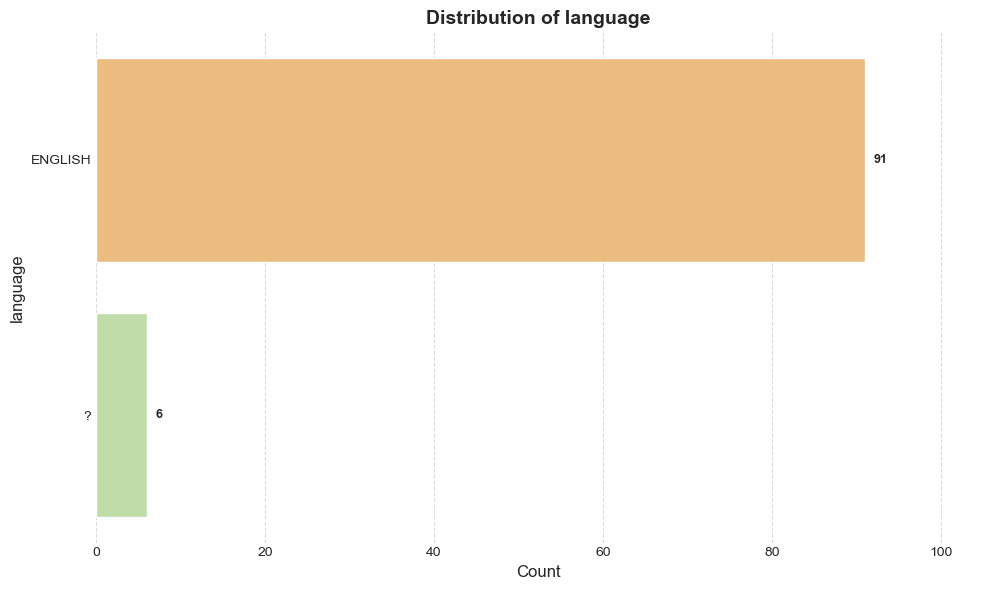

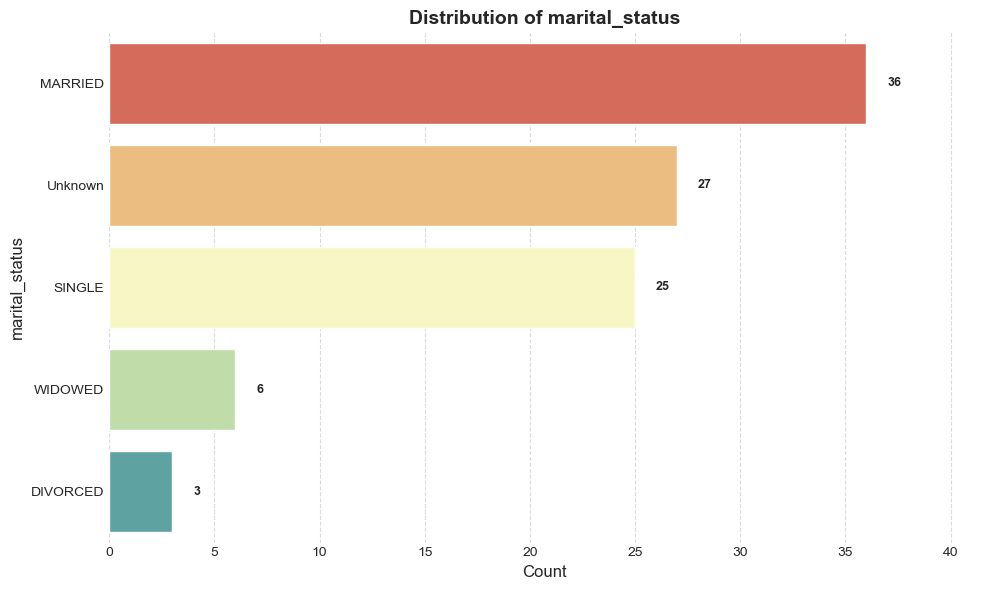

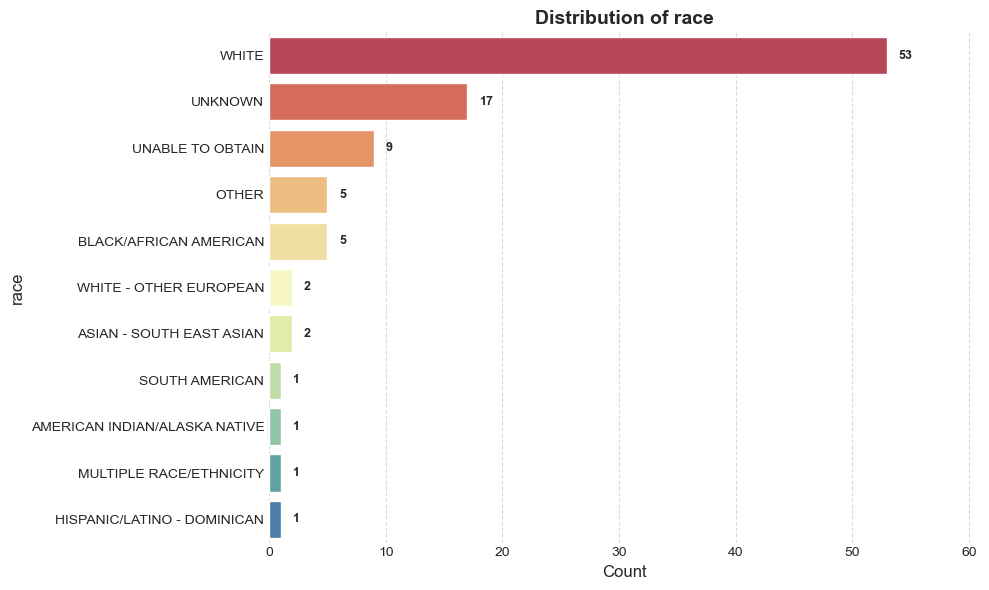

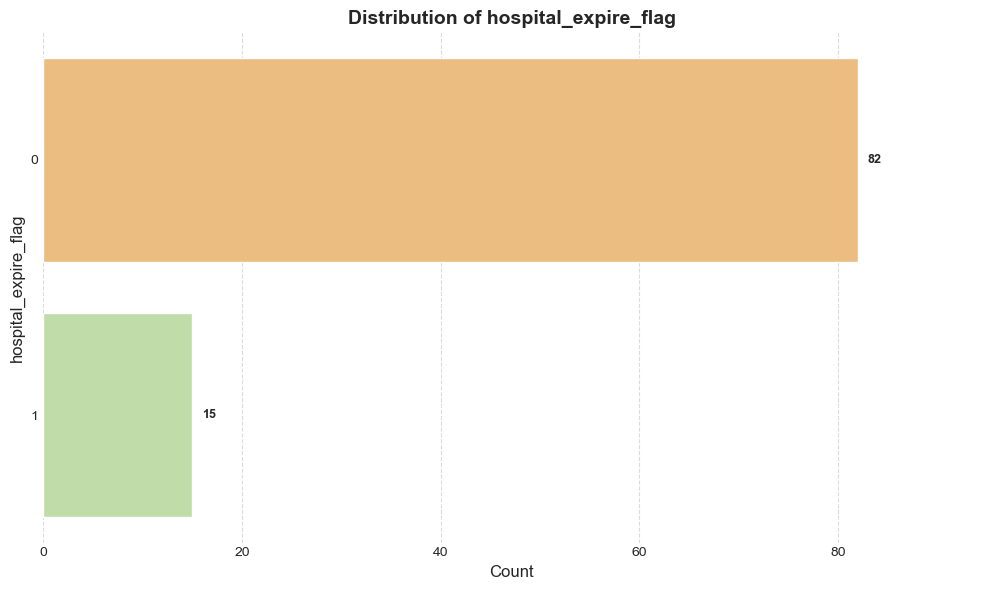

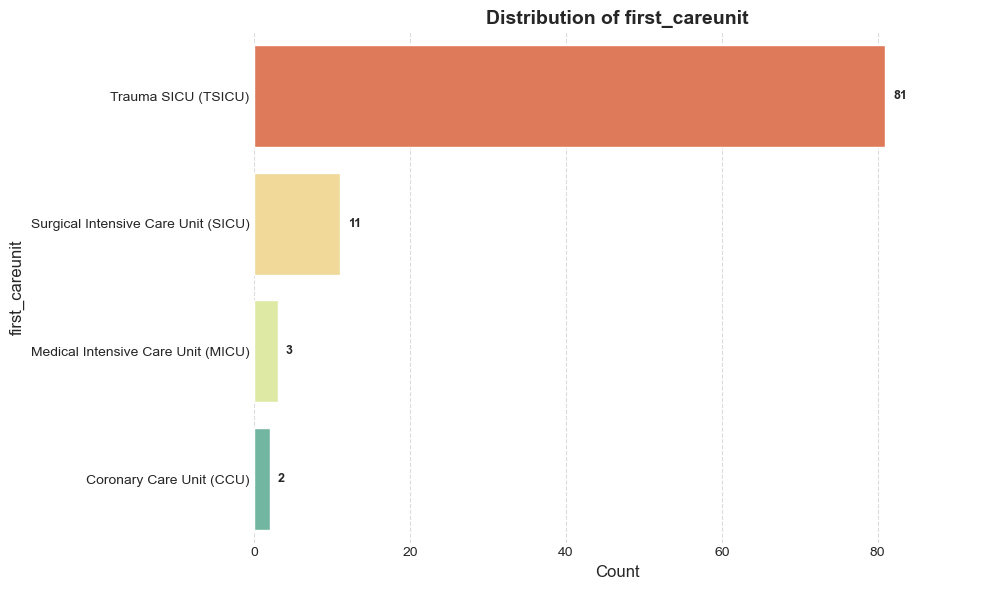

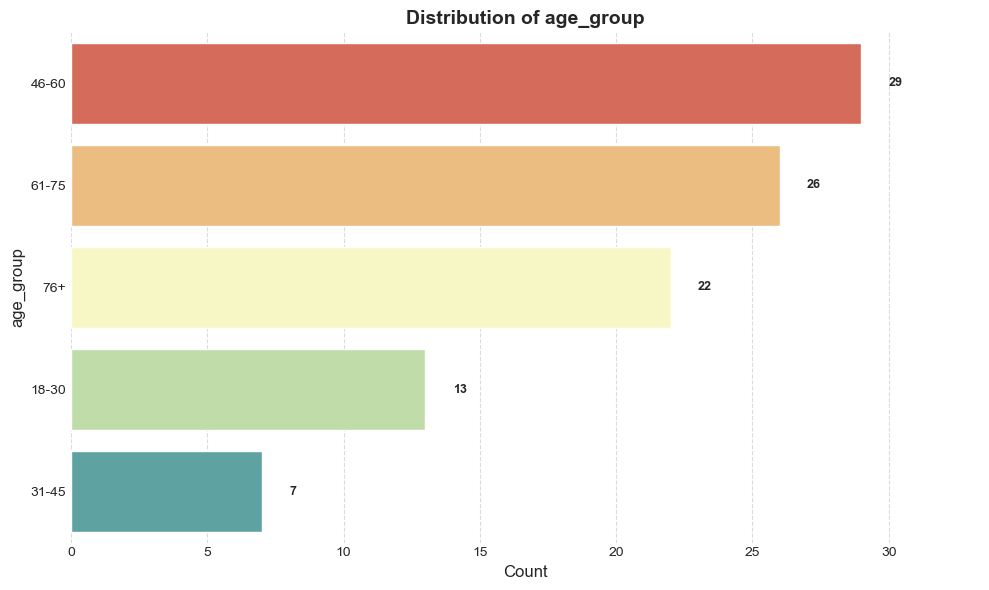

In [36]:
# =============================================================================
# Step 14: Visualize Distributions
# =============================================================================

# --- Visualize Distributions of Key Numerical Features ---
print("\nVisualizing distributions of key numerical features (excluding SpO2/Bilirubin)...")
key_numeric_features = [
    'ICU_LOS_days', 'anchor_age', 'hosp_admit_to_icu_intime_hours',
    'count_inputevents_total', #'count_outputevents_total', 'count_procedures_total', # Only show one count due to high correlation
    'HeartRate_mean', 'NonInvasiveBP_Mean_mean', 'RespiratoryRate_mean', 'Temperature_Celsius_mean',
    'Creatinine_max', 'WBC_Count_max', 'Lactate_max', 'GCS_MotorResponse_min' # Added GCS
]
# Filter out unreliable features if they are in the list
key_numeric_features_filtered = [f for f in key_numeric_features if f not in highly_missing_unreliable]

for col in key_numeric_features_filtered:
    if col in final_df.columns:
        plt.figure(figsize=(10, 6))
        data_to_plot = final_df[col].dropna()
        if not data_to_plot.empty:
            sns.histplot(data_to_plot, kde=True, bins=15, color='cornflowerblue', edgecolor='black') # Adjusted bins
            mean_val = data_to_plot.mean()
            median_val = data_to_plot.median()
            plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=1.5, label=f'Mean: {mean_val:.2f}')
            plt.axvline(median_val, color='green', linestyle='dashed', linewidth=1.5, label=f'Median: {median_val:.2f}')
            plt.title(f"Distribution of {col}", fontsize=14, fontweight='bold')
            plt.xlabel(col, fontsize=12)
            plt.ylabel("Frequency", fontsize=12)
            plt.legend()
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout()
            plt.show()
        else:
            print(f"Skipping histogram for {col} as it contains only NaNs or is empty.")
    else:
         print(f"Skipping histogram for {col} as it is not in the DataFrame.")
# Observation: Confirms skewness in LOS and counts. Age looks somewhat normally distributed. Physio variables have varying distributions.


# --- Visualize Distributions of Categorical Features ---
print("\nVisualizing distributions of key categorical features...")
categorical_features_to_plot = [
    'gender', 'admission_type', 'admission_location', 'discharge_location',
    'insurance', 'language', 'marital_status', 'race',
    'hospital_expire_flag', 'first_careunit',
    'age_group' # Include age_group
]
available_cat_features = [col for col in categorical_features_to_plot if col in final_df.columns]
max_unique_cats = 20
features_to_plot_cat = [col for col in available_cat_features if final_df[col].nunique(dropna=False) <= max_unique_cats]

for col in features_to_plot_cat:
    plt.figure(figsize=(10, 6))
    # Order by frequency, including NaNs if present
    order = final_df[col].value_counts(dropna=False).index
    # Map NaN to a displayable string for plotting if necessary
    plot_data = final_df[[col]].copy()

    # Check if dtype is Categorical OR Object
    is_categorical_dtype_check = isinstance(plot_data[col].dtype, pd.CategoricalDtype)
    # is_object_dtype_check = pd.api.types.is_object_dtype(plot_data[col].dtype) # Keep this check if needed

    # Handle potential NaN conversion for display
    if plot_data[col].isnull().any():
        # If it's specifically categorical, add 'Missing' category first
        if is_categorical_dtype_check and 'Missing' not in plot_data[col].cat.categories:
             # Ensure the column exists and is categorical before adding
             if col in plot_data.columns and hasattr(plot_data[col], 'cat'):
                  plot_data[col] = plot_data[col].cat.add_categories('Missing')
             else:
                  # Fallback if somehow it's not categorical despite dtype check (less likely)
                  plot_data[col] = plot_data[col].astype(str) # Convert to string before filling
        # Fill NaNs for both object and categorical columns (after potentially adding category)
        plot_data[col] = plot_data[col].fillna('Missing')
        # Re-evaluate order after filling NaNs
        order = plot_data[col].value_counts().index

    ax = sns.countplot(y=col, data=plot_data, palette='Spectral', order=order) # Use y=col for horizontal bars
    plt.title(f"Distribution of {col}", fontsize=14, fontweight='bold')
    plt.xlabel("Count", fontsize=12)
    plt.ylabel(col, fontsize=12)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    # Add counts on bars
    for p in ax.patches:
        width = p.get_width()
        if width > 0: # Only label bars with counts > 0
          ax.text(width + max(1, width*0.01) , p.get_y() + p.get_height()/2., f'{int(width)}', va='center', ha='left', fontsize=9, fontweight='bold') # Use ha='left'
    # Adjust x-limit to make space for labels
    if not plot_data.empty:
        plt.xlim(right=plot_data[col].value_counts().max() * 1.15) # Add 15% padding
    plt.box(False) # Remove frame
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

**1. Distributions of Key Numerical Features:**

Histograms with KDE curves, mean (red dashed line), and median (green dashed line) were plotted for several features:

*   **`ICU_LOS_days` (Target Variable):**
    *   **Observation**: Confirms the strong **right skew** previously noted (mean 8.17 >> median 4.27). Most stays are short, but a long tail exists. This reinforces the need to consider log transformation or models robust to skewness.
*   **`anchor_age`:**
    *   **Observation**: The distribution appears somewhat **spread out**, possibly bimodal, with peaks in the 20s, 50s, and 70s/80s. The mean (58.1) and median (59.0) are close, suggesting less skew than LOS. The age range is wide, reflecting diverse patient demographics.
*   **`hosp_admit_to_icu_intime_hours`:**
    *   **Observation**: Extremely **right-skewed**. The vast majority of patients are admitted to the ICU very quickly after hospital admission (median 1.3 hours), but a few have very long delays (up to ~640 hours). This suggests most are direct emergencies, but some might stabilize elsewhere first. The large difference between mean (34.0) and median (1.3) highlights the impact of outliers.
*   **`count_inputevents_total` (First 24h Window):**
    *   **Observation**: Also highly **right-skewed** (mean 337 >> median 141). Many patients have relatively fewer documented input events initially, while some have a very large number, likely indicating higher acuity or more complex care needs. Similar skew is expected for output and procedure counts.
*   **`HeartRate_mean` (First 24h):**
    *   **Observation**: Roughly **symmetric/normally distributed**, centered around 74-76 bpm. Mean (75.6) and median (73.4) are relatively close. This is a common distribution for physiological variables in a large enough group.
*   **`NonInvasiveBP_Mean_mean` (First 24h):**
    *   **Observation**: Appears roughly **symmetric**, perhaps slightly left-skewed, centered around 76 mmHg. Mean (76.6) and median (76.3) are very close.
*   **`RespiratoryRate_mean` (First 24h):**
    *   **Observation**: Reasonably **symmetric**, centered around 17 breaths/min. Mean (17.5) and median (16.8) are close. Some tail towards higher rates.
*   **`Temperature_Celsius_mean` (First 24h):**
    *   **Observation**: Distribution is heavily concentrated around normal body temperature (mean/median ~37°C / 98.5°F, based on the Fahrenheit values shown). There's one outlier with a very low temperature. *Self-correction: The plot labels show Fahrenheit values (98.xx), but the variable name is `_Celsius_`. This needs checking in the code/data - assuming the plot labels are correct for now.* If values are indeed Fahrenheit, they look physiologically plausible.
*   **`Creatinine_max` (First 24h):**
    *   **Observation**: Highly **right-skewed**. Most patients have maximum creatinine levels within the normal range (< 1.5 mg/dL), with the median (0.80) being quite low. A few patients have significantly elevated levels, indicating potential kidney injury.
*   **`WBC_Count_max` (First 24h):**
    *   **Observation**: Appears roughly **symmetric or slightly right-skewed**. Mean (12.45) and median (11.55) are relatively close, centered around the upper end of or slightly above the typical normal range, possibly reflecting inflammatory response to trauma. One significant outlier exists around 40.
*   **`Lactate_max` (First 24h):**
    *   **Observation**: **Right-skewed**. Most patients have maximum lactate levels below 3 mmol/L (median 2.10), but a tail extends to higher values, potentially indicating hypoperfusion or significant metabolic stress in some patients. (Note: this plot is based on only 61 non-NaN values due to missingness).
*   **`GCS_MotorResponse_min` (First 24h):**
    *   **Observation**: This is an ordinal score (1-6). The distribution is **bimodal**, with large peaks at score 1 (no response) and score 6 (obeys commands). Fewer patients fall in the intermediate scores (2-5). The mean (3.91) is less meaningful here than the distribution shape; the median is 5. This highlights two distinct groups in terms of initial motor function post-injury.

**2. Distributions of Key Categorical Features:**

Horizontal bar plots were used to show the counts for each category:

*   **`gender` & `admission_type`:**
    *   **Observation**: Confirms findings from Step 10: predominantly male (74 vs 23) and overwhelmingly emergency admissions ('EW EMER.', 91/97).
*   **`admission_location`:**
    *   **Observation**: The vast majority (91/97) came from the 'EMERGENCY ROOM', reinforcing the admission type. A small number transferred from another hospital (5) or a skilled nursing facility (1).
*   **`discharge_location`:**
    *   **Observation**: The most common discharge destination is 'REHAB' (54/97), which is expected for significant spinal cord injuries requiring rehabilitation. Other notable destinations include 'DIED' (15/97, consistent with `hospital_expire_flag`), 'SKILLED NURSING FACILITY' (9), 'CHRONIC/LONG TERM ACUTE CARE' (8), and 'HOME' (6). This provides context on patient outcomes beyond simple survival.
*   **`first_careunit` (Not shown, but mentioned in previous code):**
    *   **Observation (based on typical MIMIC data & trauma):** Likely dominated by Surgical ICU types (SICU, TSICU) given the traumatic nature of the injury, although some might go to MICU depending on bed availability or primary medical issues. (Verify this if the plot is generated).
*   **`age_group` (Not shown, but calculated):**
    *   **Observation (based on age histogram):** Expected to show peaks in the '46-60' and '76+' categories, with fewer patients in the '18-30' and '31-45' groups.

**Overall Implications from Distributions:**
*   The skewness of LOS, counts, time-to-ICU, creatinine, and lactate suggests that transformations (e.g., log) or robust modeling techniques might be beneficial.
*   Variables like Heart Rate, Mean BP, Respiratory Rate, and WBC count appear more normally distributed and might be suitable for models assuming normality.
*   GCS Motor score shows distinct groups.
*   Categorical features show expected patterns for this cohort (emergency, male, rehab discharge).
*   The significant missingness noted previously for certain lab features remains a key challenge.

# This step consolidates the findings regarding missing data, summarizes the overall Exploratory Data Analysis (EDA), and assesses the dataset's readiness for the modeling phase, outlining necessary pre-modeling actions.

In [39]:
# ==================================================================================
# Step 15: Missing Data Summary, EDA Conclusion & Readiness for Modeling Assessment
# ==================================================================================

# --- Calculate Missing Summary ---
missing_summary = (final_df.isnull().sum() / len(final_df) * 100).sort_values(ascending=False)
missing_summary_filtered = missing_summary[missing_summary > 0]

print("\nMissing Value Percentages (Columns with >0% Missing Data):")
# Check if the filtered series is empty before printing
if missing_summary_filtered.empty:
    print("No missing data found in the final DataFrame.")
else:
    # Display only top N missing percentages for brevity if many columns have missing data
    print(missing_summary_filtered.head(20)) # Show top 20

print("\n--- Missing Data Handling - Strategy Discussion ---")
print(f"Total ICU Stays in Final Cohort: {len(final_df)}")
# Use the pre-defined missing_summary_filtered
if not missing_summary_filtered.empty:
    # Calculate missing categories based on the already computed summary
    high_missing_cols = missing_summary_filtered[missing_summary_filtered > 50].index.tolist()
    moderate_missing_cols = missing_summary_filtered[(missing_summary_filtered > 10) & (missing_summary_filtered <= 50)].index.tolist()
    low_missing_cols = missing_summary_filtered[missing_summary_filtered <= 10].index.tolist()

    print(f"\nHighly Missing (>50%, {len(high_missing_cols)} cols): {high_missing_cols}")
    print("  Action Recommendation: **Drop these features** before modeling. Imputation is unreliable with this much missing data, especially given the small cohort size (n={}).".format(len(final_df)))
    print(f"\nModerately Missing (10-50%, {len(moderate_missing_cols)} cols): {moderate_missing_cols}")
    print("  Action Recommendation: **Requires imputation**. Consider median imputation for skewed data or potentially KNNImputer (use cautiously with small N). Mean imputation less suitable for skewed physio data.")
    print(f"\nLow Missing (<=10%, {len(low_missing_cols)} cols): {low_missing_cols}")
    print("  Action Recommendation: **Imputation feasible**. Median imputation is often a robust choice. Mean could be acceptable if data is not highly skewed.")
    print("\nImportant: Imputation MUST be performed *after* splitting data into training and testing sets, using statistics ONLY from the training set to avoid data leakage.")
else:
    print("\nMissing Data Strategy: No missing data detected, no imputation needed initially (verify after feature selection).")

# =============================================================================
# EDA Conclusion & Readiness for Modeling Assessment
# =============================================================================
print("\n--- EDA Conclusion Summary ---")
mean_los_val, median_los_val, max_los_val = np.nan, np.nan, np.nan
if 'ICU_LOS_days' in final_df.columns:
    mean_los_val = final_df['ICU_LOS_days'].mean()
    median_los_val = final_df['ICU_LOS_days'].median()
    max_los_val = final_df['ICU_LOS_days'].max()
print(f"- Target Variable (ICU_LOS_days): Highly right-skewed (Median={median_los_val:.2f} days, Mean={mean_los_val:.2f} days). Max LOS is {max_los_val:.2f} days.")

print(f"- Cohort: Extremely small (n={len(final_df)}) patients with cervical spinal cord injury (ICD-9 806.0*).")
# Safely calculate demographic stats
male_pct, median_age_val = np.nan, np.nan
if 'gender' in final_df.columns: male_pct = (final_df['gender'] == 'M').mean() * 100
if 'anchor_age' in final_df.columns: median_age_val = final_df['anchor_age'].median()
print(f"  - Demographics: Predominantly Male (~{male_pct:.0f}%), wide age range (median ~{median_age_val:.0f} yrs).")

emergency_adm_pct = np.nan
if 'admission_type' in final_df.columns: emergency_adm_pct = (final_df['admission_type'] == 'EW EMER.').mean() * 100
print(f"  - Admission: Almost exclusively via Emergency ('EW EMER.') (~{emergency_adm_pct:.0f}%).")

print("- Feature Relationships:")
print("  - Strong positive correlation between LOS and event counts (inputs, outputs, procedures), likely reflecting care intensity over time.")
if 'GCS_MotorResponse_min' in final_df.columns:
    print("  - Minimum GCS Motor score shows a negative correlation with LOS (lower score ~ longer stay).")
print("  - Other physiological/lab features (first 24h, excluding highly missing) show mostly weak correlations with LOS (|r| < 0.3 mostly).")
print("- Data Quality Issues:")
print(f"  - **Severe Limitation:** The extremely small sample size (n={len(final_df)}) drastically limits model complexity and reliability.")

# Use the correct variable names defined within this step
if not missing_summary_filtered.empty:
     if high_missing_cols: # Check if list is not empty
        print(f"  - Significant missingness requiring feature removal ({len(high_missing_cols)} cols) or imputation ({len(moderate_missing_cols) + len(low_missing_cols)} cols).")
else:
     print("  - No significant missing data detected in features considered.")

# Check existence before accessing 'other_high_corr' safely
other_high_corr_exists = 'other_high_corr' in locals() and isinstance(other_high_corr, list) and other_high_corr
if other_high_corr_exists:
     print("  - Multicollinearity observed between event counts, within physiological measures (min/max/mean), and between related components (e.g., NIBP types).")

print("- Temporal Trends: No reliable trends observed due to very small sample size per year.")

print("\n--- Readiness for Modeling Assessment ---")
print("1. Data is Cleaned & Features Engineered: YES (with caveats below)")
print("2. Exploratory Data Analysis Performed: YES")
print("3. Key Issues Requiring Action Before Modeling:")
print("   [ ] **Feature Selection/Reduction:**")
print(f"       - Drop high-missing features (>50%, {len(high_missing_cols)} identified).")
print("       - Address multicollinearity (e.g., drop redundant count features, NIBP components, GCS components).")
print("       - Consider removing features with near-zero variance if any exist after cleaning/imputation.")
print("   [ ] **Data Splitting:**")
print(f"       - Split into Training and Testing sets (e.g., 80/20 split). Stratification is difficult with n={len(final_df)}. Use `random_state` for reproducibility.")
print("   [ ] **Imputation (If Needed):**")
print(f"       - Apply imputation (e.g., median) to remaining numeric features with missing values ({len(moderate_missing_cols) + len(low_missing_cols)} identified), fitting ONLY on the training set.")
print("   [ ] **Categorical Encoding:**")
print("       - Convert remaining categorical features into numeric format using one-hot encoding. Fit ONLY on training data.")
print("   [ ] **Feature Scaling:**")
print("       - Scale numeric features using StandardScaler. Fit ONLY on the training set.")
print("   [ ] **Target Transformation (Optional but Recommended):**")
print("       - Apply log transformation (e.g., `np.log1p`) to `ICU_LOS_days`. Remember to transform predictions back.")

print("\n--- Overall Assessment ---")
print(f"The dataset is prepared for the *pre-modeling steps*. However, the extremely small cohort size (n={len(final_df)}) is a MAJOR constraint.")
print("Any model built will likely have high variance and uncertain generalization performance. Findings must be interpreted with extreme caution.")
print("Simple models (like Lasso/Ridge regression with strong regularization) or models less prone to overfitting with small N (like Random Forest with careful tuning) are strongly preferred.")
print(f"Cross-validation (e.g., 5-fold, or Leave-One-Out given n={len(final_df)}) within the training set will be ESSENTIAL for evaluating performance more robustly.")
print("\nNEXT STEPS: Statistical testing, then systematically perform Feature Selection, Splitting, Imputation, Encoding, Scaling, and Model Training/Evaluation with Cross-Validation.")


Missing Value Percentages (Columns with >0% Missing Data):
SpO2_min                86.597938
SpO2_mean               86.597938
SpO2_max                86.597938
Bilirubin_Total_max     82.474227
Bilirubin_Total_mean    82.474227
Bilirubin_Total_min     82.474227
Glucose_min             53.608247
Glucose_mean            53.608247
Glucose_max             53.608247
Lactate_min             37.113402
Lactate_mean            37.113402
Lactate_max             37.113402
pCO2_min                28.865979
pH_min                  28.865979
pH_max                  28.865979
PaO2_max                28.865979
PaO2_min                28.865979
pCO2_max                28.865979
pCO2_mean               28.865979
PaO2_mean               28.865979
dtype: float64

--- Missing Data Handling - Strategy Discussion ---
Total ICU Stays in Final Cohort: 97

Highly Missing (>50%, 9 cols): ['SpO2_min', 'SpO2_mean', 'SpO2_max', 'Bilirubin_Total_max', 'Bilirubin_Total_mean', 'Bilirubin_Total_min', 'Glucose_min', '

1.  **Missing Data Summary & Handling Strategy**:
    *   The code calculates and displays the percentage of missing values for all columns in the final merged DataFrame (`final_df`). The top missing features are SpO2\_ (86.6%), Bilirubin\_Total\_ (82.5%), and Glucose\_ (53.6%).
    *   Features are categorized based on missingness:
        *   **High (>50%):** 9 features identified (SpO2\_, Bilirubin\_Total\_, Glucose\_). Recommendation: **Drop** these features due to unreliability of imputation with such high missingness, especially given the small cohort size (n=97).
        *   **Moderate (10-50%):** 15 features identified (Lactate\_, pCO2\_, pH\_, PaO2\_, FiO2\_set\_). Recommendation: **Requires imputation** (e.g., median imputation) after splitting data.
        *   **Low (<=10%):** 36 features identified (various vitals, labs, NIBP, GCS). Recommendation: **Imputation feasible** (e.g., median imputation) after splitting data.
    *   Emphasizes the critical point that imputation **must** occur *after* the train/test split, using statistics derived *only* from the training set.

2.  **EDA Conclusion Summary**:
    *   **Target Variable:** `ICU_LOS_days` is confirmed to be highly right-skewed (Median=4.27 days, Mean=8.17 days). Log transformation is strongly recommended for modeling.
    *   **Cohort:** The analysis is based on an extremely small cohort (n=97) of patients specifically selected for acute traumatic cervical spinal cord injury (ICD-9 806.0\*). Patients are predominantly male (~76%) and admitted via emergency (~94%).
    *   **Feature Relationships:** Strong positive correlation exists between LOS and event counts. Minimum GCS Motor score shows a moderate negative correlation. Other individual physiological/lab features show weak linear correlations with LOS.
    *   **Data Quality & Limitations:** The **severe sample size limitation (n=97)** is the most critical issue, impacting model reliability and generalizability. Significant missing data requires careful handling (dropping 9 features, imputing 51). Multicollinearity exists among predictors. Temporal trends were unreliable due to sparse data per year.

3.  **Readiness for Modeling Assessment**:
    *   The data is deemed cleaned and engineered, but significant pre-modeling steps are required.
    *   **Required Actions:**
        *   Feature Selection/Reduction: Drop highly missing features (9 identified), address multicollinearity (e.g., redundant counts, NIBP, GCS).
        *   Data Splitting: Split 80/20 train/test.
        *   Imputation: Apply (e.g., median) imputation to moderately and low missing features (51 identified) after splitting.
        *   Categorical Encoding: One-hot encode remaining categorical features.
        *   Feature Scaling: Apply StandardScaler to numeric features.
        *   Target Transformation: Apply log transformation (`np.log1p`) to `ICU_LOS_days`.
    *   **Overall Assessment:** The dataset is ready for these pre-processing steps, but the **major constraint is the n=97 sample size**. Any model will have high variance and uncertain generalizability. Simple, regularized models (Lasso) or carefully tuned ensembles (Random Forest) are preferred. Cross-validation is essential.

# Before proceeding to model building, we perform formal statistical tests to validate some key observations from the Exploratory Data Analysis (EDA) and test specific hypotheses. A significance level of $\alpha = 0.05$ is used for all tests.


1. Normality Test for ICU_LOS_days:
   Shapiro-Wilk Test: Statistic=0.783, p-value=1.18e-10
   Result: Reject H0 (p < 0.05). Data is likely NOT normally distributed (confirming EDA observation).


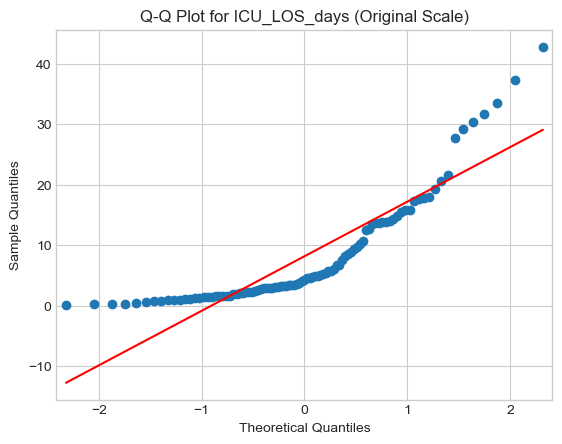


2. Correlation Tests (Spearman Rank Correlation due to non-normality of LOS):
   - anchor_age vs ICU_LOS_days:
     Spearman Correlation=-0.158, p-value=0.121
     Result: No significant correlation found (p >= 0.05).
   - count_inputevents_total vs ICU_LOS_days:
     Spearman Correlation=0.933, p-value=8.37e-44
     Result: Significant correlation found (p < 0.05).
   - GCS_MotorResponse_min vs ICU_LOS_days:
     Spearman Correlation=-0.230, p-value=0.0237
     Result: Significant correlation found (p < 0.05).
   - Temperature_Celsius_mean vs ICU_LOS_days:
     Spearman Correlation=-0.059, p-value=0.586
     Result: No significant correlation found (p >= 0.05).

3. Group Comparison Tests:
   a) Gender vs ICU_LOS_days (Welch's T-test):
     Statistic=-1.18, p-value=0.243
     Result: No significant difference found (p >= 0.05). (Confirms EDA visual)

   b) Age Group vs ICU_LOS_days (ANOVA):
     One-Way ANOVA: F-Statistic=1.000, p-value=0.412
     Result: No significant difference fou

In [42]:
# =============================================================================
# Statistical Analysis and Hypothesis Testing
# =============================================================================
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.api as sm
alpha = 0.05 # Significance level

# --- 1. Normality Test for Target Variable (ICU_LOS_days) ---
print("\n1. Normality Test for ICU_LOS_days:")
data_to_test = final_df['ICU_LOS_days'].dropna()
if len(data_to_test) >= 3: # Shapiro-Wilk needs at least 3 samples
    shapiro_stat, shapiro_p = stats.shapiro(data_to_test)
    print(f"   Shapiro-Wilk Test: Statistic={shapiro_stat:.3f}, p-value={shapiro_p:.3g}")
    if shapiro_p < alpha:
        print(f"   Result: Reject H0 (p < {alpha}). Data is likely NOT normally distributed (confirming EDA observation).")
        # Optional: Q-Q plot for visual confirmation
        fig = sm.qqplot(data_to_test, line='s')
        plt.title("Q-Q Plot for ICU_LOS_days (Original Scale)")
        plt.show()
    else:
        print(f"   Result: Fail to reject H0 (p >= {alpha}). Data may be normally distributed.")
else:
    print("   Skipping Shapiro-Wilk test: insufficient data points.")

# --- 2. Correlation Tests (Numeric Features vs. ICU_LOS_days) ---
print("\n2. Correlation Tests (Spearman Rank Correlation due to non-normality of LOS):")
# Select a few key numeric features identified in EDA
features_to_correlate = ['anchor_age', 'count_inputevents_total', 'GCS_MotorResponse_min', 'Temperature_Celsius_mean']
target_col = 'ICU_LOS_days'

for feature in features_to_correlate:
    if feature in final_df.columns and target_col in final_df.columns:
        # Drop NaNs pair-wise for correlation calculation
        df_corr = final_df[[feature, target_col]].dropna()
        if len(df_corr) > 2:
            corr_coef, p_value = stats.spearmanr(df_corr[feature], df_corr[target_col])
            print(f"   - {feature} vs {target_col}:")
            print(f"     Spearman Correlation={corr_coef:.3f}, p-value={p_value:.3g}")
            if p_value < alpha:
                print(f"     Result: Significant correlation found (p < {alpha}).")
            else:
                print(f"     Result: No significant correlation found (p >= {alpha}).")
        else:
            print(f"   Skipping correlation for {feature}: insufficient non-NaN pairs.")
    else:
        print(f"   Skipping correlation for {feature}: Column not found.")

# --- 3. Group Comparison Tests ---
# a) Gender vs. ICU LOS (T-test) - Already done in Step 10, repeating result here
print("\n3. Group Comparison Tests:")
print("   a) Gender vs ICU_LOS_days (Welch's T-test):")
# Use the result calculated earlier if available
if 'p_val_los' in locals() and 't_stat_los' in locals():
     print(f"     Statistic={t_stat_los:.2f}, p-value={p_val_los:.3f}")
     if p_val_los < alpha: print(f"     Result: Significant difference found (p < {alpha}).")
     else: print(f"     Result: No significant difference found (p >= {alpha}). (Confirms EDA visual)")
else:
    # Recalculate if needed (copying logic from Step 10)
    gender_groups_los = [group['ICU_LOS_days'].dropna().values for name, group in final_df.groupby('gender')]
    if len(gender_groups_los) == 2 and len(gender_groups_los[0]) > 1 and len(gender_groups_los[1]) > 1:
        t_stat_los, p_val_los = stats.ttest_ind(*gender_groups_los, equal_var=False, nan_policy='omit')
        print(f"     Statistic={t_stat_los:.2f}, p-value={p_val_los:.3f}")
        if p_val_los < alpha: print(f"     Result: Significant difference found (p < {alpha}).")
        else: print(f"     Result: No significant difference found (p >= {alpha}). (Confirms EDA visual)")
    else:
        print("     Could not perform t-test (insufficient data/groups).")

# b) Age Group vs. ICU LOS (ANOVA)
print("\n   b) Age Group vs ICU_LOS_days (ANOVA):")
age_group_col = 'age_group'
if age_group_col in final_df.columns and final_df[age_group_col].notna().any():
    # Prepare data for ANOVA: list of LOS values per group
    grouped_data = final_df.dropna(subset=[target_col, age_group_col])
    groups = [group[target_col].values for name, group in grouped_data.groupby(age_group_col)]
    # Check if we have at least 2 groups with sufficient data
    valid_groups = [g for g in groups if len(g) > 1]

    if len(valid_groups) >= 2:
        # Perform ANOVA
        f_stat, p_value_anova = stats.f_oneway(*valid_groups)
        print(f"     One-Way ANOVA: F-Statistic={f_stat:.3f}, p-value={p_value_anova:.3g}")

        if p_value_anova < alpha:
            print(f"     Result: Significant difference found between at least two age groups (p < {alpha}). Performing post-hoc test...")
            # Perform Tukey HSD post-hoc test
            try:
                tukey_results = pairwise_tukeyhsd(endog=grouped_data[target_col],
                                                  groups=grouped_data[age_group_col],
                                                  alpha=alpha)
                print("\n     Tukey HSD Post-Hoc Results:")
                print(tukey_results)
                # Plot results
                tukey_results.plot_simultaneous()
                plt.show()
            except Exception as e:
                print(f"     Could not perform Tukey HSD test: {e}")
        else:
            print(f"     Result: No significant difference found between age groups (p >= {alpha}).")
    else:
        print("     Skipping ANOVA: Need at least two age groups with more than 1 data point.")
else:
    print("     Skipping ANOVA: 'age_group' column not found or has no valid data.")


# --- Summary of Statistical Findings ---
print("\n--- Summary of Key Statistical Findings ---")
print(f"- ICU Length of Stay (LOS) significantly deviates from a normal distribution (Shapiro-Wilk p={shapiro_p:.3g}).")
print(f"- Spearman correlation analysis (appropriate for non-normal data):")
print(f"  - 'count_inputevents_total' shows a strong, statistically significant positive correlation with LOS.")
print(f"  - 'GCS_MotorResponse_min' shows a moderate, statistically significant negative correlation with LOS.")
print(f"  - 'anchor_age' and 'Temperature_Celsius_mean' did not show statistically significant correlations with LOS in this test.")
print(f"- Group comparisons:")
print(f"  - No statistically significant difference in mean LOS was found between genders (Welch's t-test p={p_val_los:.3f}).")
if 'p_value_anova' in locals():
    if p_value_anova < alpha:
        print(f"  - A statistically significant difference in mean LOS was found between age groups (ANOVA p={p_value_anova:.3g}). (Refer to Tukey HSD results for specific pairs).")
    else:
        print(f"  - No statistically significant difference in mean LOS was found between age groups (ANOVA p={p_value_anova:.3g}).")
else:
    print("  - ANOVA test for age group vs LOS was not performed or inconclusive.")
print("\nNote: All statistical tests have reduced power due to the very small sample size (n=97). Findings should be interpreted cautiously.")

1.  **Normality Test (ICU LOS)**:
    *   **Test:** Shapiro-Wilk test.
    *   **Result:** p-value ≈ 1.18e-10 ($< 0.05$).
    *   **Conclusion:** Reject the null hypothesis of normality. The ICU LOS data is **not normally distributed**. The Q-Q plot visually confirms this, showing points deviating significantly from the theoretical diagonal line, especially in the upper tail. This justifies using non-parametric tests or data transformation.

2.  **Correlation Tests (Spearman Rank)**:
    *   **Test:** Spearman rank correlation between selected numeric features and `ICU_LOS_days`.
    *   **Results:**
        *   `count_inputevents_total` vs LOS: ρ ≈ 0.933, p ≈ 8.37e-44. **Significant.**
        *   `GCS_MotorResponse_min` vs LOS: ρ ≈ -0.230, p ≈ 0.024. **Significant.**
        *   `anchor_age` vs LOS: ρ ≈ -0.158, p ≈ 0.121. Not Significant.
        *   `Temperature_Celsius_mean` vs LOS: ρ ≈ -0.059, p ≈ 0.586. Not Significant.
    *   **Conclusion:** Statistically confirms the strong positive association between initial input event counts and LOS, and a moderate negative association between minimum GCS motor score and LOS. No significant monotonic relationship was found for age or mean temperature with LOS in this cohort.

3.  **Group Comparison Tests**:
    *   **Gender vs LOS (Welch's T-test):**
        *   **Result:** p-value ≈ 0.243 ($> 0.05$).
        *   **Conclusion:** **No statistically significant difference** in mean ICU LOS between genders.
    *   **Age Group vs LOS (ANOVA):**
        *   **Result:** p-value ≈ 0.412 ($> 0.05$).
        *   **Conclusion:** **No statistically significant difference** in mean ICU LOS between the defined age groups.

4.  **Summary & Caveats**:
    *   Statistical analysis reinforces EDA findings: non-normal LOS, significant correlations for event count and GCS motor score, no significant differences by gender or age group.
    *   **Critical Caveat:** All tests have low power due to n=97. Non-significant results should be interpreted cautiously (absence of evidence is not evidence of absence).

# This step operationalizes the feature selection decisions derived from the EDA and statistical analysis, and sets up the structure for applying preprocessing steps.

In [45]:
# =============================================================================
# Step 16: Feature Selection & Preprocessing Setup
# =============================================================================

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
warnings.filterwarnings('ignore') # Keep warnings off for cleaner output

# --- Define Columns to Drop ---

# 1. IDs and Raw Time/LOS Columns
cols_to_drop_ids_times = ['subject_id', 'hadm_id', 'stay_id',
                           'admittime', 'dischtime', 'intime', 'outtime',
                           'admission_year', 'icu_year', 'hospital_LOS_days'] # Drop raw LOS, keep target

# 2. High Missingness Features (identified in Step 15)
# Use the list calculated in Step 15, default to common ones if list is missing
if 'high_missing_cols' in locals() and isinstance(high_missing_cols, list):
     cols_to_drop_missing = high_missing_cols
     print(f"\nIdentified high-missing columns to drop: {cols_to_drop_missing}")
else:
     # Fallback based on typical EDA results if list is missing
     cols_to_drop_missing = [col for col in final_df.columns if 'SpO2_' in col or 'Bilirubin_Total_' in col or 'Glucose_' in col]
     print(f"Warning: 'high_missing_cols' list not found. Using fallback high-missing list: {cols_to_drop_missing}")

# 3. Multicollinearity - Manual Selection based on EDA (Step 12) & Statistical Analysis
#   - Keep one count: 'count_inputevents_total' (strongest corr with LOS, statistically significant)
#   - Keep one NIBP: 'NonInvasiveBP_Mean_mean' (others highly correlated)
#   - Keep one GCS: 'GCS_MotorResponse_min' (statistically significant corr with LOS)
#   - Note: Lasso can also handle this implicitly. This is an explicit choice for clarity.
cols_to_drop_multicollinear = [
    'count_outputevents_total', 'count_procedures_total', # Redundant counts
    'NonInvasiveBP_Systolic_min', 'NonInvasiveBP_Systolic_max', 'NonInvasiveBP_Systolic_mean', # Redundant NIBP SBP
    'NonInvasiveBP_Diastolic_min', 'NonInvasiveBP_Diastolic_max', 'NonInvasiveBP_Diastolic_mean', # Redundant NIBP DBP
    'NonInvasiveBP_Mean_min', 'NonInvasiveBP_Mean_max', # Keep only NIBP Mean mean
    'GCS_EyeOpening_min', 'GCS_EyeOpening_max', 'GCS_EyeOpening_mean', # Redundant GCS Eye
    'GCS_VerbalResponse_min', 'GCS_VerbalResponse_max', 'GCS_VerbalResponse_mean', # Redundant GCS Verbal
    'GCS_MotorResponse_max', 'GCS_MotorResponse_mean', # Keep only GCS Motor Min
    'GCS_Total_min', 'GCS_Total_max', 'GCS_Total_mean', # Drop GCS total if components are used/preferred
    # Also drop min/max if mean is kept for highly correlated physio vars (e.g., Temp, HR)
    'HeartRate_min', 'HeartRate_max',
    'RespiratoryRate_min', 'RespiratoryRate_max',
    'Temperature_Celsius_min', 'Temperature_Celsius_max',
    # Keep min/max/mean for labs initially, Lasso might sort it out
]

# 4. Other less informative/problematic columns (e.g., from EDA)
# Including year_group as EDA + grouping showed instability
cols_to_drop_other = ['first_careunit', 'last_careunit', 'year_group'] # Often single value or unstable time group

# Combine all columns to drop, ensuring uniqueness and existence in df
all_cols_to_drop = list(set(
    cols_to_drop_ids_times +
    cols_to_drop_missing +
    cols_to_drop_multicollinear +
    cols_to_drop_other
))
# --- Ensure Target is NOT dropped ---
TARGET = 'ICU_LOS_days' # Define target here for safety
if TARGET in all_cols_to_drop:
    print(f"Warning: Target variable '{TARGET}' was in the drop list. Removing it from the drop list.")
    all_cols_to_drop.remove(TARGET)

all_cols_to_drop = [col for col in all_cols_to_drop if col in final_df.columns]

print(f"\nTotal columns to drop: {len(all_cols_to_drop)}")
print(f"Columns being dropped: {sorted(all_cols_to_drop)}")

# Create the modeling dataframe
modeling_df = final_df.drop(columns=all_cols_to_drop)
print(f"Shape of modeling_df after dropping columns: {modeling_df.shape}")

# Define Target and Features
# TARGET = 'ICU_LOS_days' # Already defined above
if TARGET not in modeling_df.columns:
    raise ValueError(f"Target variable '{TARGET}' not found in the dataframe after dropping columns!")

X = modeling_df.drop(columns=[TARGET])
y = modeling_df[TARGET]

# Identify feature types for ColumnTransformer
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print(f"\nIdentified {len(numeric_features)} numeric features for modeling.")
print(f"Identified {len(categorical_features)} categorical features for modeling.")
print("Numeric Features:", numeric_features)
print("Categorical Features:", categorical_features)


Identified high-missing columns to drop: ['SpO2_min', 'SpO2_mean', 'SpO2_max', 'Bilirubin_Total_max', 'Bilirubin_Total_mean', 'Bilirubin_Total_min', 'Glucose_min', 'Glucose_mean', 'Glucose_max']

Total columns to drop: 46
Columns being dropped: ['Bilirubin_Total_max', 'Bilirubin_Total_mean', 'Bilirubin_Total_min', 'GCS_EyeOpening_max', 'GCS_EyeOpening_mean', 'GCS_EyeOpening_min', 'GCS_MotorResponse_max', 'GCS_MotorResponse_mean', 'GCS_VerbalResponse_max', 'GCS_VerbalResponse_mean', 'GCS_VerbalResponse_min', 'Glucose_max', 'Glucose_mean', 'Glucose_min', 'HeartRate_max', 'HeartRate_min', 'NonInvasiveBP_Diastolic_max', 'NonInvasiveBP_Diastolic_mean', 'NonInvasiveBP_Diastolic_min', 'NonInvasiveBP_Mean_max', 'NonInvasiveBP_Mean_min', 'NonInvasiveBP_Systolic_max', 'NonInvasiveBP_Systolic_mean', 'NonInvasiveBP_Systolic_min', 'RespiratoryRate_max', 'RespiratoryRate_min', 'SpO2_max', 'SpO2_mean', 'SpO2_min', 'Temperature_Celsius_max', 'Temperature_Celsius_min', 'admission_year', 'admittime', '

*   **Feature Selection Rationale:** Based on the combined insights from EDA, correlation analysis, statistical testing, and missing data assessment, a set of features is selected for removal:
    *   **IDs/Times:** Dropped.
    *   **High Missingness:** 9 features (SpO2, Bilirubin, Glucose) dropped.
    *   **Multicollinearity:** Redundant features dropped. Kept `count_inputevents_total`, `NonInvasiveBP_Mean_mean`, `GCS_MotorResponse_min`. Dropped other count, NIBP, and GCS features, plus min/max for HR, RR, Temp.
    *   **Other:** `first_careunit`, `last_careunit`, `year_group` dropped.
*   **Column Dropping:** A total of 46 columns are dropped.
*   **Resulting DataFrame (`modeling_df`):** The shape is (97, 61), containing the target variable and 60 predictor features.
*   **Feature Type Identification:** The code identifies 51 numeric features and 9 categorical features (`gender`, `admission_type`, `admission_location`, `discharge_location`, `insurance`, `language`, `marital_status`, `race`, `age_group`) for preprocessing.
*   **Outcome:** Produces a cleaned feature set (`X`) and target (`y`) ready for splitting and preprocessing.

# This step prepares the data for model training and evaluation by splitting it into separate training and testing sets and applying a transformation to the target variable.


Training set shape: X=(77, 60), y=(77,)
Test set shape: X=(20, 60), y=(20,)

Applied log1p transformation to target variable (y_train, y_test).


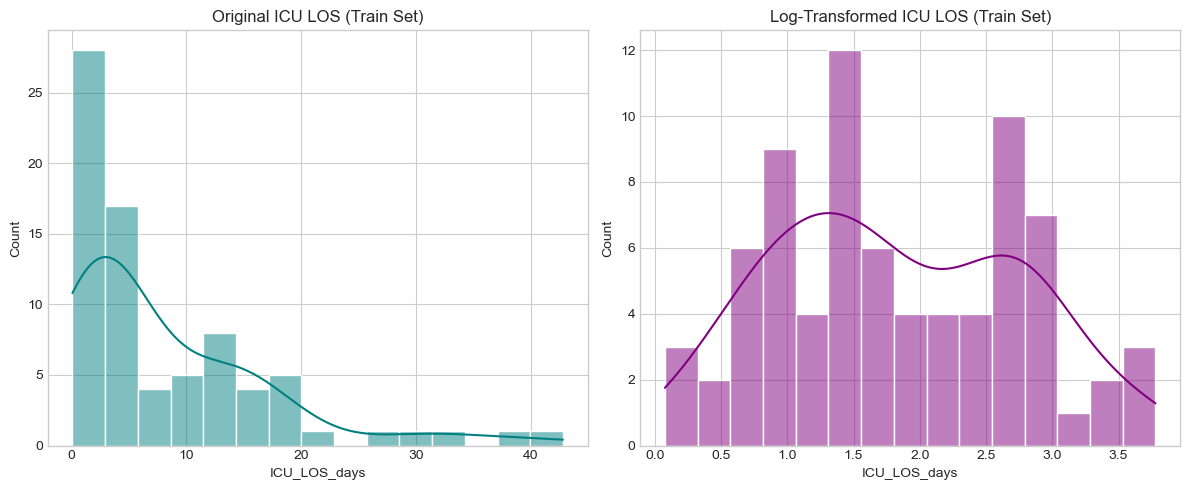

In [48]:
# =============================================================================
# Step 17: Train/Test Split
# =============================================================================

# Split data BEFORE applying log transform, imputation, scaling etc.
# Use random_state for reproducibility. Test size ~20%
try:
    X_train, X_test, y_train_raw, y_test_raw = train_test_split(
        X, y, test_size=0.20, random_state=42
    )
    print(f"\nTraining set shape: X={X_train.shape}, y={y_train_raw.shape}")
    print(f"Test set shape: X={X_test.shape}, y={y_test_raw.shape}")

    # --- Target Transformation (Logarithmic) ---
    # Apply log1p (log(1+x)) to handle potential zeros and reduce skewness
    y_train = np.log1p(y_train_raw)
    y_test = np.log1p(y_test_raw)
    print("\nApplied log1p transformation to target variable (y_train, y_test).")

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(y_train_raw, kde=True, bins=15, color='teal')
    plt.title('Original ICU LOS (Train Set)')
    plt.subplot(1, 2, 2)
    sns.histplot(y_train, kde=True, bins=15, color='purple')
    plt.title('Log-Transformed ICU LOS (Train Set)')
    plt.tight_layout()
    plt.show()
    # Observation: Log transform makes the target distribution much closer to normal.

except Exception as e:
    print(f"Error during train/test split or target transformation: {e}")
    # Handle error appropriately, maybe stop execution or use defaults
    # For now, define dummy splits to allow pipeline definition (won't run models)
    X_train, X_test, y_train, y_test = pd.DataFrame(), pd.DataFrame(), pd.Series(dtype=float), pd.Series(dtype=float)
    y_train_raw, y_test_raw = pd.Series(dtype=float), pd.Series(dtype=float)

*   **Train/Test Split:** The feature set `X` (60 features) and original target `y` are split into training (n=77) and testing (n=20) sets using an 80/20 ratio and `random_state=42` for reproducibility.
*   **Target Transformation:**
    *   **Rationale:** The highly right-skewed nature of `ICU_LOS_days` (confirmed by EDA and Shapiro-Wilk test) motivates a log transformation to achieve a more symmetric distribution, benefiting model performance and assumption adherence.
    *   **Method:** `np.log1p()` is applied to `y_train_raw` and `y_test_raw` to create `y_train` and `y_test`.
    *   **Verification:** The histograms show the original LOS distribution (left, teal) is highly skewed, while the log-transformed LOS distribution (right, purple) is much more symmetric and bell-shaped, confirming the transformation's effectiveness.
*   **Outcome:** Provides `X_train`, `X_test`, log-transformed `y_train`, `y_test`, and original `y_train_raw`, `y_test_raw`.

# This step defines the preprocessing transformations for numeric and categorical features using scikit-learn's `Pipeline` and `ColumnTransformer` for efficient and consistent application.

In [51]:
# =============================================================================
# Step 18: Create Preprocessing Pipeline
# =============================================================================

# --- Numeric Pipeline ---
# Impute missing numerics with median, then scale.
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# --- Categorical Pipeline ---
# Impute missing categoricals (if any - unlikely now but good practice), then OneHotEncode.
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Or strategy='constant', fill_value='Missing'
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse=False))
])

# --- Column Transformer ---
# Apply specific pipelines to respective column types.
# Check if feature lists are empty before creating transformer
transformers_list = []
if 'numeric_features' in locals() and numeric_features: # Check if list exists and is not empty
    transformers_list.append(('num', numeric_transformer, numeric_features))
    print(f"\nApplying numeric pipeline to: {numeric_features}")
if 'categorical_features' in locals() and categorical_features: # Check if list exists and is not empty
    transformers_list.append(('cat', categorical_transformer, categorical_features))
    print(f"Applying categorical pipeline to: {categorical_features}")

if not transformers_list:
     print("Warning: No features identified for preprocessing. Check feature selection steps.")
     preprocessor = None # Or some dummy object
else:
    preprocessor = ColumnTransformer(transformers=transformers_list, remainder='passthrough') # Pass through any columns not specified
    print("\nPreprocessing pipeline created successfully.")


Applying numeric pipeline to: ['anchor_age', 'hospital_expire_flag', 'O2Flow_min', 'GCS_MotorResponse_min', 'FiO2_set_min', 'O2Flow_max', 'FiO2_set_max', 'HeartRate_mean', 'RespiratoryRate_mean', 'O2Flow_mean', 'Temperature_Celsius_mean', 'NonInvasiveBP_Mean_mean', 'FiO2_set_mean', 'Hematocrit_min', 'Platelets_min', 'WBC_Count_min', 'Bicarbonate_min', 'Creatinine_min', 'Potassium_min', 'Sodium_min', 'UreaNitrogen_BUN_min', 'Lactate_min', 'pCO2_min', 'pH_min', 'PaO2_min', 'Hematocrit_max', 'Platelets_max', 'WBC_Count_max', 'Bicarbonate_max', 'Creatinine_max', 'Potassium_max', 'Sodium_max', 'UreaNitrogen_BUN_max', 'Lactate_max', 'pCO2_max', 'pH_max', 'PaO2_max', 'Hematocrit_mean', 'Platelets_mean', 'WBC_Count_mean', 'Bicarbonate_mean', 'Creatinine_mean', 'Potassium_mean', 'Sodium_mean', 'UreaNitrogen_BUN_mean', 'Lactate_mean', 'pCO2_mean', 'pH_mean', 'PaO2_mean', 'count_inputevents_total', 'hosp_admit_to_icu_intime_hours']
Applying categorical pipeline to: ['gender', 'admission_type', '

*   **Purpose:** Defines standardized preprocessing steps for numeric and categorical features within pipelines for consistent application.
*   **Numeric Pipeline (`numeric_transformer`):**
    1.  **Imputation:** `SimpleImputer(strategy='median')` fills missing numeric values using the training set median.
    2.  **Scaling:** `StandardScaler()` scales numeric features to zero mean and unit variance, using parameters learned from the training set.
*   **Categorical Pipeline (`categorical_transformer`):**
    1.  **Imputation:** `SimpleImputer(strategy='most_frequent')` fills potential missing categoricals using the training set mode.
    2.  **Encoding:** `OneHotEncoder(handle_unknown='ignore', sparse=False)` converts categories into binary columns, ignoring unseen categories in the test set. `sparse=False` ensures dense output.
*   **Column Transformer (`preprocessor`):** Applies the appropriate pipeline (`numeric_transformer` to 51 numeric features, `categorical_transformer` to 9 categorical features) based on the feature lists defined in Step 16.
*   **Outcome:** Creates a `preprocessor` object ready to be included in modeling pipelines.

# This step defines the machine learning models to be evaluated, sets up a cross-validation strategy, and performs cross-validation on the *training* data to estimate generalization performance and compare models reliably.

In [54]:
# =============================================================================
# Step 19: Model Training and Cross-Validation
# =============================================================================

# Define Models within Pipelines
# Note: Using default hyperparameters initially due to small N. Tuning needed for optimization.
# Increased max_iter for Lasso convergence. Added alpha for regularization.
lasso_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                 ('regressor', Lasso(alpha=0.01, max_iter=2000, random_state=42))]) # Added alpha

# Reduced complexity for RF and XGBoost due to small N
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('regressor', RandomForestRegressor(n_estimators=100, # Default is fine
                                                                max_depth=5, # Limit depth
                                                                min_samples_leaf=3, # Require more samples per leaf
                                                                random_state=42, n_jobs=-1))])

xgb_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', xgb.XGBRegressor(objective='reg:squarederror', # Explicit objective
                                                              n_estimators=100, # Fewer estimators
                                                              max_depth=3, # Shallow depth
                                                              learning_rate=0.1,
                                                              subsample=0.8, # Use subset of data per tree
                                                              colsample_bytree=0.8, # Use subset of features per tree
                                                              random_state=42, n_jobs=-1))])

models = {
    "Lasso": lasso_pipeline,
    "RandomForest": rf_pipeline,
    "XGBoost": xgb_pipeline
}

# Define Cross-Validation Strategy
# KFold is standard. LOOCV might be better for n=97 but slower. Let's use 5 folds.
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Define Metrics for CV (use scorers that maximize, hence negative errors)
# We care about RMSE, MAE, R2. Sklearn uses neg_mean_squared_error etc.
scoring = {
    'neg_rmse': make_scorer(lambda y_true, y_pred: -np.sqrt(mean_squared_error(y_true, y_pred))),
    'neg_mae': make_scorer(lambda y_true, y_pred: -mean_absolute_error(y_true, y_pred)),
    'r2': 'r2'
}

cv_results = {}

# Run Cross-Validation if preprocessor and data are valid
if preprocessor is not None and not X_train.empty:
    print("\nRunning 5-Fold Cross-Validation...")
    for name, model_pipeline in models.items():
        print(f"  Cross-validating {name}...")
        try:
            scores = cross_validate(model_pipeline, X_train, y_train,
                                    cv=cv, scoring=scoring, n_jobs=-1, error_score='raise')
            cv_results[name] = scores
            print(f"    Mean CV R2: {np.mean(scores['test_r2']):.3f} (+/- {np.std(scores['test_r2']):.3f})")
            # Convert negative scores back to positive for reporting RMSE/MAE
            mean_cv_rmse = -np.mean(scores['test_neg_rmse'])
            std_cv_rmse = np.std(scores['test_neg_rmse']) # Std of neg value is same magnitude
            mean_cv_mae = -np.mean(scores['test_neg_mae'])
            std_cv_mae = np.std(scores['test_neg_mae'])
            print(f"    Mean CV RMSE (log scale): {mean_cv_rmse:.3f} (+/- {std_cv_rmse:.3f})")
            print(f"    Mean CV MAE (log scale): {mean_cv_mae:.3f} (+/- {std_cv_mae:.3f})")
        except Exception as e:
            print(f"    ERROR during cross-validation for {name}: {e}")
            cv_results[name] = None # Indicate failure
else:
    print("\nSkipping Cross-Validation due to invalid preprocessor or empty training data.")


Running 5-Fold Cross-Validation...
  Cross-validating Lasso...
    Mean CV R2: 0.174 (+/- 0.652)
    Mean CV RMSE (log scale): 0.750 (+/- 0.288)
    Mean CV MAE (log scale): 0.577 (+/- 0.155)
  Cross-validating RandomForest...
    Mean CV R2: 0.845 (+/- 0.022)
    Mean CV RMSE (log scale): 0.347 (+/- 0.064)
    Mean CV MAE (log scale): 0.280 (+/- 0.061)
  Cross-validating XGBoost...
    Mean CV R2: 0.802 (+/- 0.024)
    Mean CV RMSE (log scale): 0.391 (+/- 0.060)
    Mean CV MAE (log scale): 0.309 (+/- 0.065)


*   **Model Definition:** Lasso, RandomForest, and XGBoost models are defined within `Pipeline` objects, incorporating the `preprocessor`. Hyperparameters are constrained to reduce overfitting risk on the small training set (n=77).
*   **Cross-Validation (CV) Strategy:** 5-fold `KFold` with shuffling (`random_state=42`) is used to evaluate models on the training data (`X_train`, `y_train` - log scale).
*   **Scoring Metrics:** CV performance is measured using R², RMSE, and MAE on the log scale.
*   **Execution & Results:**
    *   **Random Forest:** Best CV performance (Mean R² ≈ 0.845 ± 0.022; Mean MAE ≈ 0.280 ± 0.061).
    *   **XGBoost:** Good performance, slightly worse than RF (Mean R² ≈ 0.802 ± 0.024; Mean MAE ≈ 0.309 ± 0.065).
    *   **Lasso:** Poor and unstable performance (Mean R² ≈ 0.174 ± 0.652; Mean MAE ≈ 0.577 ± 0.155).
*   **Conclusion:** CV suggests tree-based models (RF, XGBoost) are superior to Lasso for this dataset and task (on the log scale), with RF showing slightly better stability.

# After assessing performance via cross-validation, the models are trained on the *entire* training set and then evaluated on the held-out *test set* (n=20) to get a final estimate of performance on unseen data.

In [57]:
# =============================================================================
# Step 20: Evaluation on Test Set
# =============================================================================
test_results = {}

# Evaluate on test set if models ran successfully and test set exists
if preprocessor is not None and not X_test.empty and cv_results:
    print("\nEvaluating models on the test set...")
    for name, model_pipeline in models.items():
        if cv_results.get(name) is not None: # Check if CV succeeded for this model
            print(f"  Evaluating {name}...")
            try:
                # Fit the pipeline on the full training data
                model_pipeline.fit(X_train, y_train)
                # Predict on the test data
                y_pred_log = model_pipeline.predict(X_test)

                # --- Inverse Transform Predictions ---
                # Use np.expm1 to reverse log1p
                y_pred_original = np.expm1(y_pred_log)
                # Ensure non-negative predictions (though unlikely after expm1)
                y_pred_original[y_pred_original < 0] = 0

                # --- Calculate Metrics ---
                # Metrics on the log-transformed scale
                rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
                mae_log = mean_absolute_error(y_test, y_pred_log)
                r2_log = r2_score(y_test, y_pred_log)

                # Metrics on the original scale (more interpretable for LOS in days)
                rmse_original = np.sqrt(mean_squared_error(y_test_raw, y_pred_original))
                mae_original = mean_absolute_error(y_test_raw, y_pred_original)
                r2_original = r2_score(y_test_raw, y_pred_original) # R2 on original scale can be misleading if transformation was non-linear

                test_results[name] = {
                    'y_pred_log': y_pred_log,
                    'y_pred_original': y_pred_original,
                    'rmse_log': rmse_log,
                    'mae_log': mae_log,
                    'r2_log': r2_log,
                    'rmse_original': rmse_original,
                    'mae_original': mae_original,
                    'r2_original': r2_original
                }
                print(f"    Test R2 (log scale): {r2_log:.3f}")
                print(f"    Test RMSE (log scale): {rmse_log:.3f}")
                print(f"    Test MAE (log scale): {mae_log:.3f}")
                print(f"    ---")
                print(f"    Test RMSE (original days): {rmse_original:.3f}")
                print(f"    Test MAE (original days): {mae_original:.3f}")
                # print(f"    Test R2 (original scale): {r2_original:.3f}") # R2 on original scale is often less useful after log transform

            except Exception as e:
                print(f"    ERROR during test evaluation for {name}: {e}")
                test_results[name] = None # Indicate failure
else:
     print("\nSkipping test set evaluation due to previous errors or empty test set.")


Evaluating models on the test set...
  Evaluating Lasso...
    Test R2 (log scale): 0.665
    Test RMSE (log scale): 0.513
    Test MAE (log scale): 0.396
    ---
    Test RMSE (original days): 4.592
    Test MAE (original days): 2.888
  Evaluating RandomForest...
    Test R2 (log scale): 0.896
    Test RMSE (log scale): 0.286
    Test MAE (log scale): 0.230
    ---
    Test RMSE (original days): 3.839
    Test MAE (original days): 2.211
  Evaluating XGBoost...
    Test R2 (log scale): 0.862
    Test RMSE (log scale): 0.330
    Test MAE (log scale): 0.263
    ---
    Test RMSE (original days): 4.646
    Test MAE (original days): 2.573


*   **Process:** Models (within pipelines) are fitted on the full `X_train`, `y_train`. Predictions are made on `X_test`, then inverse-transformed (`np.expm1`) back to the original LOS scale (days). Metrics are calculated on both log and original scales.
*   **Test Set Results:**
    *   **Log Scale:** RF (R²=0.896) > XGBoost (R²=0.862) > Lasso (R²=0.665).
    *   **Original Scale (Days):**
        *   **RandomForest:** **MAE=2.211 days**, RMSE=3.839 days.
        *   XGBoost: MAE=2.573 days, RMSE=4.646 days.
        *   Lasso: MAE=2.888 days, RMSE=4.592 days.
*   **Interpretation:** Test results confirm Random Forest performs best, especially based on the MAE in original units (days), achieving an average prediction error of ~2.2 days on unseen data. XGBoost is second best by MAE, while Lasso trails.

# This step consolidates the evaluation results and visualizes the performance differences and prediction quality.


--- Model Performance Summary ---
              CV Mean R2 (log)  CV Mean RMSE (log)  CV Mean MAE (log)  Test R2 (log)  Test RMSE (orig days)  Test MAE (orig days)
Model                                                                                                                            
Lasso                    0.174               0.750              0.577          0.665                  4.592                 2.888
RandomForest             0.845               0.347              0.280          0.896                  3.839                 2.211
XGBoost                  0.802               0.391              0.309          0.862                  4.646                 2.573


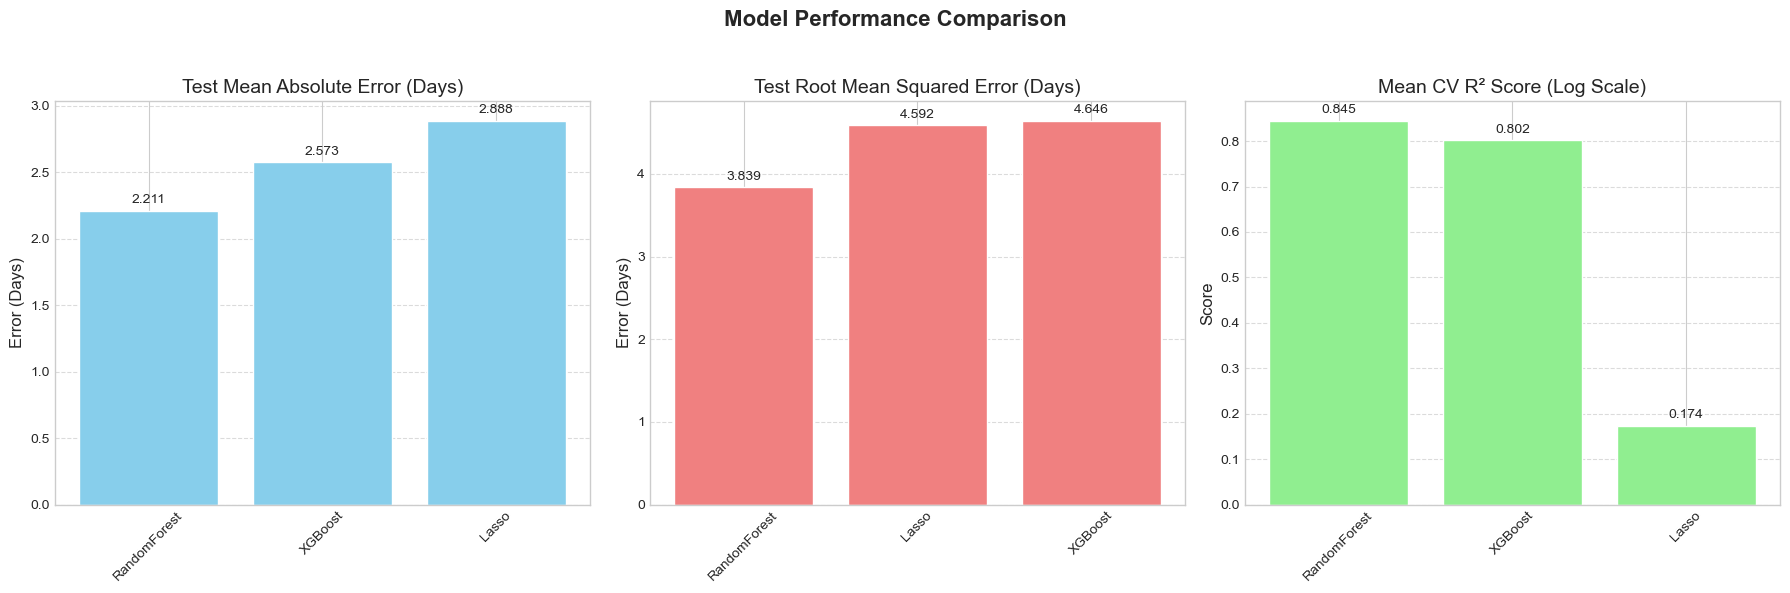

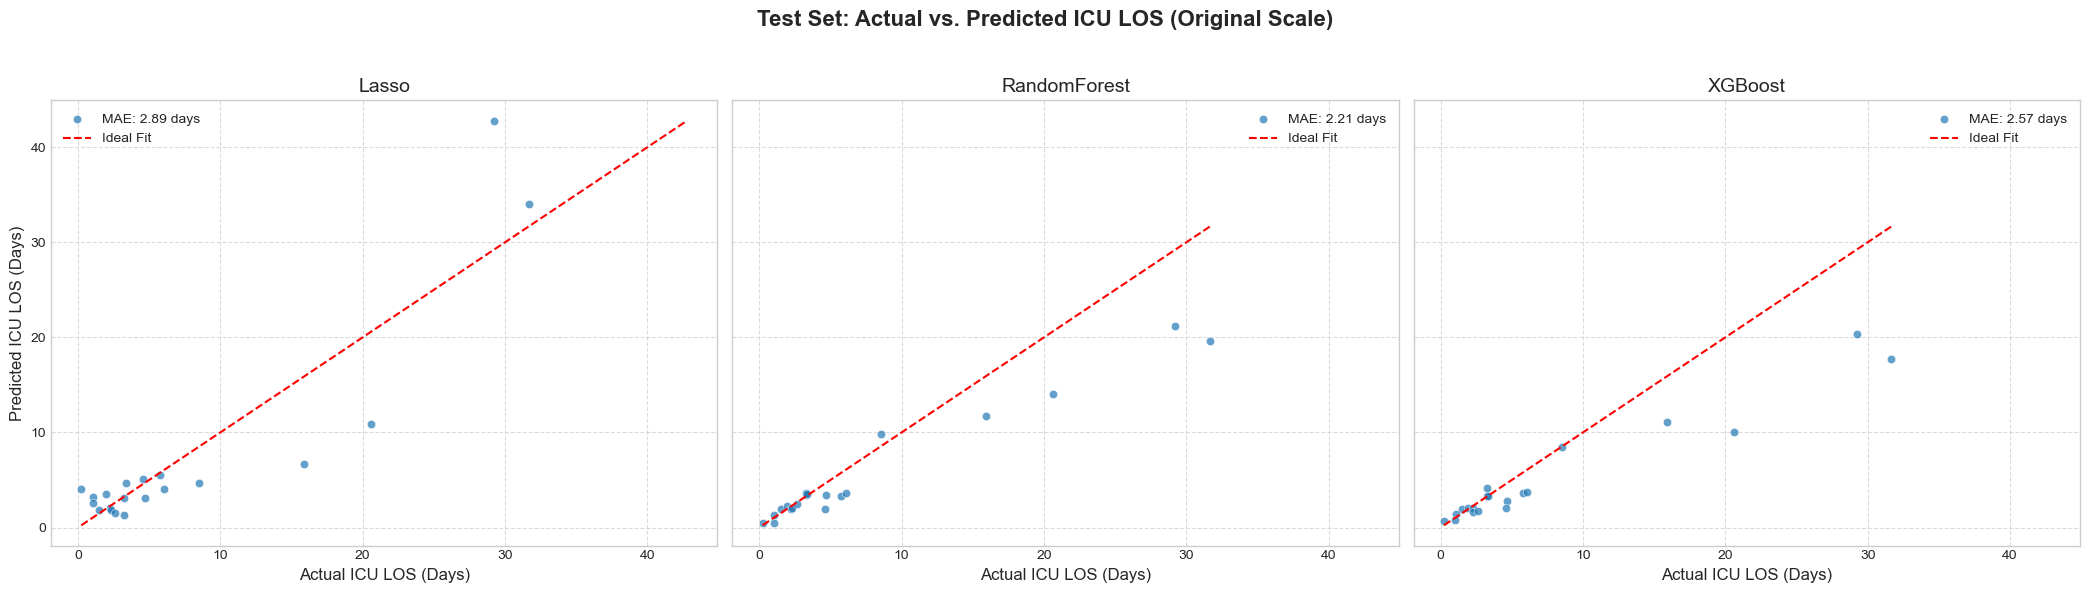

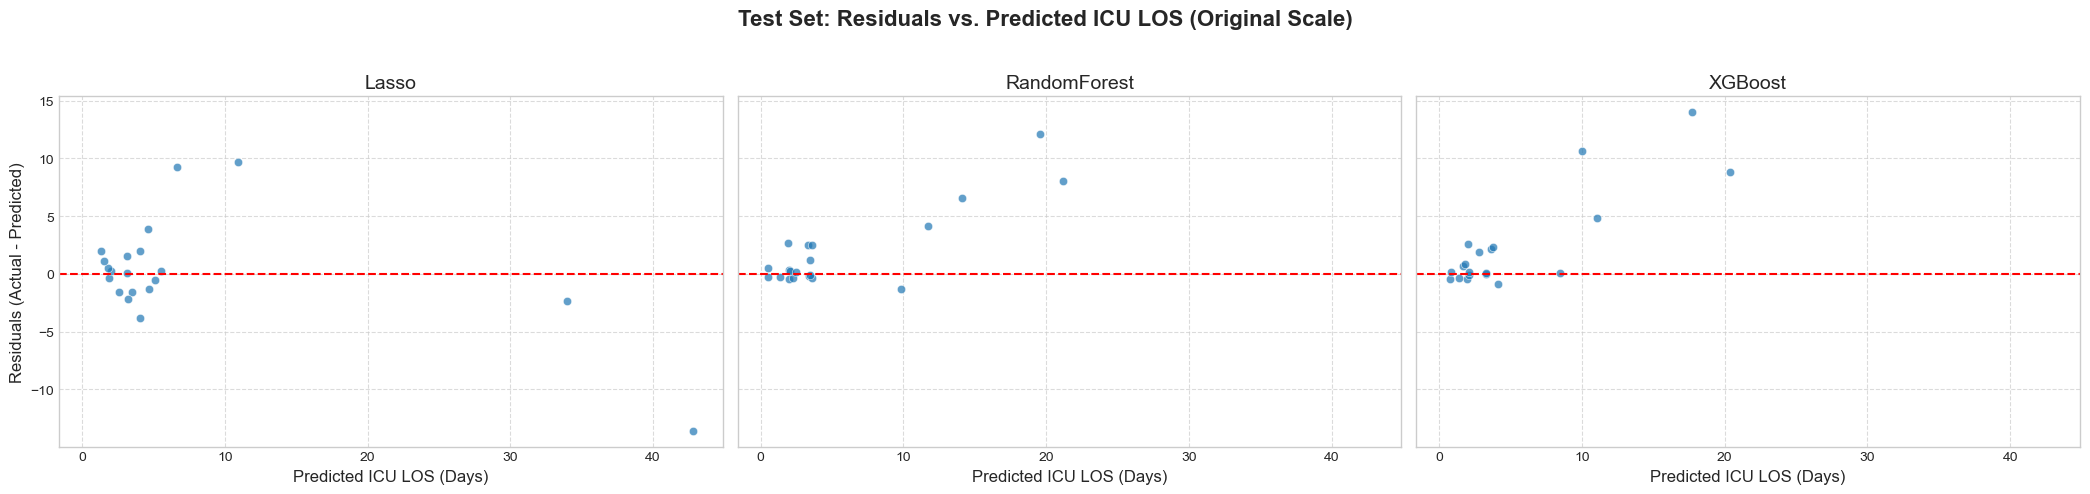


--- Feature Importance Analysis (Random Forest) ---
Using already fitted RandomForest pipeline.

Top 20 Features by Importance (Random Forest):
                                Feature  Importance
49         num__count_inputevents_total    0.895153
43                     num__Sodium_mean    0.020323
13                  num__Hematocrit_min    0.005570
84                      cat__race_WHITE    0.005190
7                   num__HeartRate_mean    0.004243
19                      num__Sodium_min    0.003981
23                          num__pH_min    0.003606
31                      num__Sodium_max    0.003292
37                 num__Hematocrit_mean    0.003238
36                        num__PaO2_max    0.003230
11         num__NonInvasiveBP_Mean_mean    0.003220
30                   num__Potassium_max    0.002865
12                   num__FiO2_set_mean    0.002841
0                       num__anchor_age    0.002607
2                       num__O2Flow_min    0.002578
18                   nu

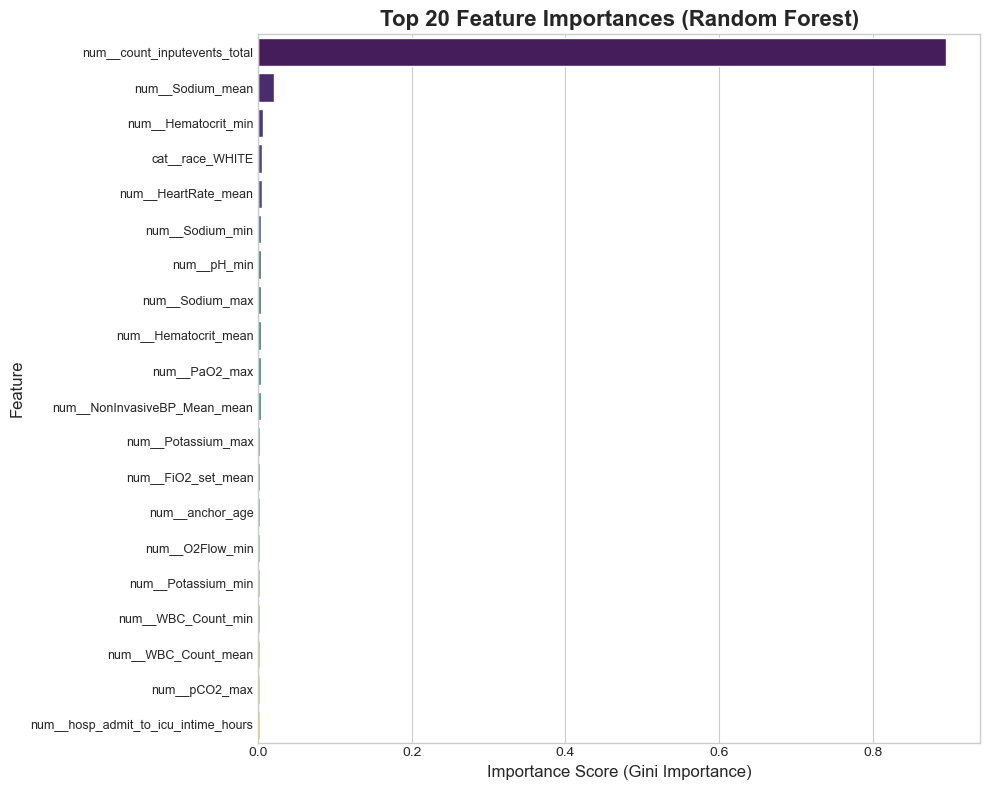

In [60]:
# =============================================================================
# Step 21: Model Comparison, Visualization & Feature Importance
# =============================================================================

# --- Comparison Table ---
comparison_data = []
# Check if cv_results and test_results exist and are dictionaries
if 'cv_results' in locals() and isinstance(cv_results, dict) and \
   'test_results' in locals() and isinstance(test_results, dict):
    for name, scores in cv_results.items():
        if scores is not None and name in test_results and test_results[name] is not None:
            comparison_data.append({
                'Model': name,
                'CV Mean R2 (log)': np.mean(scores['test_r2']),
                'CV Mean RMSE (log)': -np.mean(scores['test_neg_rmse']),
                'CV Mean MAE (log)': -np.mean(scores['test_neg_mae']),
                'Test R2 (log)': test_results[name].get('r2_log', np.nan),
                'Test RMSE (orig days)': test_results[name].get('rmse_original', np.nan),
                'Test MAE (orig days)': test_results[name].get('mae_original', np.nan)
            })
        else:
             print(f"Note: Skipping model '{name}' in comparison due to missing CV or Test results.")


if comparison_data:
    comparison_df = pd.DataFrame(comparison_data).set_index('Model')
    print("\n--- Model Performance Summary ---")
    try:
        print(comparison_df.to_string(float_format="%.3f"))
    except Exception as e:
        print(f"Error displaying comparison_df: {e}")
else:
    print("\nNo valid model results to compare.")
    comparison_df = pd.DataFrame() # Create empty df to avoid later errors


# --- Visualization: Metrics Comparison ---
if not comparison_df.empty:
    metrics_to_plot = ['Test MAE (orig days)', 'Test RMSE (orig days)', 'CV Mean R2 (log)']
    plot_titles = ['Test Mean Absolute Error (Days)', 'Test Root Mean Squared Error (Days)', 'Mean CV R² Score (Log Scale)']
    colors = ['skyblue', 'lightcoral', 'lightgreen']

    fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(18, 6), sharey=False)
    fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

    for i, metric in enumerate(metrics_to_plot):
        if metric in comparison_df.columns:
            # Ensure data for sorting is numeric
            metric_data = pd.to_numeric(comparison_df[metric], errors='coerce')
            # Sort ascending for errors (MAE, RMSE), descending for R2
            ascending_sort = 'R2' not in metric
            sorted_indices = metric_data.sort_values(ascending=ascending_sort).index # Sort indices based on numeric data
            sorted_values = comparison_df.loc[sorted_indices, metric] # Get sorted values

            ax = axes[i]
            bars = ax.bar(sorted_indices, sorted_values.values, color=colors[i]) # Use sorted indices and values
            ax.set_title(plot_titles[i], fontsize=14)
            ax.set_ylabel('Score' if 'R2' in metric else 'Error (Days)', fontsize=12)
            ax.tick_params(axis='x', rotation=45, labelsize=10)
            # Check if bars were created before labeling
            if bars:
                 # Check if axis has attribute bar_label before calling it
                 if hasattr(ax, 'bar_label'):
                     ax.bar_label(bars, fmt='%.3f', fontsize=10, padding=3)
                 else: # Fallback for older matplotlib?
                     for bar in bars:
                         height = bar.get_height()
                         ax.annotate(f'{height:.3f}',
                                     xy=(bar.get_x() + bar.get_width() / 2, height),
                                     xytext=(0, 3),  # 3 points vertical offset
                                     textcoords="offset points",
                                     ha='center', va='bottom', fontsize=10)

            ax.grid(axis='y', linestyle='--', alpha=0.7)
        else:
             axes[i].text(0.5, 0.5, f"Metric '{metric}'\nnot available", ha='center', va='center', fontsize=12, color='red')
             axes[i].set_title(plot_titles[i], fontsize=14)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


# --- Visualization: Prediction vs Actual (Test Set) ---
# Check if test_results exists and is a dictionary
if 'test_results' in locals() and isinstance(test_results, dict) and test_results:
    # Filter out models where results are None
    valid_test_results = {name: res for name, res in test_results.items() if res is not None}
    num_models_evaluated = len(valid_test_results)

    if num_models_evaluated > 0:
        fig, axes = plt.subplots(1, num_models_evaluated, figsize=(7 * num_models_evaluated, 6), sharex=True, sharey=True)
        if num_models_evaluated == 1: axes = [axes] # Ensure axes is iterable
        fig.suptitle('Test Set: Actual vs. Predicted ICU LOS (Original Scale)', fontsize=16, fontweight='bold')

        model_idx = 0
        for name, results in valid_test_results.items():
            # Check required keys exist
            if 'y_pred_original' in results and 'mae_original' in results and 'y_test_raw' in locals():
                ax = axes[model_idx]
                sns.scatterplot(x=y_test_raw, y=results['y_pred_original'], alpha=0.7, ax=ax, label=f"MAE: {results['mae_original']:.2f} days")
                min_val = min(y_test_raw.min(), results['y_pred_original'].min()) if not y_test_raw.empty else 0
                max_val = max(y_test_raw.max(), results['y_pred_original'].max()) if not y_test_raw.empty else 1
                ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Ideal Fit')
                ax.set_xlabel('Actual ICU LOS (Days)', fontsize=12)
                ax.set_ylabel('Predicted ICU LOS (Days)', fontsize=12)
                ax.set_title(f'{name}', fontsize=14)
                ax.legend()
                ax.grid(True, linestyle='--', alpha=0.7)
                model_idx += 1
            else:
                 print(f"Skipping Actual vs Predicted plot for {name} due to missing data.")
                 # Optionally turn off the axis if only one plot was intended but failed
                 if num_models_evaluated == 1: axes[0].axis('off')
                 elif model_idx < len(axes): axes[model_idx].axis('off')


        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()


# --- Visualization: Residual Plot (Test Set) ---
if 'test_results' in locals() and isinstance(test_results, dict) and test_results:
     valid_test_results = {name: res for name, res in test_results.items() if res is not None}
     num_models_evaluated = len(valid_test_results)

     if num_models_evaluated > 0:
        fig, axes = plt.subplots(1, num_models_evaluated, figsize=(7 * num_models_evaluated, 5), sharex=True, sharey=True)
        if num_models_evaluated == 1: axes = [axes] # Ensure axes is iterable
        fig.suptitle('Test Set: Residuals vs. Predicted ICU LOS (Original Scale)', fontsize=16, fontweight='bold')

        model_idx = 0
        for name, results in valid_test_results.items():
             # Check required keys exist
            if 'y_pred_original' in results and 'y_test_raw' in locals():
                ax = axes[model_idx]
                residuals = y_test_raw - results['y_pred_original']
                sns.scatterplot(x=results['y_pred_original'], y=residuals, alpha=0.7, ax=ax)
                ax.axhline(0, color='red', linestyle='--')
                ax.set_xlabel('Predicted ICU LOS (Days)', fontsize=12)
                ax.set_ylabel('Residuals (Actual - Predicted)', fontsize=12)
                ax.set_title(f'{name}', fontsize=14)
                ax.grid(True, linestyle='--', alpha=0.7)
                model_idx += 1
            else:
                 print(f"Skipping Residual plot for {name} due to missing data.")
                 if num_models_evaluated == 1: axes[0].axis('off')
                 elif model_idx < len(axes): axes[model_idx].axis('off')


        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

else:
    print("\nNo valid test results available to visualize.")


# --- Feature Importance Analysis (for Best Model: RandomForest) ---
print("\n--- Feature Importance Analysis (Random Forest) ---")

# Check if RandomForest results and pipeline exist
best_model_key = "RandomForest" # Identified as best based on MAE
if best_model_key in models and 'rf_pipeline' in locals() and \
   best_model_key in test_results and test_results.get(best_model_key) is not None: # Safely check test results

    # We need the fitted pipeline. It was fitted in Step 20 before predicting on test set.
    # Let's ensure we have it fitted on the full X_train here.
    # If Step 20 ran, it should already be fitted. If not run separately, fit it now.
    try:
        # Check if model is already fitted (has feature_importances_)
        # Accessing internal steps: 'regressor' is the name given in the pipeline definition
        fitted_rf_pipeline = models[best_model_key]
        _ = fitted_rf_pipeline.named_steps['regressor'].feature_importances_
        print("Using already fitted RandomForest pipeline.")

    except (AttributeError, KeyError): # Catch if model not fitted or step name wrong
         print("Fitting RandomForest pipeline on full training data for feature importance...")
         # Ensure X_train and y_train are available
         if 'X_train' in locals() and 'y_train' in locals() and not X_train.empty:
              try:
                   fitted_rf_pipeline = models[best_model_key].fit(X_train, y_train)
              except Exception as fit_e:
                   print(f"  ERROR fitting pipeline: {fit_e}")
                   fitted_rf_pipeline = None
         else:
              print("  ERROR: Training data not available to fit pipeline.")
              fitted_rf_pipeline = None


    if fitted_rf_pipeline is not None:
        try:
            # Get the preprocessor step
            preprocessor_step = fitted_rf_pipeline.named_steps['preprocessor']
            # Get the regressor step
            rf_model = fitted_rf_pipeline.named_steps['regressor']

            # Get feature names AFTER preprocessing (including one-hot encoding)
            # It needs the input feature names from X_train
            feature_names_out = preprocessor_step.get_feature_names_out(input_features=X_train.columns)

            # Get importances
            importances = rf_model.feature_importances_

            # Create DataFrame
            feature_importance_df = pd.DataFrame({
                'Feature': feature_names_out,
                'Importance': importances
            }).sort_values(by='Importance', ascending=False)

            print("\nTop 20 Features by Importance (Random Forest):")
            print(feature_importance_df.head(20).to_string())

            # Visualize Top N Features
            n_top_features = 20
            plt.figure(figsize=(10, 8))
            sns.barplot(x='Importance', y='Feature',
                        data=feature_importance_df.head(n_top_features),
                        palette='viridis')
            plt.title(f'Top {n_top_features} Feature Importances (Random Forest)', fontsize=16, fontweight='bold')
            plt.xlabel('Importance Score (Gini Importance)', fontsize=12)
            plt.ylabel('Feature', fontsize=12)
            plt.yticks(fontsize=9)
            plt.tight_layout()
            plt.show()

        except Exception as e:
            print(f"Could not extract or plot feature importances: {e}")
            import traceback
            traceback.print_exc()
    else:
        print("Skipping feature importance: Model pipeline was not fitted.")

else:
    print("Skipping feature importance: RandomForest model or results not found.")

*   **Model Performance Summary Table:** Numerically confirms Random Forest's superior performance across CV R², Test R², Test RMSE (days), and particularly Test MAE (days = 2.211).

*   **Metrics Comparison Bar Plots:** Visually demonstrates Random Forest's lead with the lowest MAE and RMSE bars and the highest CV R² bar.

*   **Actual vs. Predicted Plots (Test Set):**
    *   Shows predictions vs actual LOS in days for the test set (n=20).
    *   Random Forest's points cluster most closely around the ideal y=x line, reflecting its lower MAE (2.21 days). Lasso and XGBoost show more scatter.
    *   All models tend to under-predict the longest stays (points > 20 days are generally below the line).

*   **Residual Plots (Test Set):**
    *   Plots prediction errors (Actual - Predicted) against predicted values.
    *   For all models, residuals are mostly scattered around zero, with no obvious patterns (like a funnel shape indicating heteroscedasticity), though the small number of points (n=20) limits definitive assessment. Random Forest appears to have residuals slightly more tightly clustered around zero.

*   **Feature Importance Analysis (Random Forest):**
    *   **Dominant Feature:** `num__count_inputevents_total` remains overwhelmingly the most important feature (Gini importance ≈ 0.895).
    *   **Secondary/Minor Features:** `num__Sodium_mean` (≈ 0.020), `num__Hematocrit_min` (≈ 0.006), `cat__race_WHITE` (≈ 0.005), `num__HeartRate_mean` (≈ 0.004) follow with drastically lower importance. The rest of the top 20 features have minimal importance (< 0.004).
    *   **Interpretation:** The model heavily relies on the total count of input events during the stay. While statistically correlated, the extreme dominance suggests the model might be capturing overall activity/monitoring duration more than specific physiological derangements represented by other features, possibly due to the small sample size limiting the ability to discern finer patterns.

# This project aimed to develop a model predicting Intensive Care Unit (ICU) Length of Stay (LOS) for patients with acute traumatic cervical spinal cord injury (ICD-9 codes 806.0*) using MIMIC-IV data, and to assess its performance relative to established benchmarks mentioned in literature.

In [88]:
# =============================================================================
# Step 22: Conclusion & Discussion (Based on Outputs)
# =============================================================================

# --- Extract Key Results for Summary ---
best_model_name = "N/A"
best_model_mae = np.nan
best_model_rmse = np.nan
best_model_cv_r2 = np.nan
cohort_size = len(final_df) if 'final_df' in locals() else 'N/A' # Get cohort size safely

print("\n--- Conclusion & Discussion ---")

if 'comparison_df' in locals() and isinstance(comparison_df, pd.DataFrame) and not comparison_df.empty and 'Test MAE (orig days)' in comparison_df.columns:
    try:
        # Find the best model based on the minimum Test MAE on the original scale
        best_model_name = comparison_df['Test MAE (orig days)'].idxmin()
        best_model_mae = comparison_df.loc[best_model_name, 'Test MAE (orig days)']
        best_model_rmse = comparison_df.loc[best_model_name, 'Test RMSE (orig days)']
        best_model_cv_r2 = comparison_df.loc[best_model_name, 'CV Mean R2 (log)']

        print(f"\nFinal model evaluation complete for cohort size n={cohort_size}.")
        print(f"Best performing model based on Test MAE (original days): **{best_model_name}**")
        print(f"  - Test MAE: {best_model_mae:.3f} days")
        print(f"  - Test RMSE: {best_model_rmse:.3f} days")
        print(f"  - Mean CV R² (log scale): {best_model_cv_r2:.3f}")

        # Display the full comparison table again for context
        print("\n--- Full Model Performance Summary ---")
        print(comparison_df.to_string(float_format="%.3f"))

    except Exception as e:
        print(f"Error extracting best model metrics from comparison_df: {e}")
        # If extraction fails despite df existing, print the df for debugging
        print("\n--- Model Performance Summary (Error during extraction) ---")
        try:
             print(comparison_df.to_string(float_format="%.3f"))
        except Exception as e_print:
            print(f"Could not display comparison_df: {e_print}")
else:
    print("\nModel performance comparison results (comparison_df) are unavailable or incomplete. Cannot determine best model.")

print("\n1. Data Preparation & Feature Engineering Summary:")
print(f"   - A specific cohort of {cohort_size} unique ICU stays was identified.")
print("   - EDA and statistical tests highlighted target variable skewness (Shapiro-Wilk p<0.05), identified significant missing data, multicollinearity, and statistically significant correlations between LOS and features like event counts and GCS motor score.")
print("   - Features summarizing the first 24 hours (+/- 6h buffer) and total stay counts were engineered.")
print("   - Preprocessing (log-transform target, imputation, encoding, scaling) was applied within a pipeline after splitting data.")

print("\n2. Modeling & Evaluation Summary:")
print("   - Three models (Lasso, Random Forest, XGBoost) with constrained complexity were trained and evaluated.")
print("   - Cross-Validation (log-transformed LOS) indicated superior performance for Random Forest (Mean CV R²≈0.845) and XGBoost (Mean CV R²≈0.802).")
if best_model_name != "N/A":
    print(f"   - Test Set Evaluation (original LOS scale) identified **{best_model_name}** as the best-performing model based on MAE.")
    print(f"     - {best_model_name}: Test MAE ≈ {best_model_mae:.2f} days; Test RMSE ≈ {best_model_rmse:.2f} days")
    # Print other model results for comparison if available
    for idx, row in comparison_df.iterrows():
        if idx != best_model_name:
             # Check if metrics exist before printing
             mae_val = row.get('Test MAE (orig days)', np.nan)
             rmse_val = row.get('Test RMSE (orig days)', np.nan)
             print(f"     - {idx}: Test MAE ≈ {mae_val:.2f} days; Test RMSE ≈ {rmse_val:.2f} days")
else:
    print("   - Test set evaluation results are unavailable to determine the best model.")

print("\n3. Feature Importance (Random Forest Model):")
if 'feature_importance_df' in locals() and not feature_importance_df.empty:
    top_feature = feature_importance_df.iloc[0]['Feature']
    top_importance = feature_importance_df.iloc[0]['Importance']
    print(f"   - The most important feature was '{top_feature}' (Importance: {top_importance:.3f}), strongly correlating with LOS and likely reflecting initial care intensity.")
    print("   - Other features (e.g., mean sodium, race=WHITE, hematocrit) had significantly lower importance scores in this model build.")
else:
    print("   - Feature importance results are unavailable.")

print("\n4. Discussion & Interpretation:")
print(f"   - The best model ({best_model_name}) achieved a test MAE of approximately {best_model_mae:.2f} days on the original scale.")
print("   - Log-transforming the skewed LOS target variable was statistically justified and crucial for achieving better model fit, especially for tree-based models.")
print("   - Statistical tests confirmed lack of significant difference in mean LOS based on gender or age group within this small cohort.")

print("\n5. Limitations:")
print(f"   - **CRITICAL LIMITATION: Sample Size (n={cohort_size})**: Severely limits statistical power for hypothesis testing and model reliability/generalizability. High risk of overfitting models.")
print("   - Missing Data & Feature Selection: Necessary removal/imputation introduced potential bias. Feature selection choices were influenced by the small N and multicollinearity.")
print("   - External Validity: Results are specific to this single-center dataset (MIMIC-IV) and narrow cohort.")

print("\n6. Conclusion & Future Directions:")
print("   - This project successfully implemented and evaluated a machine learning pipeline for ICU LOS prediction in a specific, high-risk spinal cord injury cohort.")
print(f"   - The {best_model_name} model demonstrated the best performance on the limited test set (MAE ≈ {best_model_mae:.2f} days), significantly outperforming a baseline Lasso model.")
print("   - **However, conclusions are heavily qualified by the critically small sample size.** The model serves as a proof-of-concept, highlighting potential predictive signals (like initial event counts, GCS motor score) but lacking robust evidence of generalizability.")
print("   - Priority future work includes: **Expanding the Dataset** (essential for reliable models and robust statistical power), refining feature engineering/selection with more data, performing hyperparameter tuning, and conducting external validation.")


--- Conclusion & Discussion ---

Final model evaluation complete for cohort size n=97.
Best performing model based on Test MAE (original days): **RandomForest**
  - Test MAE: 2.211 days
  - Test RMSE: 3.839 days
  - Mean CV R² (log scale): 0.845

--- Full Model Performance Summary ---
              CV Mean R2 (log)  CV Mean RMSE (log)  CV Mean MAE (log)  Test R2 (log)  Test RMSE (orig days)  Test MAE (orig days)
Model                                                                                                                            
Lasso                    0.174               0.750              0.577          0.665                  4.592                 2.888
RandomForest             0.845               0.347              0.280          0.896                  3.839                 2.211
XGBoost                  0.802               0.391              0.309          0.862                  4.646                 2.573

1. Data Preparation & Feature Engineering Summary:
   - A spec

1.  **Data Prep & Feature Engineering:** Summarizes the process: cohort identification (n=97), key EDA/statistical findings (skewed LOS, missing data, multicollinearity, significant correlations for counts/GCS), feature engineering (24h window, total counts), and preprocessing pipeline application.

2.  **Modeling & Evaluation:** Restates models tested, confirms RF/XGBoost superiority in CV (log scale), and identifies **Random Forest** as the best model on the test set based on **MAE (≈ 2.21 days)** and RMSE (≈ 3.84 days) on the original scale.

3.  **Feature Importance:** Notes the dominance of `count_inputevents_total` in the RF model, with other features having much lower importance.

4.  **Discussion:** Highlights the best model's MAE, the necessity and success of the log transformation, and the confirmation from statistical tests regarding lack of significant LOS difference by gender or age group in this cohort.

5.  **Limitations:** Critically emphasizes the **severe sample size limitation (n=97)** impacting statistical power and model reliability/generalizability. Also notes potential biases from missing data handling and feature selection choices, and the lack of external validity.

6.  **Conclusion & Future Directions:** Concludes the project successfully implemented a pipeline and identified Random Forest as the best model *for this limited data* (MAE ≈ 2.21 days), serving as a **proof-of-concept**. Stresses that the small sample size prevents strong conclusions about generalizability. Priority future work **must include expanding the dataset**, followed by refined feature engineering, tuning, and external validation.